In [3]:
import math
import torch
import gpytorch
from matplotlib import pyplot as plt
import numpy as np
import h5py
import random
import bacco
import copy
import os
from matplotlib.lines import Line2D
import pandas as pd

from bacco.halo import virial_mass_converter, virial_concentration_converter

import emcee
import corner
import getdist
from getdist import MCSamples, plots

import sys
sys.path.append("/cosmos_storage/home/fgmaion/MTNG-resims/scripts/train")
from GP_models import SMF_Model, fgas_Model

%matplotlib inline
%load_ext autoreload
%autoreload 2

In [4]:
def mean_std_without_zeros(array):
    ndraws, nbins = array.shape
    mean_values = []
    std_values = []

    for i in range(nbins):
        non_zero_values = array[:, i][array[:, i] != 0]
        mean_values.append(np.mean(non_zero_values))
        std_values.append(np.std(non_zero_values))

    return np.array(mean_values), np.array(std_values)

In [5]:
# Simulation error on the SMF
smf_draws = np.load("/cosmos_storage/home/fgmaion/MTNG-resims/results/smf/smf_draws/smf_draws100_nbins10.npy", allow_pickle=True).item()

sim_smf, err_sim_smf = mean_std_without_zeros(smf_draws['ens_smf'])
err_sim_log_smf = err_sim_smf / sim_smf / np.log(10)
sim_mstar, _ = mean_std_without_zeros(smf_draws['mstar'])

def sigma_smf_of_mass(mstar):
    # Linear interpolation; extrapolate by clipping to the endpoint values
    return np.interp(mstar, np.log10(sim_mstar), err_sim_log_smf)

In [6]:
# fgas: linear in log10(m500c)
fgas_draws = np.load("/cosmos_storage/home/fgmaion/MTNG-resims/results/fgas/fgas_draws/fgas_draws100_nbins10.npy", allow_pickle=True).item()
sim_fgas, err_sim_fgas = mean_std_without_zeros(fgas_draws['ens_fgas'])
sim_m500c, _ = mean_std_without_zeros(fgas_draws['m500'])

def sigma_fgas_of_mass(mhalo):
    # Linear in mhalo, clipped at the endpoints to avoid extrapolation surprises
    return np.interp(mhalo, np.log10(sim_m500c), err_sim_fgas)


In [188]:
def get_gp_prediction(theta_original, mstar, gp_model, likelihood,
                      full_cov=False, model_key=None, data_dict=None):
    """
    Evaluate a FixedNoiseGaussianLikelihood GP at test points.

    The `model_key` argument selects the test-noise function:
        'smf'  -> sigma_smf_of_mass(mstar)
        'fgas' -> sigma_fgas_of_mass(mhalo)
        None   -> no test noise (latent variance only)

    If theta_original has 9 entries, the last two are (b_star, b_cv), the
    SMF stellar-mass and amplitude correction. The returned x-grid and mean
    are inverse-corrected accordingly.
    """
    import numpy as np
    import torch

    # --- Split off SMF correction parameters if present ---
    if len(theta_original) == 9:
        b_star, b_cv = theta_original[-2], theta_original[-1]
        theta_core = theta_original[:7]
        has_correction = True
    else:
        theta_core = theta_original
        b_star, b_cv = 0.0, 1.0
        has_correction = False

    # --- Build GP input ---
    theta_std = prepare_theta(theta_core)
    N = len(mstar)
    gp_input = np.hstack([mstar[:, None],
                          np.repeat(theta_std[None, :], N, axis=0)])
    x_star = torch.from_numpy(gp_input).float()

    # --- Build test noise vector (length = N test points) ---
    if model_key == 'smf':
        test_noise = torch.as_tensor(sigma_smf_of_mass(mstar)**2, dtype=torch.float)
    elif model_key == 'fgas':
        test_noise = torch.as_tensor(sigma_fgas_of_mass(mstar)**2, dtype=torch.float)
    else:
        test_noise = None

    # --- Predict ---
    with torch.no_grad(), gpytorch.settings.fast_pred_var():
        if test_noise is not None:
            predictive_dist = likelihood(gp_model(x_star), noise=test_noise)
        else:
            predictive_dist = likelihood(gp_model(x_star))

    mu_pred  = predictive_dist.mean.numpy()
    var_pred = predictive_dist.variance.numpy()

    # --- Inverse SMF correction ---
    mstar_corr  = mstar - b_star
    mu_pred_corr = mu_pred - np.log10(b_cv)

    if full_cov:
        cov = predictive_dist.covariance_matrix.numpy()
        if has_correction:
            return mstar_corr, mu_pred_corr, var_pred, cov
        return mu_pred, var_pred, cov

    if has_correction:
        return mstar_corr, mu_pred_corr, var_pred
    return mu_pred, var_pred

In [8]:
f_b = 0.15733247005503398

In [141]:
def prepare_theta(theta):

    theta_std = np.copy(theta)
    
    theta_std[0]  = (theta_std[0] - np.mean(wind_en_or)) / np.std(wind_en_or)
    theta_std[1]  = (theta_std[1] - np.mean(wind_vel_or)) / np.std(wind_vel_or)
    theta_std[2]  = (theta_std[2] - np.mean(rho_rec_or)) / np.std(rho_rec_or)
    theta_std[3]  = (theta_std[3] - np.mean(sf_ts_or)) / np.std(sf_ts_or)
    theta_std[4]  = (theta_std[4] - np.mean(ef_kin_or)) / np.std(ef_kin_or)
    theta_std[5]  = (theta_std[5] - np.mean(ef_high_or)) / np.std(ef_high_or)
    theta_std[6]  = (theta_std[6] - np.mean(f_re_or)) / np.std(f_re_or)

    return theta_std

def pars(i, mstar):

    arr = np.vstack( ( mstar, np.ones(len(mstar)) * wind_en[i],\
                        np.ones(len(mstar)) * wind_vel[i],\
                        np.ones(len(mstar)) * rho_rec[i],\
                        np.ones(len(mstar)) * sf_ts[i],\
                        np.ones(len(mstar)) * ef_kin[i],\
                        np.ones(len(mstar)) * ef_high[i],\
                        np.ones(len(mstar)) * f_re[i])).T

    return arr
    
def get_samples(reader):
    tau = reader.get_autocorr_time(tol=0)
        
    burnin = int(3 * np.max(tau))
    thin = int(np.min(tau))

    samples = reader.get_chain(discard=burnin, thin=thin, flat=True)
    log_prob = reader.get_log_prob(discard=burnin, thin=thin, flat=True)

    samples[:,3] *= 1000

    return samples, log_prob

def plot_chains(chains, colors, labels, legend_fontsize=40, line_args=None):

    gd_param_names = ['\\bar{e}_w', '\\kappa_w', '\\rho_{rec}',\
        't_{SFR}', '\\epsilon_{f,kin}', '\\epsilon_{f,high}', 'f_{RE}', 'b_star', 'b_cv']

    ranges = {gd_param_names[0]: [0.9, 14.4],
            gd_param_names[1]: [3.7, 14.8],
            gd_param_names[2]: [np.log10(0.005),np.log10(0.5)],
            gd_param_names[3]: [1.135, 4.54],
            gd_param_names[4]: [np.log10(0.001), np.log10(2)],
            gd_param_names[5]: [0.05, 0.2],
            gd_param_names[6]: [10, 40]}

    reader = {}
    mcsam = {}
    samples = {}
    log_prob = {}
    ml_points = {}  # store maximum-likelihood parameter vectors

    for i in range(len(chains)):
        reader[i] = emcee.backends.HDFBackend('/cosmos_storage/home/fgmaion/MTNG-resims/mcmc_chains/{}.h5'.format(chains[i]))

        samples[i], log_prob[i] = get_samples(reader[i])

        # Identify the maximum-likelihood (highest log-prob) sample
        idx_ml = np.argmax(log_prob[i])
        ml_points[i] = samples[i][idx_ml, :7]

        mcsam[i] = MCSamples(
            samples=samples[i][:,:7],
            loglikes=-log_prob[i],
            names=gd_param_names[:7],
            labels=gd_param_names[:7],
            ranges=ranges
            )

    # Triangle plot (sometimes also called a corner plot)
    g = plots.get_subplot_plotter()

    g.settings.axes_fontsize = 20
    g.settings.lab_fontsize = 30
    g.settings.x_label_rotation = 47
    g.settings.legend_fontsize = legend_fontsize

    g.settings.title_limit_fontsize = 22
    g.triangle_plot([mcsam[i] for i in range(len(chains))],
                    legend_labels=labels, contour_colors=colors, filled=True,
                    line_args=line_args)

    truths = np.asarray([wind_en_or[30], wind_vel_or[30], rho_rec_or[30],
                         1000*sf_ts_or[30], ef_kin_or[30], ef_high_or[30], f_re_or[30]])

    for i in range(7):
        for ax in g.subplots[i:, i]:
            ax.axvline(truths[i], color="gray", ls="--", alpha=0.8)

    for i in range(6):
        for ax in g.subplots[i+1, :i+1]:
            ax.axhline(truths[i+1], color="gray", ls="--", alpha=0.8)

    # ----- Add max-likelihood stars on every off-diagonal panel -----
    for chain_idx in range(len(chains)):
        ml = ml_points[chain_idx]
        for row in range(7):
            for col in range(row):  # off-diagonal lower triangle only
                ax = g.subplots[row, col]
                if ax is None:
                    continue
                ax.plot(ml[col], ml[row],
                        marker='*',
                        markersize=22,
                        markerfacecolor=colors[chain_idx],
                        markeredgecolor='black',
                        markeredgewidth=1.5,
                        linestyle='None',
                        zorder=10)

    # ----- Tick & spine styling: thicker borders, inward ticks on all four sides -----
    for ax_row in g.subplots:
        for ax in ax_row:
            if ax is None:
                continue
            # Thicker spines on all four sides
            for spine in ax.spines.values():
                spine.set_linewidth(2.0)
                spine.set_visible(True)
            # Ticks pointing inward, on all four sides, thicker and longer
            ax.tick_params(which='major', direction='in',
                           top=True, right=True, bottom=True, left=True,
                           length=7, width=1.8)
            ax.tick_params(which='minor', direction='in',
                           top=True, right=True, bottom=True, left=True,
                           length=4, width=1.2)
            ax.minorticks_on()

def compute_chi2_full(residual, cov, obs_err=None, jitter=1e-8):
    """
    Full chi-squared using the covariance matrix:
        chi2 = residual^T (Sigma + diag(obs_err^2))^-1 residual
    Returns (chi2, dof) where dof = len(residual).
    """
    n = len(residual)
    Sigma = cov.copy()
    if obs_err is not None:
        Sigma = Sigma + np.diag(obs_err**2)
    # Symmetrize and add jitter for stability
    Sigma = 0.5 * (Sigma + Sigma.T) + jitter * np.eye(n)
    try:
        L = np.linalg.cholesky(Sigma)
        alpha = np.linalg.solve(L, residual)
        chi2 = float(alpha @ alpha)
    except np.linalg.LinAlgError:
        chi2 = np.nan
    return chi2, n

def plot_best_fits(readers, models, likelihood, colors, data_dict, name, bf_smf=None, bf_fgas=None):
    fontsize = 16
    OMEGA_B_OVER_OMEGA_M = 0.15733247005503398
    SMHM_NORM = 6.355967078189301

    fig, ax = plt.subplots(2, 3, figsize=(18, 12), dpi=100)
    ax_smf, ax_mbh_mstar, ax_smhm = ax[0, 0], ax[0, 1], ax[0, 2]
    ax_fgas, ax_gprof, ax_cprof   = ax[1, 0], ax[1, 1], ax[1, 2]

    # ---------- helpers ----------
    def gp_band(ax_, x, mu, var, color, alpha_fill, lw=3, alpha_line=1.0, ls='-'):
        sd = np.sqrt(var)
        ax_.fill_between(x, mu - sd, mu + sd, color=color, alpha=alpha_fill, edgecolor=None)
        ax_.plot(x, mu, color=color, lw=lw, alpha=alpha_line, ls=ls)

    def plot_obs_vs_model(ax_, x, model_key, pars_fid, pars_bf, color):
        """For 7-parameter calls returning (mu, var)."""
        mu_f, var_f = get_gp_prediction(pars_fid, x, models[model_key], likelihood[model_key], model_key=model_key)
        gp_band(ax_, x, mu_f, var_f, 'gray', 0.1, alpha_line=0.5)
        mu_b, var_b = get_gp_prediction(pars_bf, x, models[model_key], likelihood[model_key], model_key=model_key)
        gp_band(ax_, x, mu_b, var_b, color, 0.2)

    def plot_smf(ax_, x, pars_fid, pars_bf, color):
        """SMF takes 9 params and returns (x_corr, mu_corr, var)."""
        x_f, mu_f, var_f = get_gp_prediction(pars_fid, x, models['smf'], likelihood['smf'], model_key='smf')
        gp_band(ax_, x_f, mu_f, var_f, 'gray', 0.1, alpha_line=0.5)
        x_b, mu_b, var_b = get_gp_prediction(pars_bf, x, models['smf'], likelihood['smf'], model_key='smf')
        gp_band(ax_, x_b, mu_b, var_b, color, 0.2)

    def plot_log_ratio_line(ax_, x, num_key, den_key, pars, color, lw=3,
                                alpha_line=1.0, ls='-'):
        mu_n, _ = get_gp_prediction(pars, x, models[num_key], likelihood[num_key])
        mu_d, _ = get_gp_prediction(pars, x, models[den_key], likelihood[den_key])
        ax_.plot(x, mu_n - mu_d, color=color, lw=lw, alpha=alpha_line, ls=ls)

    def plot_profile_lines(ax_, dm_key, gas_key, stars_key, pars_fid, pars_bf, color):
        r_prof = np.linspace(-2, np.log10(3), 20)
        plot_log_ratio_line(ax_, r_prof, gas_key,   dm_key, pars_fid, 'gray', alpha_line=0.5)
        plot_log_ratio_line(ax_, r_prof, stars_key, dm_key, pars_fid, 'gray', alpha_line=0.5, ls='--')
        plot_log_ratio_line(ax_, r_prof, gas_key,   dm_key, pars_bf,  color)
        plot_log_ratio_line(ax_, r_prof, stars_key, dm_key, pars_bf,  color, ls='--')

    # ---------- axis setup ----------
    ax_smf.set_xlim(9.2, 12.5)
    ax_smf.set_xlabel(r'$\log_{10}(M_*(r<30$kpc$)/M_{\odot})$', fontsize=fontsize)
    ax_smf.set_ylabel(r'$\log_{10}(\Phi/[$Mpc$^{-3}$dex$^{-1}])$', fontsize=fontsize)
    ax_smf.set_title('GSMF', fontsize=fontsize)
    if bf_smf is not None:
        ax_smf.plot(np.log10(bf_smf['mstar'][0]), np.log10(bf_smf['smf'][0]), color='k', lw=3, ls='--', label='Joint Best-Fit Run')


    ax_fgas.set_ylim(0.0, 0.17)
    ax_fgas.set_xlabel(r'$\log_{10}(M_{500,\mathrm{c}}/M_{\odot})$', fontsize=fontsize)
    ax_fgas.set_ylabel(r'$f_{\mathrm{gas}}(r<R_{500,\mathrm{c}})$', fontsize=fontsize)
    ax_fgas.errorbar(data_dict['mhalo'], data_dict['fgas_obs'], yerr=data_dict['fgas_err'],
                     fmt='ko', markersize=5, fillstyle='none', capsize=3,
                     label=data_dict['fgas_label'])
    ax_fgas.legend(fontsize=fontsize, loc='upper left')
    ax_fgas.set_title('Gas Fraction', fontsize=fontsize)
    if bf_fgas is not None:
        ax_fgas.plot(np.log10(bf_fgas['m500c'][0]), bf_fgas['f_gas'][0], color='k', lw=3, ls='--')

    ax_mbh_mstar.set_xlabel(r'$\log_{10}(M_*/M_{\odot})$', fontsize=fontsize)
    ax_mbh_mstar.set_ylabel(r'$\log_{10}(M_{\mathrm{BH}}/M_{\odot})$', fontsize=fontsize)
    ax_mbh_mstar.set_title(r'$M_{\mathrm{BH}}$–$M_*$ Relation', fontsize=fontsize)
    ax_mbh_mstar.legend(handles=[
        Line2D([0], [0], color='gray',    lw=3, label='Fiducial'),
        Line2D([0], [0], color=colors[0], lw=3, label='GSMF Fit'),
        Line2D([0], [0], color=colors[1], lw=3, label=r'$f_{\mathrm{gas}}$ Fit'),
        Line2D([0], [0], color=colors[2], lw=3, label='Joint Fit'),
    ], fontsize=14, loc='upper left', ncol=1)

    ax_smhm.set_xlabel(r'$\log_{10}(M_{200,c}/M_{\odot})$', fontsize=fontsize)
    ax_smhm.set_ylabel(r'$M_*/f_b M_{200,c}$', fontsize=fontsize)
    ax_smhm.set_ylim(0, 0.25)
    ax_smhm.set_title('SMHM', fontsize=fontsize)

    for ax_ in (ax_gprof, ax_cprof):
        ax_.set_xlabel(r'$\log_{10}(r/R_{500})$', fontsize=fontsize)
        ax_.set_ylabel(r'$\log_{10}(\rho_{\mathrm{gas,stars}}/\rho_{DM})$', fontsize=fontsize)
        ax_.axhline(np.log10(OMEGA_B_OVER_OMEGA_M), color='k', ls=':', lw=3)
    ax_gprof.set_title(r'Group Profiles $(M_{200,c}\in[10^{13},10^{14}]M_\odot)$', fontsize=fontsize)
    ax_cprof.set_title(r'Cluster Profiles ($M_{200,c}>10^{14.5}M_\odot)$', fontsize=fontsize)

    ax_cprof.legend(handles=[
        Line2D([0], [0], color='gray', lw=3,            label='Gas'),
        Line2D([0], [0], color='gray', lw=3, ls='--',   label='Stars'),
        Line2D([0], [0], color='k',    lw=3, ls=':',    label=r'$f_b=\Omega_b/\Omega_m$'),
    ], fontsize=fontsize, loc='upper right')

    # ---------- per-chain plotting ----------
    mstar         = data_dict['mstar']
    mhalo         = data_dict['mhalo']
    x_mbh_mstar   = np.linspace(9, 12.5, 20)
    m200c         = np.linspace(11, 14.5, 20)

    chi2_labels = []
    chi2_labels_fgas = []
    for i, reader in enumerate(readers):
        bf = get_bestfit(reader)
        color = colors[i]

        if i == 0:
            ax_smf.errorbar(mstar, data_dict['smf_obs'], yerr=data_dict['smf_err'],
                            color='k', marker='o', markersize=5, fillstyle='none',
                            capsize=5, label='GSMF', elinewidth=2, ls='')
            ax_smf.legend(fontsize=fontsize, loc='lower left')

            ax_mbh_mstar.errorbar(data_dict['mstar_mbh'], data_dict['mbh'], xerr=data_dict['mstar_mbh_err'],
                    yerr=data_dict['mbh_err'], ecolor='k',
                    capsize=5, elinewidth=1, marker='o', alpha=1, ms=5, ls='',
                    markerfacecolor='white', markeredgecolor='k', markeredgewidth=1, zorder=1,
                    label='Graham & Sahu (2023)')

        # SMF: 9-parameter call returns (x_corr, mu_corr, var)
        plot_smf(ax_smf, mstar, fid_pars, bf, color)

        # Chi-squared at max-likelihood point for SMF
        mu_b, _, cov_b = get_gp_prediction(bf[:7], mstar, models['smf'],
                                           likelihood['smf'],
                                           full_cov=True, model_key='smf')
        residual = data_dict['smf_obs'] - mu_b
        chi2, dof = compute_chi2_full(residual, cov_b, obs_err=data_dict['smf_err'])
        chi2_labels.append((color, rf'$\chi^2/N = {chi2:.1f}/{dof}$'))

        # 7-parameter calls
        plot_obs_vs_model(ax_fgas, mhalo, 'fgas', fid_pars[:7], bf[:7], color)

        mu_b_fgas, _, cov_b_fgas = get_gp_prediction(bf[:7], mhalo, models['fgas'],
                                                     likelihood['fgas'],
                                                     full_cov=True, model_key='fgas')
        residual_fgas = data_dict['fgas_obs'] - mu_b_fgas
        chi2_fgas, dof_fgas = compute_chi2_full(residual_fgas, cov_b_fgas,
                                                obs_err=data_dict['fgas_err'])
        chi2_labels_fgas.append((color, rf'$\chi^2/N = {chi2_fgas:.1f}/{dof_fgas}$'))
        
        # mbh_mstar: lines only
        mu_f, _ = get_gp_prediction(fid_pars[:7], x_mbh_mstar, models['mbh_mstar'],
                                    likelihood['mbh_mstar'], model_key='mbh_mstar')
        ax_mbh_mstar.plot(x_mbh_mstar, mu_f, color='gray', lw=3, alpha=0.5)
        mu_b, _ = get_gp_prediction(bf[:7], x_mbh_mstar, models['mbh_mstar'],
                                    likelihood['mbh_mstar'], model_key='mbh_mstar')
        ax_mbh_mstar.plot(x_mbh_mstar, mu_b, color, lw=3)

        # SMHM: lines only
        mu_f, _ = get_gp_prediction(fid_pars[:7], m200c, models['smhm'], likelihood['smhm'])
        ax_smhm.plot(m200c, 10**mu_f * SMHM_NORM, color='gray', lw=3, alpha=0.5)
        mu_b, _ = get_gp_prediction(bf[:7], m200c, models['smhm'], likelihood['smhm'])
        ax_smhm.plot(m200c, 10**mu_b * SMHM_NORM, color, lw=3)

        # Profile panels: lines only
        plot_profile_lines(ax_gprof, 'gprof_dm', 'gprof_gas', 'gprof_stars',
                           fid_pars[:7], bf[:7], color)
        plot_profile_lines(ax_cprof, 'cprof_dm', 'cprof_gas', 'cprof_stars',
                           fid_pars[:7], bf[:7], color)

    # # Annotate chi-squared values on the SMF panel
    # for j, (col, txt) in enumerate(chi2_labels):
    #     ax_smf.text(0.5, 0.47 - j * 0.06, txt,
    #                 transform=ax_smf.transAxes,
    #                 color=col, fontsize=fontsize - 2,
    #                 ha='right', va='top')

    # # Annotate chi-squared values on the fgas panel
    # for j, (col, txt) in enumerate(chi2_labels_fgas):
    #     ax_fgas.text(0.5, 0.8 - j * 0.06, txt,
    #                  transform=ax_fgas.transAxes,
    #                  color=col, fontsize=fontsize - 2,
    #                  ha='right', va='top')

    # ---------- styling ----------
    for ax_ in (ax_smf, ax_fgas, ax_mbh_mstar, ax_gprof, ax_smhm, ax_cprof):
        for spine in ax_.spines.values():
            spine.set_linewidth(2.5)
        ax_.tick_params(axis='both', which='major', width=2.5, length=8, labelsize=12, direction='in', top=True, right=True)
        ax_.tick_params(axis='both', which='minor', width=1.5, length=4, direction='in', top=True, right=True)
        ax_.minorticks_on()

    plt.subplots_adjust(hspace=0.25)
    plt.savefig("/cosmos_storage/home/fgmaion/MTNG-resims/Notebooks/plots/" + name, bbox_inches='tight')
    plt.show()
    
def get_bestfit(reader):
    
    samples, log_prob = get_samples(reader)

    bestfit_idx = np.argmax(log_prob)
    bestfit_params = samples[bestfit_idx,:]

    bestfit_params[3] /= 1000

    return bestfit_params

def get_some_samples(reader):

    samples, log_prob = get_samples(reader)

    # Select 100 random samples from the chain
    n_samples_to_plot = 100
    random_indices = np.random.choice(len(samples), size=n_samples_to_plot, replace=False)
    selected_samples = samples[random_indices,:]

    # Convert sf_ts back to physical units for plotting
    selected_samples[:,3] /= 1000

    return selected_samples

In [10]:
bacco.configuration.config['growth']['method']='reps'

plt.rcParams["font.family"] = "serif"
plt.rcParams["mathtext.fontset"] = "dejavuserif"

print("OMP_NUM_THREADS =", os.environ.get("OMP_NUM_THREADS"))
print("MKL_NUM_THREADS =", os.environ.get("MKL_NUM_THREADS"))

OMP_NUM_THREADS = 12
MKL_NUM_THREADS = None


### Get Parameters

In [11]:
wind_en_or      = []
wind_vel_or     = []
rho_rec_or      = []
sf_ts_or        = []
ef_kin_or       = []
ef_high_or      = []
f_re_or         = []

for i in range(31):
    if i<30:
        filename = "/cosmos_storage/simulations/TNG_Family/MN5_resims/param_LH/param_MTNG-hydro_{:d}.txt".format(i)
    else:
        filename = "/cosmos_storage/simulations/TNG_Family/MN5_resims/param_LH/param_MTNG-hydro.txt"

    with open(filename, 'r') as f:
        for line in f.readlines():
            if len(line.split())!=0:
                if line.split()[0] == 'WindEnergyIn1e51erg':
                    wind_en_or.append(float(line.split()[1]))
                if line.split()[0] == 'VariableWindVelFactor':
                    wind_vel_or.append(float(line.split()[1]))
                if line.split()[0] == 'WindFreeTravelDensFac':
                    rho_rec_or.append(float(line.split()[1]))
                if line.split()[0] == 'MaxSfrTimescale':
                    sf_ts_or.append(float(line.split()[1]))
                if line.split()[0] == 'RadioFeedbackFactor':
                    ef_kin_or.append(float(line.split()[1]))
                if line.split()[0] == 'BlackHoleFeedbackFactor':
                    ef_high_or.append(float(line.split()[1]))
                if line.split()[0] == 'RadioFeedbackReiorientationFactor':
                    f_re_or.append(float(line.split()[1]))
        
rho_rec_or = np.log10(rho_rec_or)
ef_kin_or  = np.log10(ef_kin_or)

wind_en   = (np.asarray(wind_en_or) - np.mean(wind_en_or)) / np.std(wind_en_or)
wind_vel  = (np.asarray(wind_vel_or) - np.mean(wind_vel_or)) / np.std(wind_vel_or)
rho_rec   = (np.asarray(rho_rec_or) - np.mean(rho_rec_or)) / np.std(rho_rec_or)
sf_ts     = (np.asarray(sf_ts_or) - np.mean(sf_ts_or)) / np.std(sf_ts_or)
ef_kin    = (np.asarray(ef_kin_or) - np.mean(ef_kin_or)) / np.std(ef_kin_or)
ef_high   = (np.asarray(ef_high_or) - np.mean(ef_high_or)) / np.std(ef_high_or)
f_re      = (np.asarray(f_re_or) - np.mean(f_re_or)) / np.std(f_re_or)

In [12]:
# Fiducial values (from the last file, i=30)
fiducial_wind_en   = wind_en_or[-1]
fiducial_wind_vel  = wind_vel_or[-1]
fiducial_rho_rec   = rho_rec_or[-1]
fiducial_sf_ts     = sf_ts_or[-1]
fiducial_ef_kin    = ef_kin_or[-1]
fiducial_ef_high   = ef_high_or[-1]
fiducial_f_re      = f_re_or[-1]

fid_pars = np.array([
    fiducial_wind_en,
    fiducial_wind_vel,
    fiducial_rho_rec,
    fiducial_sf_ts,
    fiducial_ef_kin,
    fiducial_ef_high,
    fiducial_f_re,
    0,
    1
])

In [13]:
name_list = ['LH_{:d}'.format(i) for i in range(30)] + ['fiducial']

### Load SMF GP Model

In [34]:
model_smf = torch.load("/cosmos_storage/home/fgmaion/MTNG-resims/gp_train_results/full_model_smf.pth")
likelihood_smf = torch.load("/cosmos_storage/home/fgmaion/MTNG-resims/gp_train_results/full_likelihood_smf.pth")

model_smf.eval()
likelihood_smf.eval()

/tmp/ipykernel_315282/242107401.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_smf = torch.load("/cosmos_storage/home/fgmaion/MTNG-resims/gp_train_results/full_mo

FixedNoiseGaussianLikelihood(
  (noise_covar): FixedGaussianNoise()
  (second_noise_covar): HomoskedasticNoise(
    (raw_noise_constraint): GreaterThan(1.000E-04)
  )
)

### Load $f_{gas}$ model

In [20]:
model_fgas = torch.load("/cosmos_storage/home/fgmaion/MTNG-resims/gp_train_results/full_model_fgas.pth")
likelihood_fgas = torch.load("/cosmos_storage/home/fgmaion/MTNG-resims/gp_train_results/full_likelihood_fgas.pth")

train_x_fgas = model_fgas.train_inputs[0].cpu().numpy()   # shape (n_train_fgas, 8)
train_mass_fgas = train_x_fgas[:, 0]

train_noise_fgas = torch.as_tensor(sigma_fgas_of_mass(train_mass_fgas)**2, dtype=torch.float)

likelihood_fgas = gpytorch.likelihoods.FixedNoiseGaussianLikelihood(
    noise=train_noise_fgas, learn_additional_noise=False,
)
model_fgas.likelihood = likelihood_fgas  # attach

# Get into evaluation (predictive posterior) mode
model_fgas.eval()
likelihood_fgas.eval()

/tmp/ipykernel_315282/3656355719.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_fgas = torch.load("/cosmos_storage/home/fgmaion/MTNG-resims/gp_train_results/full_

FixedNoiseGaussianLikelihood(
  (noise_covar): FixedGaussianNoise()
)

### Load $\phi_{BH}$ model

In [21]:
model_bhmf = torch.load("/cosmos_storage/home/fgmaion/MTNG-resims/gp_train_results/full_model_bhmf.pth")
likelihood_bhmf = torch.load("/cosmos_storage/home/fgmaion/MTNG-resims/gp_train_results/full_likelihood_bhmf.pth")

model_bhmf.eval()
likelihood_bhmf.eval()

/tmp/ipykernel_315282/2204472259.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_bhmf = torch.load("/cosmos_storage/home/fgmaion/MTNG-resims/gp_train_results/full_

GaussianLikelihood(
  (noise_covar): HomoskedasticNoise(
    (raw_noise_constraint): GreaterThan(1.000E-02)
  )
)

### Load $M_{BH}-M_*$ relation Model

In [159]:
model_mbh_mstar = torch.load("/cosmos_storage/home/fgmaion/MTNG-resims/gp_train_results/full_model_mbh_mstar.pth")
likelihood_mbh_mstar = torch.load("/cosmos_storage/home/fgmaion/MTNG-resims/gp_train_results/full_likelihood_mbh_mstar.pth")

model_mbh_mstar.eval()
likelihood_mbh_mstar.eval()

/tmp/ipykernel_315282/1222056788.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_mbh_mstar = torch.load("/cosmos_storage/home/fgmaion/MTNG-resims/gp_train_results/

GaussianLikelihood(
  (noise_covar): HomoskedasticNoise(
    (raw_noise_constraint): GreaterThan(1.000E-02)
  )
)

### Load Size-Mass Relation Model

In [160]:
model_rhalf = torch.load("/cosmos_storage/home/fgmaion/MTNG-resims/gp_train_results/full_model_size_mass.pth")
likelihood_rhalf = torch.load("/cosmos_storage/home/fgmaion/MTNG-resims/gp_train_results/full_likelihood_size_mass.pth")

model_rhalf.eval()
likelihood_rhalf.eval()

/tmp/ipykernel_315282/4125721911.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_rhalf = torch.load("/cosmos_storage/home/fgmaion/MTNG-resims/gp_train_results/full

GaussianLikelihood(
  (noise_covar): HomoskedasticNoise(
    (raw_noise_constraint): GreaterThan(1.000E-02)
  )
)

### Load SMHM Relation Model

In [161]:
model_smhm = torch.load("/cosmos_storage/home/fgmaion/MTNG-resims/gp_train_results/full_model_smhm.pth")
likelihood_smhm = torch.load("/cosmos_storage/home/fgmaion/MTNG-resims/gp_train_results/full_likelihood_smhm.pth")

model_smhm.eval()
likelihood_smhm.eval()

/tmp/ipykernel_315282/2124859544.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_smhm = torch.load("/cosmos_storage/home/fgmaion/MTNG-resims/gp_train_results/full_

GaussianLikelihood(
  (noise_covar): HomoskedasticNoise(
    (raw_noise_constraint): GreaterThan(1.000E-02)
  )
)

### Load sSFR Model

In [162]:
model_sSFR = torch.load("/cosmos_storage/home/fgmaion/MTNG-resims/gp_train_results/full_model_sSFR.pth")
likelihood_sSFR = torch.load("/cosmos_storage/home/fgmaion/MTNG-resims/gp_train_results/full_likelihood_sSFR.pth")

model_sSFR.eval()
likelihood_sSFR.eval()

/tmp/ipykernel_315282/2277568012.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_sSFR = torch.load("/cosmos_storage/home/fgmaion/MTNG-resims/gp_train_results/full_

GaussianLikelihood(
  (noise_covar): HomoskedasticNoise(
    (raw_noise_constraint): GreaterThan(1.000E-02)
  )
)

### Load Profile Model

In [163]:
# dm 
model_gprof_dm = torch.load("/cosmos_storage/home/fgmaion/MTNG-resims/gp_train_results/full_model_rho_groups_dm.pth")
likelihood_gprof_dm = torch.load("/cosmos_storage/home/fgmaion/MTNG-resims/gp_train_results/full_likelihood_rho_groups_dm.pth")

model_gprof_dm.eval()
likelihood_gprof_dm.eval()

# gas
model_gprof_gas = torch.load("/cosmos_storage/home/fgmaion/MTNG-resims/gp_train_results/full_model_rho_groups_gas.pth")
likelihood_gprof_gas = torch.load("/cosmos_storage/home/fgmaion/MTNG-resims/gp_train_results/full_likelihood_rho_groups_gas.pth")

model_gprof_gas.eval()
likelihood_gprof_gas.eval()

# stars
model_gprof_stars = torch.load("/cosmos_storage/home/fgmaion/MTNG-resims/gp_train_results/full_model_rho_groups_stars.pth")
likelihood_gprof_stars = torch.load("/cosmos_storage/home/fgmaion/MTNG-resims/gp_train_results/full_likelihood_rho_groups_stars.pth")

model_gprof_stars.eval()
likelihood_gprof_stars.eval()

/tmp/ipykernel_315282/597863454.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_gprof_dm = torch.load("/cosmos_storage/home/fgmaion/MTNG-resims/gp_train_results/fu

GaussianLikelihood(
  (noise_covar): HomoskedasticNoise(
    (raw_noise_constraint): GreaterThan(1.000E-02)
  )
)

In [164]:
# dm
model_cprof_dm = torch.load("/cosmos_storage/home/fgmaion/MTNG-resims/gp_train_results/full_model_rho_clusters_dm.pth")
likelihood_cprof_dm = torch.load("/cosmos_storage/home/fgmaion/MTNG-resims/gp_train_results/full_likelihood_rho_clusters_dm.pth")

model_cprof_dm.eval()
likelihood_cprof_dm.eval()

# gas
model_cprof_gas = torch.load("/cosmos_storage/home/fgmaion/MTNG-resims/gp_train_results/full_model_rho_clusters_gas.pth")
likelihood_cprof_gas = torch.load("/cosmos_storage/home/fgmaion/MTNG-resims/gp_train_results/full_likelihood_rho_clusters_gas.pth")

model_cprof_gas.eval()
likelihood_cprof_gas.eval()

# stars
model_cprof_stars = torch.load("/cosmos_storage/home/fgmaion/MTNG-resims/gp_train_results/full_model_rho_clusters_stars.pth")
likelihood_cprof_stars = torch.load("/cosmos_storage/home/fgmaion/MTNG-resims/gp_train_results/full_likelihood_rho_clusters_stars.pth")

model_cprof_stars.eval()
likelihood_cprof_stars.eval()

/tmp/ipykernel_315282/4050501191.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_cprof_dm = torch.load("/cosmos_storage/home/fgmaion/MTNG-resims/gp_train_results/f

GaussianLikelihood(
  (noise_covar): HomoskedasticNoise(
    (raw_noise_constraint): GreaterThan(1.000E-02)
  )
)

### Datasets

In [165]:
# Stellar Mass Function from  GAMA (corrected to h=0.7)
# https://arxiv.org/pdf/2203.08539
# For SDSS correction, add 0.0807 dex to number density

GAMA = np.loadtxt("/cosmos_storage/home/fgmaion/MTNG-resims/data/driver_GAMA_GSMF.csv", skiprows=3, delimiter=",")
GAMA_corr = np.zeros((GAMA.shape[0], 4))
GAMA_corr[:,0] = GAMA[:,0] - 2*np.log10(0.7)
GAMA_corr[:,1] = GAMA[:,1] + 3*np.log10(0.7)
GAMA_corr[:,2] = GAMA[:,2]

def model_GAMA(GAMA_corr, b_star, b_cv):

    GAMA_corr = np.copy(GAMA_corr)
    GAMA_corr[:,1] = GAMA_corr[:,1] + np.log10(b_cv)
    GAMA_corr[:,0] = GAMA_corr[:,0] + b_star

    return GAMA_corr

In [166]:
# Popesso et al
m500_pp = np.asarray([12.3,12.6,12.9,13.1,13.3,13.6,14.0,14.5])
fgas_pp = np.asarray([0.011,0.028,0.019,0.035,0.033,0.039,0.052,0.104])
err_pp = np.asarray([0.006,0.013,0.011,0.014,0.013,0.013,0.014,0.016])

# Kugel et al
m500_kugel = np.asarray([13.89, 14.06, 14.23, 14.40, 14.57, 14.74, 14.91])
fgas_kugel = np.asarray([0.083, 0.094, 0.105, 0.115, 0.130, 0.130, 0.139])
err_kugel = np.asarray([0.002, 0.003, 0.005, 0.008, 0.002, 0.002, 0.003])

In [167]:
import pandas as pd

df = pd.read_csv("/cosmos_storage/home/fgmaion/MTNG-resims/data/graham_sahu_2023_table1.csv", usecols=["log_Mbh_Msun", "log_Mbh_err", "log_Mgal_Msun", "log_Mgal_err"])

In [220]:
gsmf = np.loadtxt('/cosmos_storage/home/fgmaion/MTNG-resims/data/GAMA_SDSS_stitched_GSMF_h0p6774.csv',
                  delimiter=',', comments='#', skiprows=33,
                  usecols=(0, 1, 2))

# Observations for SMF
data_dict = {
    'mstar':     np.array(gsmf[:,0]), # Mass bins
    'smf_obs':   np.array(gsmf[:,1]), # log10(Phi)
    'smf_err':   np.array(gsmf[:,2]), # Uncertainty in log10(Phi)

    # Observations for Gas Fractions
    'mhalo':     m500_pp, # Halo mass bins (input)
    'fgas_obs':  fgas_pp, # Measured gas fraction
    'fgas_err':  err_pp, # Uncertainty in gas fraction (y-axis)
    'mhalo_err': np.array(np.zeros_like(m500_pp)),  # Uncertainty in halo mass (x-axis)
    'fgas_label': 'Popesso et. al (2026)',

    # Observations for M_star - M_BH relation
    'mbh': df['log_Mbh_Msun'].values,
    'mstar_mbh': df['log_Mgal_Msun'].values,
    'mbh_err': df['log_Mbh_err'].values,
    'mstar_mbh_err': df['log_Mgal_err'].values
}

# Wrap models
models_dict = {
    'gp_smf':  model_smf,
    'gp_fgas': model_fgas
}


In [169]:
def corr_matrix(cov):

    stddev = np.sqrt(np.diag(cov))
    corr = cov / np.outer(stddev, stddev)
    return corr

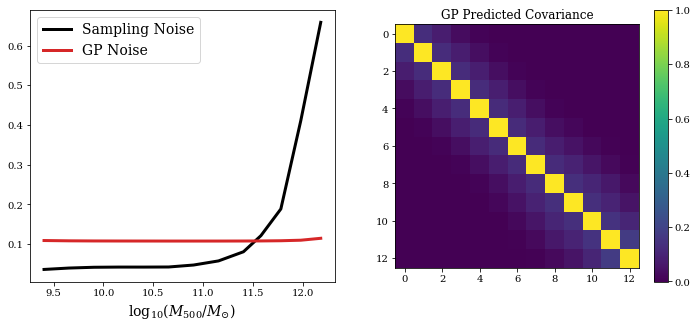

In [170]:
_, _, _, cov = get_gp_prediction(fid_pars, gsmf[:,0], model_smf, likelihood_smf, full_cov=True, model_key=None)
noise = sigma_smf_of_mass(gsmf[:,0])

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].plot(gsmf[:,0], noise, 'k-', label='Sampling Noise', lw=3)
ax[0].plot(gsmf[:,0], np.sqrt(np.diag(cov)), 'C3', label='GP Noise', lw=3)
ax[0].legend(fontsize=14)
ax[0].set_xlabel(r'$\log_{10}(M_{500}/M_{\odot})$', fontsize=14)

ax[1].set_title("GP Predicted Covariance")
img = ax[1].imshow(corr_matrix(cov), cmap='viridis')
plt.colorbar(img)

/lscratch/fgmaion/miniconda3/envs/condaenv/lib/python3.9/site-packages/gpytorch/likelihoods/gaussian_likelihood.py:347: GPInputWarning: You have passed data through a FixedNoiseGaussianLikelihood that did not match the size of the fixed noise, *and* you did not specify noise. This is treated as a no-op.
  warnings.warn(


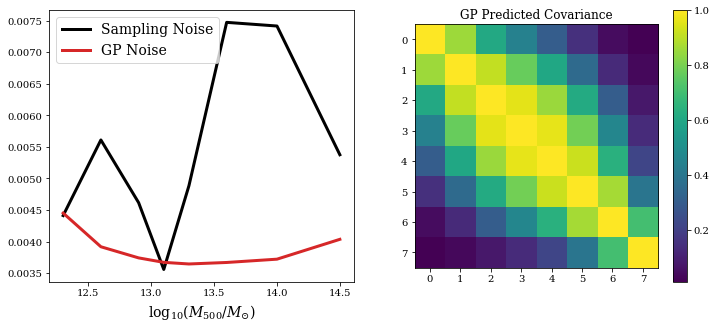

In [171]:
_, _, _, cov = get_gp_prediction(fid_pars, m500_pp, model_fgas, likelihood_fgas, full_cov=True, model_key=None)
noise = sigma_fgas_of_mass(m500_pp)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].plot(m500_pp, noise, 'k-', label='Sampling Noise', lw=3)
ax[0].plot(m500_pp, np.sqrt(np.diag(cov)), 'C3', label='GP Noise', lw=3)
ax[0].legend(fontsize=14)
ax[0].set_xlabel(r'$\log_{10}(M_{500}/M_{\odot})$', fontsize=14)

ax[1].set_title("GP Predicted Covariance")
img = ax[1].imshow(corr_matrix(cov), cmap='viridis')
plt.colorbar(img)

### Now let's look at the chains

In [172]:
param_means = np.array([np.mean(wind_en_or), np.mean(wind_vel_or), np.mean(rho_rec_or), 
                        np.mean(sf_ts_or), np.mean(ef_kin_or), np.mean(ef_high_or), np.mean(f_re_or)])
param_stds  = np.array([np.std(wind_en_or), np.std(wind_vel_or), np.std(rho_rec_or), 
                        np.std(sf_ts_or), np.std(ef_kin_or), np.std(ef_high_or), np.std(f_re_or)])

lower_bound = np.asarray([0.9,  3.7,  np.log10(0.005), 0.001135, np.log10(0.001), 0.05, 10, -np.inf, -np.inf])
upper_bound = np.asarray([14.4, 14.8, np.log10(0.5),   0.00454,  np.log10(2),     0.2,  40, np.inf, np.inf])

In [173]:
param_names = ['$\\bar{e}_w$', '$\\kappa_w$', '$\\rho_{rec}$',\
     '$t_{SFR}$', '$\\epsilon_{f,kin}$', '$\\epsilon_{f,high}$', '$f_{RE}$', 'b_star', 'b_cv']

### Let us Plot the Chains

With the Popesso et al data

In [40]:
colors = ['#0077BB', '#CC3311', '#009988']
line_args = [{'color':'#0077BB', 'lw':3}, {'color':'#CC3311', 'lw':3}, {'color':'#009988', 'lw':3}]

In [41]:
reader_smf = emcee.backends.HDFBackend('/cosmos_storage/home/fgmaion/MTNG-resims/mcmc_chains/smf_regular_chain.h5')
reader_fgas = emcee.backends.HDFBackend('/cosmos_storage/home/fgmaion/MTNG-resims/mcmc_chains/fgas_regular_popesso_chain.h5')
reader_joint = emcee.backends.HDFBackend('/cosmos_storage/home/fgmaion/MTNG-resims/mcmc_chains/joint_regular_popesso_chain.h5')

Removed no burn in
Removed no burn in


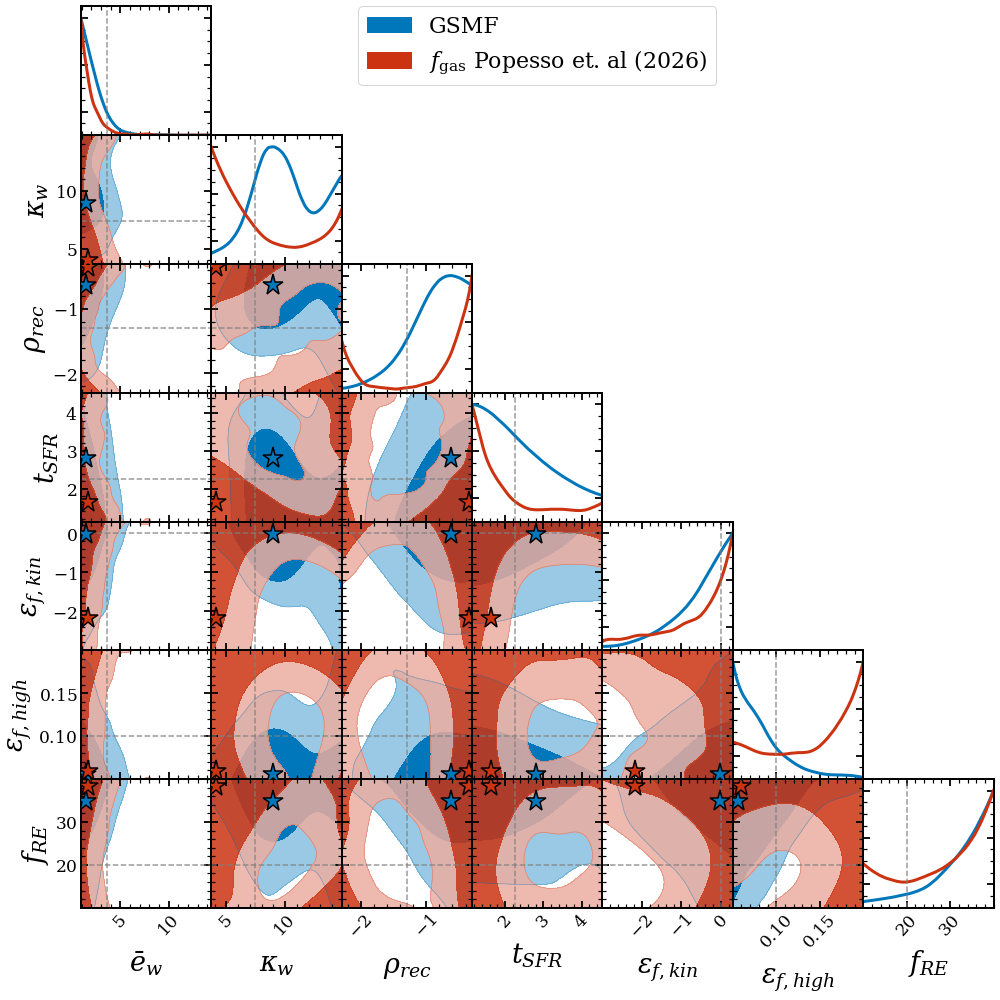

In [42]:
labels = ['GSMF', '$f_\mathrm{gas}$ Popesso et. al (2026)', '$f_\mathrm{gas}$ + GSMF']

plot_chains({0:'smf_regular_chain', 1:'fgas_regular_popesso_chain'}, colors=colors, labels=labels,
            legend_fontsize=25, line_args=line_args)
    
plt.savefig("/cosmos_storage/home/fgmaion/MTNG-resims/Notebooks/plots/smf_fgas_popesso_chains.pdf", bbox_inches='tight')

# plot_chains({0:'joint_regular_popesso_chain'}, colors=colors[2:], labels=labels[2:],
#             legend_fontsize=25, line_args=line_args[2:])

Removed no burn in


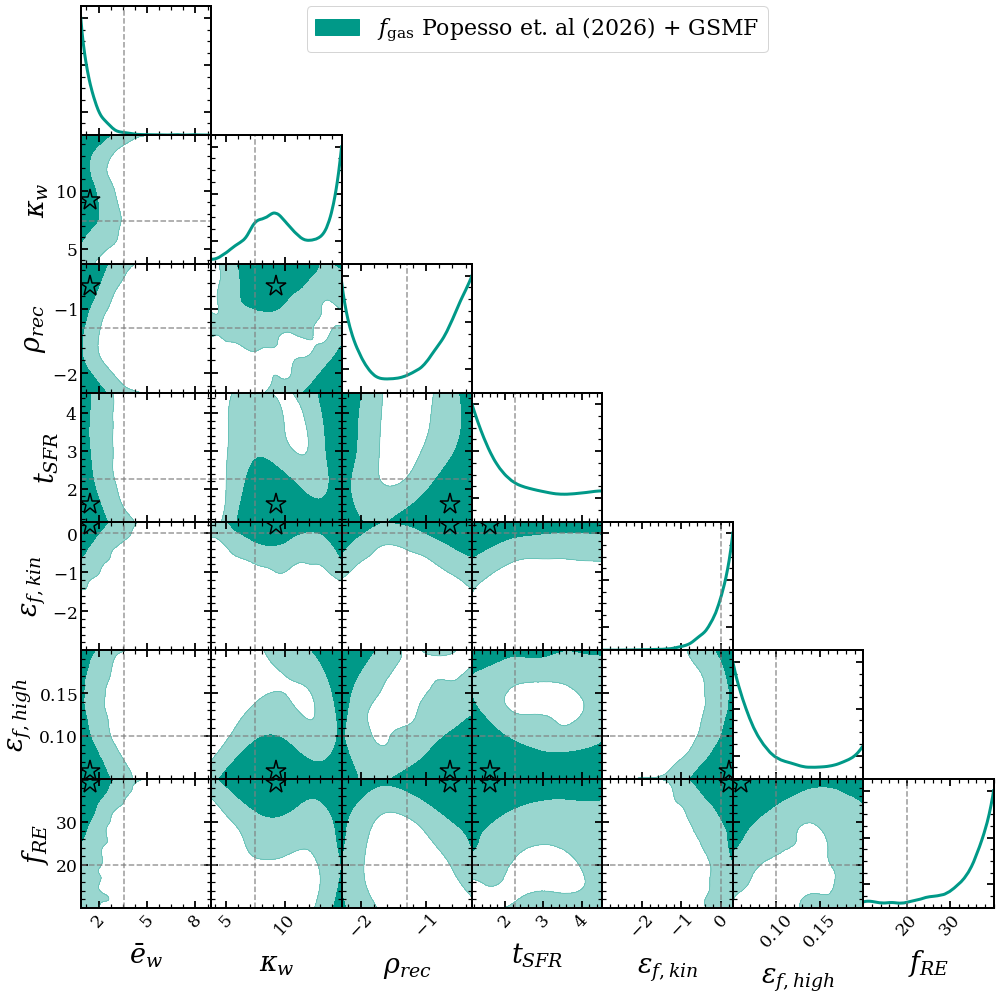

In [43]:
labels = ['GSMF', '$f_\mathrm{gas}$ Popesso et. al (2026)', '$f_\mathrm{gas}$ Popesso et. al (2026) + GSMF']
    
plot_chains({0:'joint_regular_popesso_chain'}, colors=colors[2:], labels=labels[2:],
            legend_fontsize=25, line_args=line_args[2:])

plt.savefig("/cosmos_storage/home/fgmaion/MTNG-resims/Notebooks/plots/joint_popesso_chains.pdf", bbox_inches='tight')

In [327]:
reader = emcee.backends.HDFBackend('/cosmos_storage/home/fgmaion/MTNG-resims/mcmc_chains/joint_regular_popesso_chain.h5')
samples, log_prob = get_samples(reader)

In [325]:
bf = get_bestfit(reader)
bf_std = np.std(samples, axis=0)

In [344]:
gd_param_names = ['\\bar{e}_w', '\\kappa_w', '\\rho_{rec}',\
     't_{SFR}', '\\epsilon_{f,kin}', '\\epsilon_{f,high}', 'f_{RE}', 'b_star', 'b_cv']
     
ranges = {gd_param_names[0]: [0.9, 14.4],
          gd_param_names[1]: [3.7, 14.8],
          gd_param_names[2]: [np.log10(0.005),np.log10(0.5)],
          gd_param_names[3]: [1.135, 4.54],
          gd_param_names[4]: [np.log10(0.001), np.log10(2)],
          gd_param_names[5]: [0.05, 0.2],
          gd_param_names[6]: [10, 40]}

mcsam = MCSamples(
    samples=samples,
    loglikes=-log_prob,
    names=gd_param_names,
    labels=gd_param_names,
    ranges=ranges
    )

# Marginalized stats (mean + 68/95/99% limits)
stats = mcsam.getMargeStats()
for name in gd_param_names:
    par = stats.parWithName(name)
    lim68 = par.limits[0]   # index 0 = 68%, 1 = 95%, 2 = 99%
#     print(f"{name}: {par.mean:.4f}  68% CI: [{lim68.lower:.4f}, {lim68.upper:.4f}]")


for name in gd_param_names:
     # Equal-tail two-sided limit for a single parameter
     lo, hi = mcsam.twoTailLimits(name, 0.68)
     par = stats.parWithName(name)
     if name in ['\\rho_{rec}', '\\epsilon_{f,kin}']:
         print(name+f" 68% equal-tail: [{10**(lo)-10**(par.mean):.4f}, {10**(hi)-10**(par.mean):.4f}]")
     else:
          print(name+f" 68% equal-tail: [{lo-par.mean:.4f}, {hi-par.mean:.4f}]")

Removed no burn in
\bar{e}_w 68% equal-tail: [-0.6503, 0.5774]
\kappa_w 68% equal-tail: [-3.0919, 3.7439]
\rho_{rec} 68% equal-tail: [-0.0651, 0.2956]
t_{SFR} 68% equal-tail: [-1.0718, 1.3132]
\epsilon_{f,kin} 68% equal-tail: [-0.4273, 0.9079]
\epsilon_{f,high} 68% equal-tail: [-0.0431, 0.0656]
f_{RE} 68% equal-tail: [-7.0299, 5.9640]
b_star 68% equal-tail: [-0.0901, 0.0875]
b_cv 68% equal-tail: [-0.0601, 0.0595]


### Plot some samples

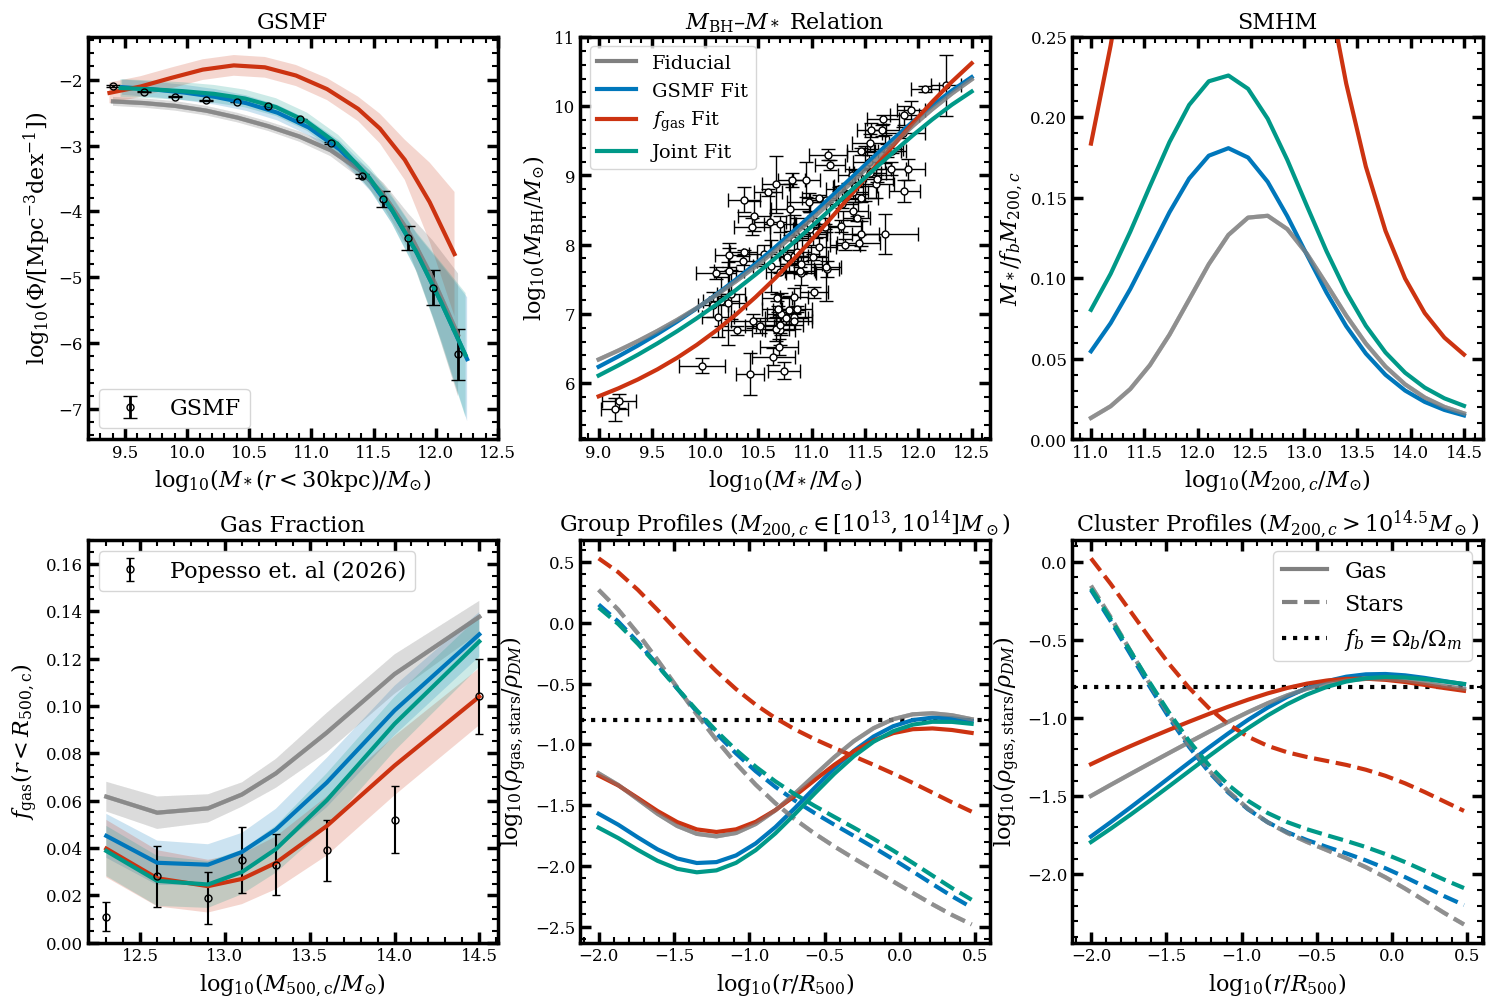

In [221]:
readers = [reader_smf, reader_fgas, reader_joint]
models = {'smf':model_smf, 'fgas':model_fgas, 'mbh_mstar':model_mbh_mstar, 'gprof_dm':model_gprof_dm, 'gprof_gas':model_gprof_gas, 'gprof_stars':model_gprof_stars,\
        'smhm':model_smhm, 'cprof_dm':model_cprof_dm, 'cprof_gas':model_cprof_gas, 'cprof_stars':model_cprof_stars}
likelihoods = {'smf':likelihood_smf, 'fgas':likelihood_fgas, 'mbh_mstar':likelihood_mbh_mstar, 'gprof_dm':likelihood_gprof_dm, 'gprof_gas':likelihood_gprof_gas, 'gprof_stars':likelihood_gprof_stars,\
        'smhm':likelihood_smhm, 'cprof_dm':likelihood_cprof_dm, 'cprof_gas':likelihood_cprof_gas, 'cprof_stars':likelihood_cprof_stars}

plot_best_fits(readers, models, likelihoods, colors, data_dict, "/summary_plot_popesso_new.pdf", bf_smf=None, bf_fgas=None)

### Load the best-fit measurements

In [281]:
Nbins_smf = 15
Nbins_fgas = 10

bf_smf = np.load("/cosmos_storage/home/fgmaion/MTNG-resims/results/smf/smf_{}_Nbins{:d}.npy".format('bestfit_run', Nbins_smf), allow_pickle=True)[0]
bf_fgas = np.load("/cosmos_storage/home/fgmaion/MTNG-resims/results/fgas/fgas_{}_Nbins{:d}.npy".format('bestfit_run', Nbins_fgas), allow_pickle=True)[0]

In [282]:
bf_smf

{'smf': {0: array([9.44190781e-03, 1.09266144e-02, 9.91613382e-03, 7.35479018e-03,
         6.02534399e-03, 5.30317286e-03, 4.06142804e-03, 2.17141718e-03,
         8.49679794e-04, 3.99385909e-04, 8.18426793e-05, 3.34214150e-05,
         1.37266526e-06])},
 'bins': array([1.00000000e+09, 1.77827941e+09, 3.16227766e+09, 5.62341325e+09,
        1.00000000e+10, 1.77827941e+10, 3.16227766e+10, 5.62341325e+10,
        1.00000000e+11, 1.77827941e+11, 3.16227766e+11, 5.62341325e+11,
        1.00000000e+12, 1.77827941e+12, 3.16227766e+12]),
 'mstar': {0: array([1.36810416e+09, 2.40914167e+09, 4.26436931e+09, 7.74546202e+09,
         1.31899155e+10, 2.48488180e+10, 4.12795110e+10, 7.36076716e+10,
         1.27721688e+11, 2.33799870e+11, 3.72976353e+11, 6.85872039e+11,
         1.02478775e+12])}}

In [308]:
from matplotlib.lines import Line2D
from matplotlib.container import ErrorbarContainer

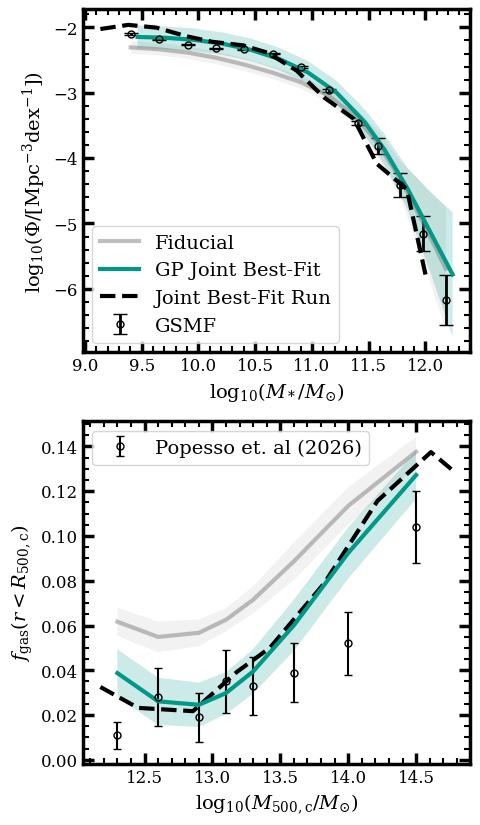

In [310]:
fig, axs = plt.subplots(2, 1, figsize=(5,10), dpi=100)

err_handle = axs[0].errorbar(gsmf[:,0], gsmf[:,1], yerr=gsmf[:,2],
                color='k', marker='o', markersize=5, fillstyle='none',
                capsize=5, label='GSMF', elinewidth=2, ls='')
plot_smf(axs[0], gsmf[:,0], fid_pars, bf, colors[2])
axs[0].plot(np.log10(bf_smf['mstar'][0]), np.log10(bf_smf['smf'][0]), color='k', lw=3, ls='--', label='Joint Best-Fit Run')
axs[0].set_xlabel(r'$\log_{10}(M_*/M_{\odot})$', fontsize=14)
axs[0].set_ylabel(r'$\log_{10}(\Phi/[$Mpc$^{-3}$dex$^{-1}])$', fontsize=14)

handles = [Line2D([0], [0], color='gray', alpha=0.5, lw=3, label='Fiducial'),
           Line2D([0], [0], color=colors[2], alpha=1, lw=3, label='GP Joint Best-Fit'),
           Line2D([0], [0], color='k', alpha=1, lw=3, ls='--', label='Joint Best-Fit Run'),
           err_handle]
axs[0].legend(handles=handles, fontsize=14, loc='lower left', ncol=1)

axs[1].set_xlabel(r'$\log_{10}(M_{500,\mathrm{c}}/M_{\odot})$', fontsize=14)
axs[1].set_ylabel(r'$f_{\mathrm{gas}}(r<R_{500,\mathrm{c}})$', fontsize=14)
axs[1].plot(np.log10(bf_fgas['m500c'][0]), bf_fgas['f_gas'][0], color='k', lw=3, ls='--')
axs[1].errorbar(data_dict['mhalo'], data_dict['fgas_obs'], yerr=data_dict['fgas_err'],
                    fmt='ko', markersize=5, fillstyle='none', capsize=3,
                    label=data_dict['fgas_label'])
axs[1].legend(fontsize=14, loc='upper left')                    

plot_obs_vs_model(axs[1], m500_pp, 'fgas', fid_pars[:7], bf[:7], colors[2])

# ---------- styling ----------
for ax_ in axs:
    for spine in ax_.spines.values():
        spine.set_linewidth(2.5)
    ax_.tick_params(axis='both', which='major', width=2.5, length=8, labelsize=12, direction='in', top=True, right=True)
    ax_.tick_params(axis='both', which='minor', width=1.5, length=4, direction='in', top=True, right=True)
    ax_.minorticks_on()

name = "comparison_smf_fgas_bestfit_run.pdf"
plt.subplots_adjust(hspace=0.2)
plt.savefig("/cosmos_storage/home/fgmaion/MTNG-resims/Notebooks/plots/" + name, bbox_inches='tight')
# plt.show()


In [143]:
# # Load Moustakas et al. GSMF measurements
# gsmf_z = np.loadtxt('/cosmos_storage/home/fgmaion/MTNG-resims/data/moustakas.csv',
#                     delimiter=',', skiprows=1)
# # columns: z_low, z_high, log_M, log_Phi, log_Phi_err_up, log_Phi_err_dn, sigma_cv, N

# n_z = len(z_list)
# ncols = int(np.ceil(np.sqrt(n_z)))
# nrows = int(np.ceil(n_z / ncols))

# fig, axes = plt.subplots(nrows, ncols, dpi=200, figsize=(3.5*ncols, 3.5*nrows),
#                          sharex=True, sharey=True)
# axes = np.atleast_1d(axes).flatten()

# for i in range(n_z):
#     ax = axes[i]

#     # Select Moustakas rows whose [z_low, z_high] bracket z_list[i]
#     mask = (gsmf_z[:, 0] <= z_list[i]) & (gsmf_z[:, 1] >= z_list[i]) & (gsmf_z[:,2] > 9.2)

#     if mask.any():
#         # Identify unique bins among matched rows
#         bins = np.unique(gsmf_z[mask][:, :2], axis=0)

#         # Use the mass values of the first matching bin for the GP prediction
#         first_bin_mask = mask & (gsmf_z[:, 0] == bins[0, 0]) & (gsmf_z[:, 1] == bins[0, 1])
#         mstar_test = gsmf_z[first_bin_mask, 2]

#         mu_bf, _, cov_bf = get_gp_prediction(bestfit_params[:7], mstar_test, model_smf_z[i],
#                                              likelihood_smf_z[i],
#                                              full_cov=True, model_key='smf')
#         sd_bf = np.sqrt(np.diag(cov_bf))

#         if i==0:
#             ax.plot(mstar_test, mu_bf, color='#009988', lw=2, label='GP emulator ( $f_\mathrm{gas}$ + GSMF )')
#         else:
#             ax.plot(mstar_test, mu_bf, color='#009988', lw=2)
#         ax.fill_between(mstar_test, mu_bf - sd_bf, mu_bf + sd_bf,
#                         color='#009988', alpha=0.5, edgecolor=None)

#         # Overplot each matching Moustakas bin with a different shade
#         shades = ['k', 'dimgray', 'darkgray']
#         for k, (z_lo, z_hi) in enumerate(bins):
#             bin_mask = mask & (gsmf_z[:, 0] == z_lo) & (gsmf_z[:, 1] == z_hi)
#             ax.errorbar(gsmf_z[bin_mask, 2], gsmf_z[bin_mask, 3],
#                         yerr=[gsmf_z[bin_mask, 5], gsmf_z[bin_mask, 4]],
#                         fmt='o', ms=3, color=shades[k % len(shades)],
#                         label='Moustakas+13 ({:.2f}<z<{:.2f})'.format(z_lo, z_hi), capsize=3)

#     ax.set_title('z={:.2f}'.format(z_list[i]))
#     ax.legend(fontsize=8, loc='lower left')

# # ---------- styling ----------
# for ax_ in axes:
#     for spine in ax_.spines.values():
#         spine.set_linewidth(2.5)
#     ax_.tick_params(axis='both', which='major', width=2.5, length=8, labelsize=12, direction='in', top=True, right=True)
#     ax_.tick_params(axis='both', which='minor', width=1.5, length=4, direction='in', top=True, right=True)
#     ax_.minorticks_on()

# # Hide any unused panels
# for j in range(n_z, len(axes)):
#     axes[j].axis('off')

# fig.supxlabel(r'$\log_{10}[M_\star/M_\odot]$')
# fig.supylabel(r'$\log_{10}[\Phi/(\mathrm{Mpc}^{-3}\mathrm{dex}^{-1})]$')
# fig.tight_layout()

# # plt.savefig(s, bbox_inches='tight')

In [144]:
"""
Lange et al. 2015 (GAMA), MNRAS 447, 2603 -- stellar mass--half-light radius relation.
r-band parameters, both early- and late-type, for all five population cuts.

R_e = semi-major-axis effective radius [kpc]; M* in solar masses.
Cosmology: Omega_m=0.3, Omega_L=0.7, H0=70.

  single : R_e = a * M*^b                                  (eq. 2)
  double : R_e = gamma * M*^alpha * (1 + M*/M0)^(beta-alpha) (eq. 3)

Paper's recommendation: single power law for LATE types, double for EARLY types
(early-type relation flattens at low mass; single fit is too shallow at high mass).

NOTE: 'a' is already scaled to plain units (paper tabulates it as x1e-3 for late,
x1e-5 for early). M0 entries are in units of 1e10 Msun and scaled in the function.
Tuple order: (a, b, alpha, beta, gamma, M0_in_1e10_Msun)
"""

_PARAMS = {
    "late": {
        "sersic":     (27.72e-3, 0.21, 0.16, 0.81, 0.08, 17.10),
        "u-r":        (13.63e-3, 0.25, 0.17, 0.73, 0.08,  8.56),
        "g-i":        (13.98e-3, 0.25, 0.19, 0.79, 0.05, 13.31),
        "sersic_u-r": (15.16e-3, 0.24, 0.15, 0.68, 0.11,  6.39),
        "morphology": (37.24e-3, 0.20, 0.16, 1.00, 0.10, 33.62),
    },
    "early": {
        "sersic":     (8.37e-5, 0.44, 0.10, 0.76, 0.16, 2.42),
        "u-r":        (7.32e-5, 0.44, 0.10, 0.75, 0.17, 2.31),
        "g-i":        (8.25e-5, 0.44, 0.10, 0.74, 0.17, 2.24),
        "sersic_u-r": (0.30e-5, 0.57, 0.12, 0.78, 0.08, 1.54),
        "morphology": (4.19e-5, 0.46, 0.11, 0.78, 0.12, 2.25),
    },
}

# default functional form recommended by the paper, per type
_DEFAULT_FORM = {"late": "single", "early": "double"}


def lange2015_size(mstar, gtype="late", form=None, case="sersic"):
    """
    Effective radius [kpc] vs stellar mass [Msun], r-band.

    gtype : "late" or "early"
    form  : "single" or "double"; None -> paper's recommended form for that type
    case  : "sersic", "u-r", "g-i", "sersic_u-r", or "morphology"
    """
    if form is None:
        form = _DEFAULT_FORM[gtype]
    a, b, alpha, beta, gamma, M0_10 = _PARAMS[gtype][case]
    M0 = M0_10 * 1e10

    if form == "single":
        return a * mstar ** b
    elif form == "double":
        return gamma * mstar ** alpha * (1.0 + mstar / M0) ** (beta - alpha)
    else:
        raise ValueError("form must be 'single' or 'double'")


if __name__ == "__main__":
    for logm in (9.0, 10.0, 11.0):
        m = 10 ** logm
        late = lange2015_size(m, "late")    # single (recommended)
        early = lange2015_size(m, "early")  # double (recommended)
        print(f"logM*={logm:4.1f}:  late={late:5.2f} kpc   early={early:5.2f} kpc")

logM*= 9.0:  late= 2.15 kpc   early= 1.31 kpc
logM*=10.0:  late= 3.49 kpc   early= 2.01 kpc
logM*=11.0:  late= 5.66 kpc   early= 5.93 kpc


In [212]:
mstar = np.linspace(9.2, 12.5, 20)

mu_rhalf, _, cov_rhalf = get_gp_prediction(bf[:7], mstar, model_rhalf,
                                                likelihood_rhalf,
                                                full_cov=True, model_key='size_mass')

mu_rhalf_fid, _, cov_rhalf_fid = get_gp_prediction(fid_pars[:7], mstar, model_rhalf,
                                                likelihood_rhalf,
                                                full_cov=True, model_key='size_mass')


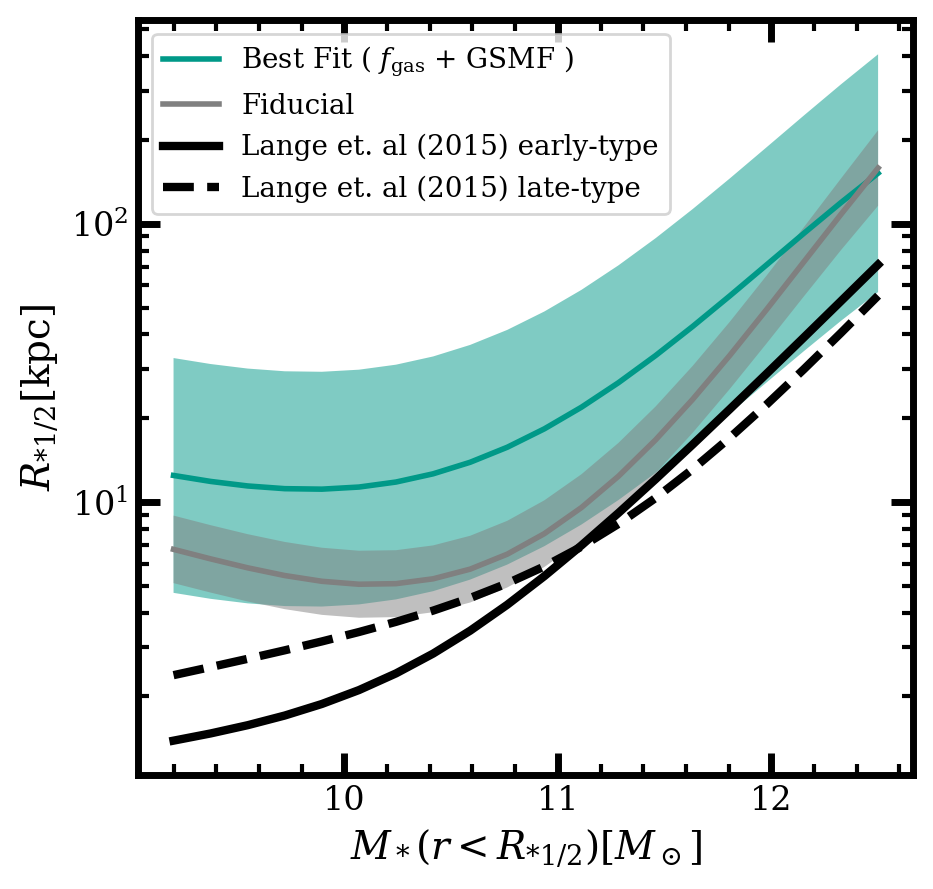

In [213]:
fig, ax = plt.subplots(dpi=200, figsize=(5,5))

ax.set_yscale('log')
ax.plot(mstar, 1e3 * 10**mu_rhalf, color=colors[2], lw=2, label='Best Fit ( $f_\mathrm{gas}$ + GSMF )')
ax.fill_between(mstar, 1e3 * 10**(mu_rhalf - np.sqrt(np.diag(cov_rhalf))),
                    1e3 * 10**(mu_rhalf + np.sqrt(np.diag(cov_rhalf))),
                    color=colors[2], alpha=0.5, edgecolor=None)

ax.plot(mstar, 1e3 * 10**mu_rhalf_fid, color='gray', lw=2, label='Fiducial')
ax.fill_between(mstar, 1e3 * 10**(mu_rhalf_fid - np.sqrt(np.diag(cov_rhalf_fid))),
                    1e3 * 10**(mu_rhalf_fid + np.sqrt(np.diag(cov_rhalf_fid))),
                    color='gray', alpha=0.5, edgecolor=None)

ax.plot(mstar, lange2015_size(10**mstar, gtype="early", form='double', case="sersic"), color='k', lw=3, label="Lange et. al (2015) early-type")
ax.plot(mstar, lange2015_size(10**mstar, gtype="late", form='double', case="sersic"), color='k', ls='--', lw=3, label="Lange et. al (2015) late-type")

for spine in ax.spines.values():
    spine.set_linewidth(2.5)
ax.tick_params(axis='both', which='major', width=2.5, length=8, labelsize=12, direction='in', top=True, right=True)
ax.tick_params(axis='both', which='minor', width=1.5, length=4, direction='in', top=True, right=True)
ax.minorticks_on()

ax.set_ylabel("$R_{*1/2}$[kpc]", fontsize=14)
ax.set_xlabel("$M_*(r<R_{*1/2})[M_\odot]$", fontsize=14)

ax.legend(loc='upper left')

plt.savefig("/cosmos_storage/home/fgmaion/MTNG-resims/Notebooks/plots/rhalf_mstar.pdf", bbox_inches='tight')

And with the Kugel data

In [215]:
reader_fgas_kugel = emcee.backends.HDFBackend('/cosmos_storage/home/fgmaion/MTNG-resims/mcmc_chains/fgas_regular_kugel_chain.h5')
reader_joint_kugel = emcee.backends.HDFBackend('/cosmos_storage/home/fgmaion/MTNG-resims/mcmc_chains/joint_regular_kugel_chain.h5')

Removed no burn in


Removed no burn in


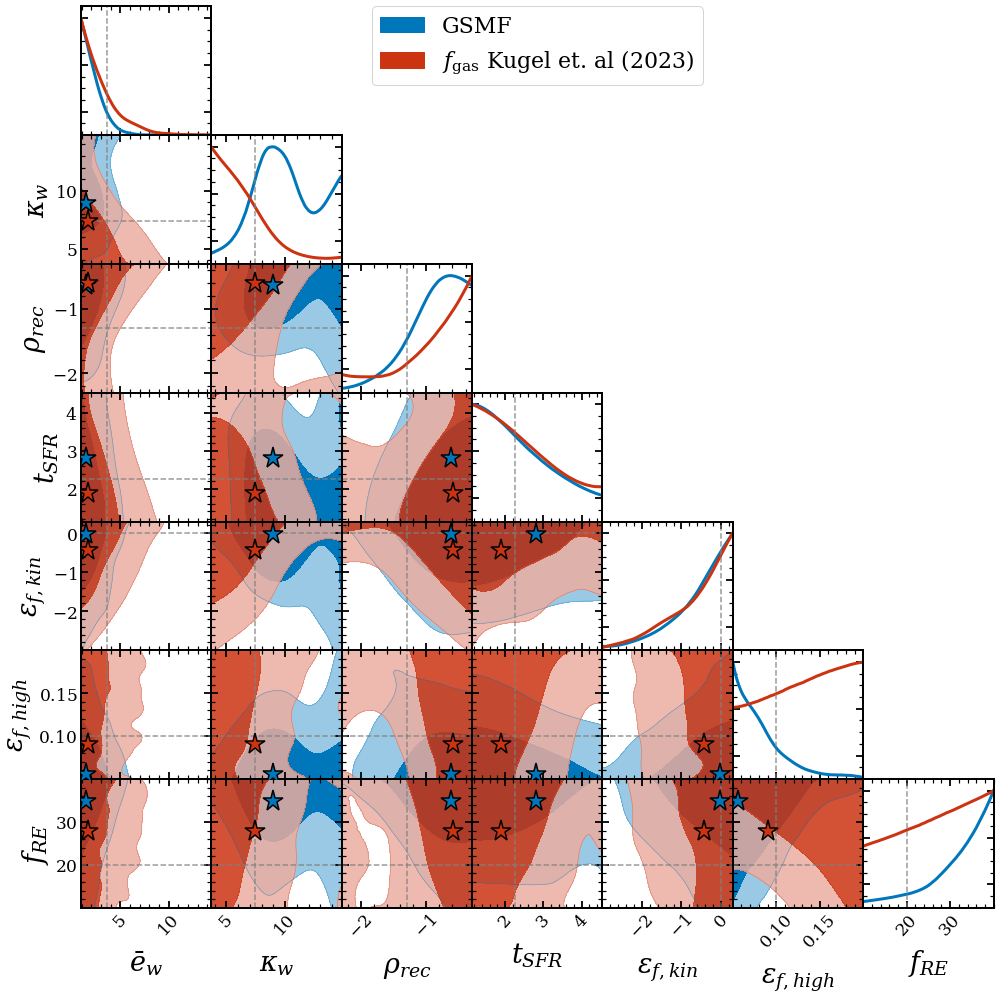

In [216]:
line_args = [{'color':'#0077BB', 'lw':3}, {'color':'#CC3311', 'lw':3}, {'color':'#009988', 'lw':3}]
labels = ['GSMF', '$f_\mathrm{gas}$ Kugel et. al (2023)', '$f_\mathrm{gas}$ + GSMF']

plot_chains({0:'smf_regular_chain', 1:'fgas_regular_kugel_chain'}, colors=colors, labels=labels,
            legend_fontsize=25, line_args=line_args)

plt.savefig("/cosmos_storage/home/fgmaion/MTNG-resims/Notebooks/plots/smf_fgas_kugel_chains.pdf", bbox_inches='tight')

            

Removed no burn in


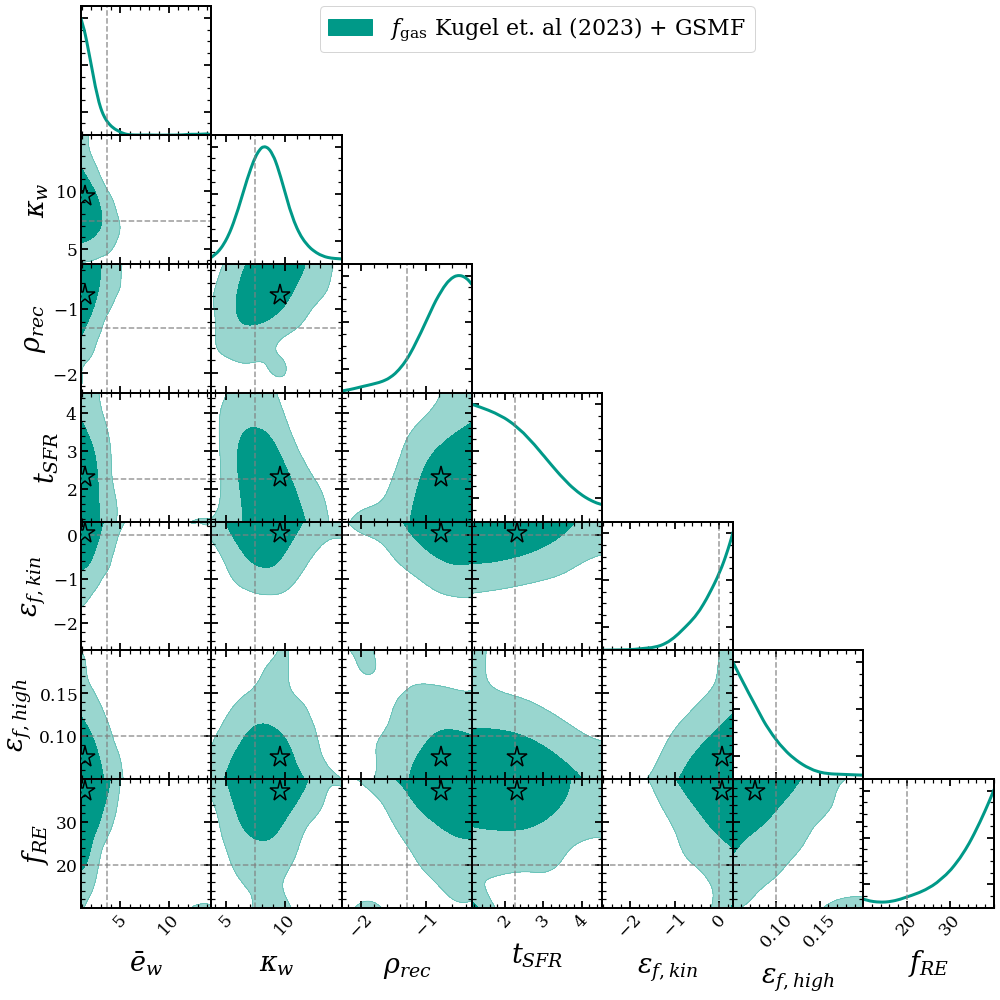

In [217]:
line_args = [{'color':'#0077BB', 'lw':3}, {'color':'#CC3311', 'lw':3}, {'color':'#009988', 'lw':3}]
labels = ['GSMF', '$f_\mathrm{gas}$ Kugel et. al (2023)', '$f_\mathrm{gas}$ Kugel et. al (2023) + GSMF']

plot_chains({0:'joint_regular_kugel_chain'}, colors=colors[2:], labels=labels[2:],
            legend_fontsize=25, line_args=line_args[2:])

plt.savefig("/cosmos_storage/home/fgmaion/MTNG-resims/Notebooks/plots/joint_kugel_chains.pdf", bbox_inches='tight')

In [180]:
# Observations for SMF
data_dict = {
    'mstar':     np.array(gsmf[:,0]), # Mass bins
    'smf_obs':   np.array(gsmf[:,1]), # log10(Phi)
    'smf_err':   np.array(gsmf[:,2]), # Uncertainty in log10(Phi)

    # Observations for Gas Fractions
    'mhalo':     m500_kugel, # Halo mass bins (input)
    'fgas_obs':  fgas_kugel, # Measured gas fraction
    'fgas_err':  err_kugel, # Uncertainty in gas fraction (y-axis)
    'mhalo_err': np.array(np.zeros_like(m500_kugel)),  # Uncertainty in halo mass (x-axis)
    'fgas_label': 'Kugel et. al',

    # Observations for M_star - M_BH relation
    'mbh': df['log_Mbh_Msun'].values,
    'mstar_mbh': df['log_Mgal_Msun'].values,
    'mbh_err': df['log_Mbh_err'].values,
    'mstar_mbh_err': df['log_Mgal_err'].values
}

# Wrap models
models_dict = {
    'gp_smf':  model_smf,
    'gp_fgas': model_fgas
}


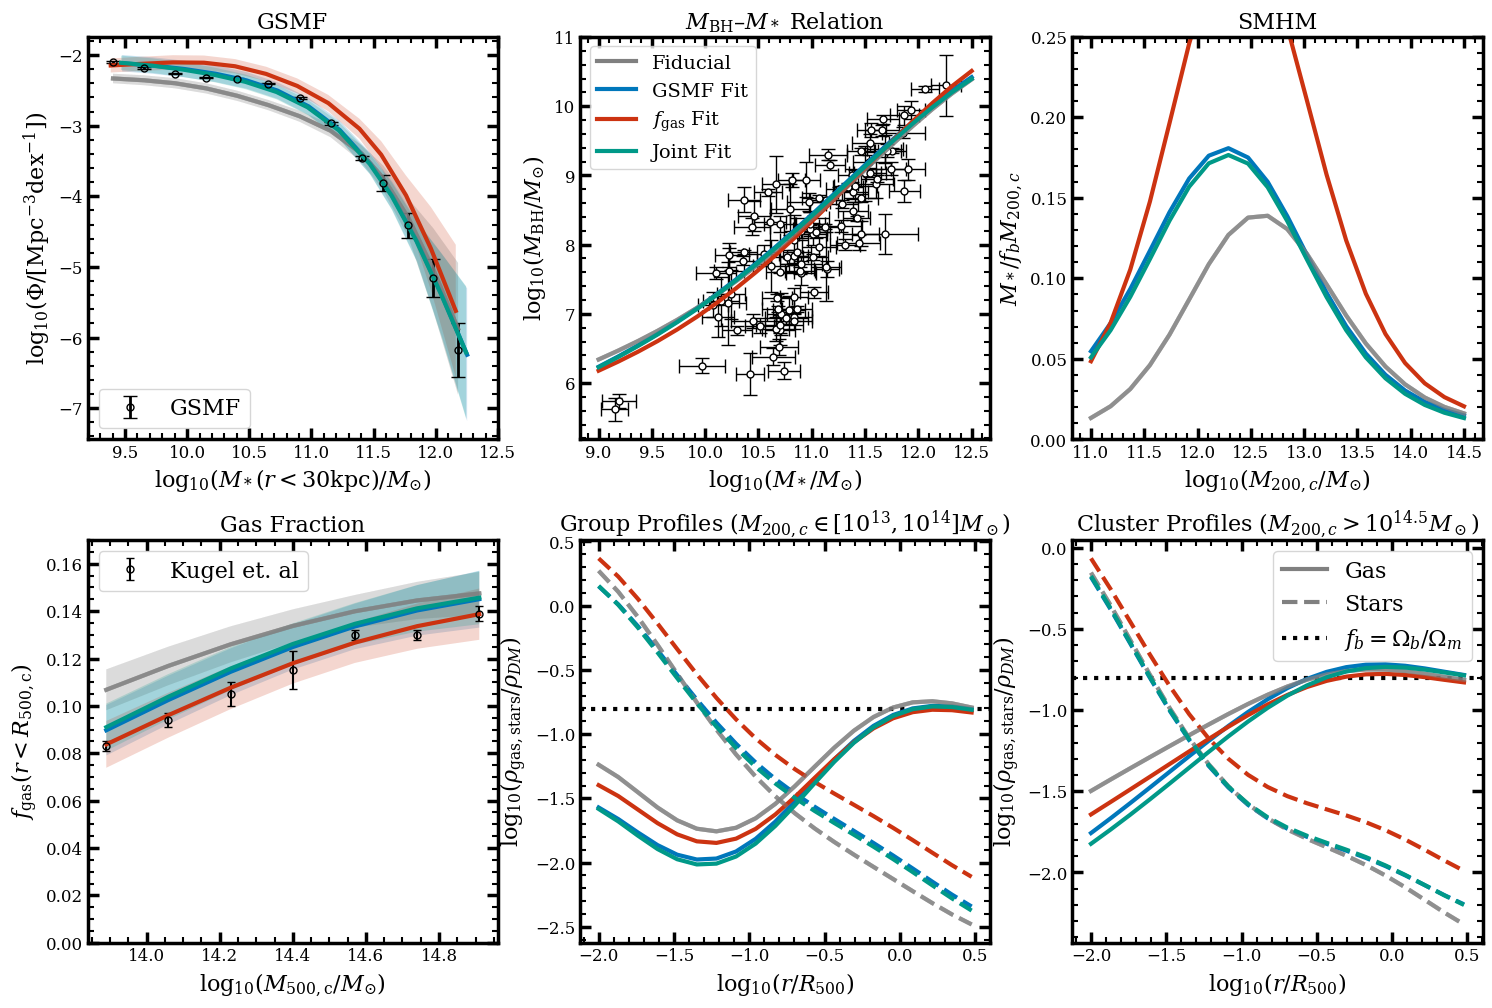

In [218]:
readers = [reader_smf, reader_fgas_kugel, reader_joint_kugel]
models = {'smf':model_smf, 'fgas':model_fgas, 'mbh_mstar':model_mbh_mstar, 'smhm':model_smhm,\
         'gprof_dm':model_gprof_dm, 'gprof_gas':model_gprof_gas, 'gprof_stars':model_gprof_stars,\
         'cprof_dm':model_cprof_dm, 'cprof_gas':model_cprof_gas, 'cprof_stars':model_cprof_stars}
likelihoods = {'smf':likelihood_smf, 'fgas':likelihood_fgas, 'mbh_mstar':likelihood_mbh_mstar, 'gprof_dm':likelihood_gprof_dm, 'gprof_gas':likelihood_gprof_gas, 'gprof_stars':likelihood_gprof_stars,\
        'smhm':likelihood_smhm, 'cprof_dm':likelihood_cprof_dm, 'cprof_gas':likelihood_cprof_gas, 'cprof_stars':likelihood_cprof_stars}

plot_best_fits(readers, models, likelihoods, colors, data_dict, "/summary_plot_kugel.pdf")

NameError: name 'mu_smf' is not defined

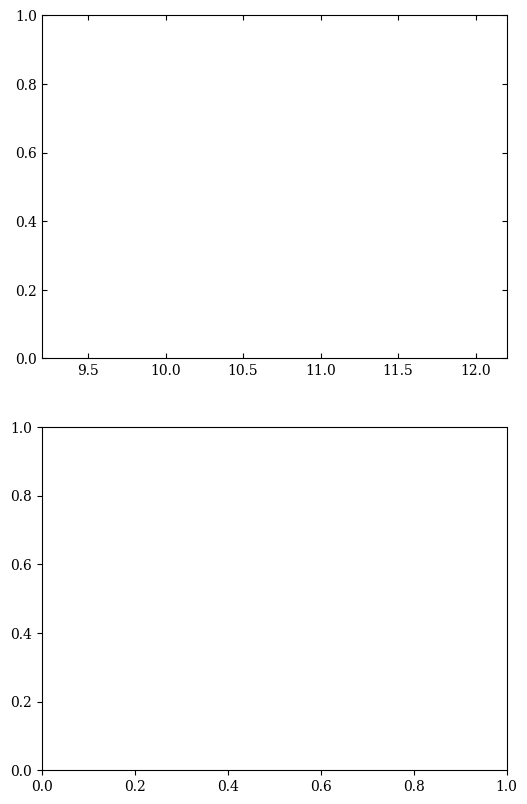

In [ ]:
fig, ax = plt.subplots(2, 1, figsize=(6, 10), dpi=100)

# --- LEFT COLUMN: SMF ---
ax1 = ax[0]
ax1.set_xlim(9.2,12.2)
ax1.tick_params(direction='in', top=True, right=True)

ax1.fill_between(mstar, mu_smf - np.sqrt(var_smf), mu_smf + np.sqrt(var_smf), color='C0', alpha=0.2, edgecolor=None)
ax1.plot(mstar, mu_smf, 'C0-', lw=3, label='SMF Best Fit')

ax1.fill_between(mstar, mu_smf_2 - np.sqrt(var_smf_2), mu_smf_2 + np.sqrt(var_smf_2), color='C3', alpha=0.2, edgecolor=None)
ax1.plot(mstar, mu_smf_2, 'C3-', lw=3, label='$f_{gas}$ Best Fit')

ax1.fill_between(mstar, mu_smf_3 - np.sqrt(var_smf_3), mu_smf_3 + np.sqrt(var_smf_3), color='C2', alpha=0.2, edgecolor=None)
ax1.plot(mstar, mu_smf_3, 'C2-', lw=3, label='Joint Best Fit')

ax1.errorbar(mstar, obs_log_phi, yerr=obs_uncertainty, color='k', marker='o', markersize=5, fillstyle='none',\
    capsize=5, label='Driver et al. (2022)', elinewidth=2, ls='')

ax1.set_xlabel('$\log_{10}(M_*(r<30$kpc$)/M_{\odot})$', fontsize=14)
ax1.set_ylabel('$\log_{10}(\Phi/[$Mpc$^{-3}$dex$^{-1}])$', fontsize=14)
ax1.legend(loc='lower left', frameon=False, fontsize=16)

# Bottom Column: Gas Fraction
ax2 = ax[1]
ax2.set_xlim(12, 14.7)
ax2.set_ylim(0.0,0.17)
ax2.tick_params(direction='in', top=True, right=True)

ax2.fill_between(data_dict['mhalo'], mu_fgas - np.sqrt(var_fgas), mu_fgas + np.sqrt(var_fgas), 
                        color='C0', alpha=0.2, edgecolor=None)
ax2.plot(data_dict['mhalo'], mu_fgas, 'C0-', lw=3)

ax2.fill_between(data_dict['mhalo'], mu_fgas_2 - np.sqrt(var_fgas_2), mu_fgas_2 + np.sqrt(var_fgas_2), 
                        color='C3', alpha=0.2, edgecolor=None)
ax2.plot(data_dict['mhalo'], mu_fgas_2, 'C3-', lw=3)

ax2.fill_between(data_dict['mhalo'], mu_fgas_3 - np.sqrt(var_fgas_3), mu_fgas_3 + np.sqrt(var_fgas_3), 
                        color='C2', alpha=0.2, edgecolor=None)
ax2.plot(data_dict['mhalo'], mu_fgas_3, 'C2-', lw=3)

ax2.errorbar(data_dict['mhalo'], data_dict['fgas_obs'], yerr=data_dict['fgas_err'], 
                    fmt='ko', markersize=5, fillstyle='none',
                    capsize=3, label='Popesso et al. (2025)')
ax2.axhline(0.15733247005503398, color='k', ls='--', lw=2, label='$f_b=\Omega_b/\Omega_m$')

ax2.set_xlabel('$\log_{10}(M_{500,\\mathrm{c}}/M_{\odot})$', fontsize=14)
ax2.set_ylabel('$f_{\\mathrm{gas}}(r<R_{500,\\mathrm{c}})$', fontsize=14)
ax2.legend(loc='upper left', frameon=True, fontsize=16)

plt.tight_layout()
# plt.savefig("/cosmos_storage/home/fgmaion/MTNG-resims/results/fits/fit_comparison_original_LH.pdf", dpi=200)

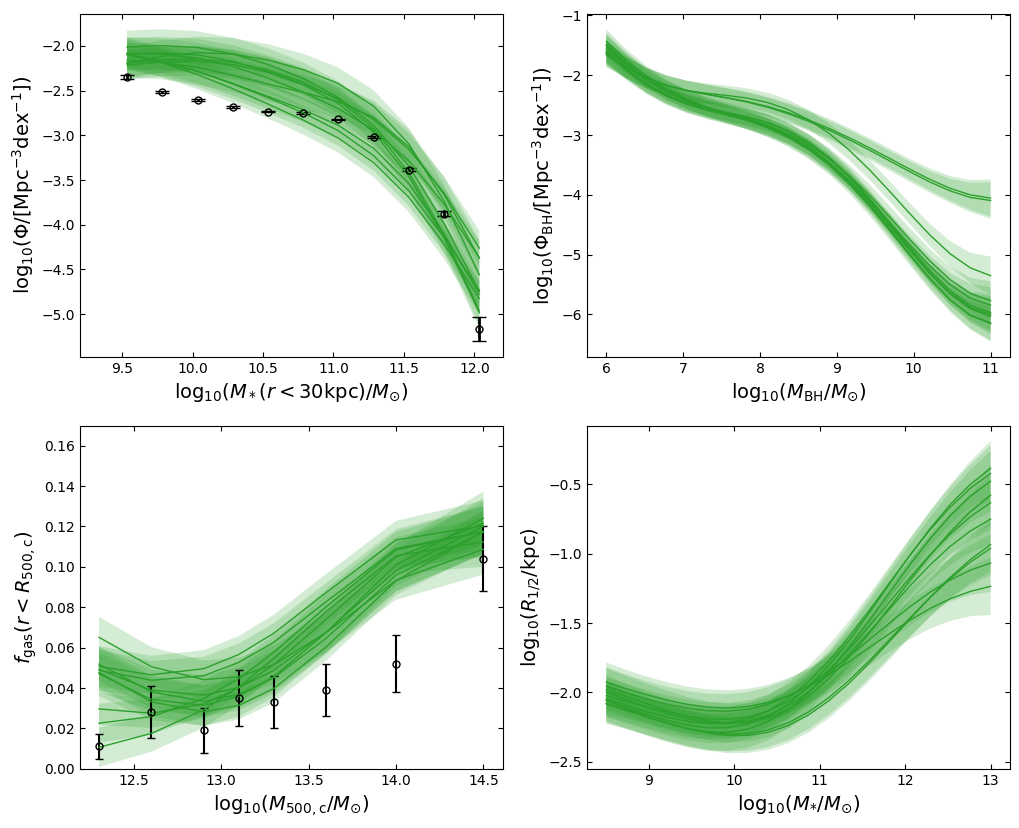

: 

In [ ]:
readers = [reader_joint]
colors = ['C2']

fig, ax = plt.subplots(2, 2, figsize=(12, 10), dpi=100)

# --- TOP LEFT COLUMN: SMF ---
ax1 = ax[0,0]
ax1.set_xlim(9.2,12.2)
ax1.tick_params(direction='in', top=True, right=True)

ax1.set_xlabel('$\log_{10}(M_*(r<30$kpc$)/M_{\odot})$', fontsize=14)
ax1.set_ylabel('$\log_{10}(\Phi/[$Mpc$^{-3}$dex$^{-1}])$', fontsize=14)

# BOTTOM LEFT COLUMN: Gas Fraction
ax2 = ax[1,0]
# ax2.set_xlim(12, 14.7)
ax2.set_ylim(0.0,0.17)
ax2.tick_params(direction='in', top=True, right=True)

ax2.errorbar(data_dict['mhalo'], data_dict['fgas_obs'], yerr=data_dict['fgas_err'], 
                fmt='ko', markersize=5, fillstyle='none',
                capsize=3, label=data_dict['fgas_label'])

ax2.set_xlabel('$\log_{10}(M_{500,\\mathrm{c}}/M_{\odot})$', fontsize=14)
ax2.set_ylabel('$f_{\\mathrm{gas}}(r<R_{500,\\mathrm{c}})$', fontsize=14)

# TOP RIGHT COLUMN: BHMF
ax3 = ax[0,1]
# ax3.set_xlim(12, 14.7)
# ax3.set_ylim(0.0,0.17)
ax3.tick_params(direction='in', top=True, right=True)

ax3.set_xlabel('$\log_{10}(M_{\\mathrm{BH}}/M_{\odot})$', fontsize=14)
ax3.set_ylabel('$\log_{10}(\\Phi_{\\mathrm{BH}}/[$Mpc$^{-3}$dex$^{-1}])$', fontsize=14)

# BOTTOM RIGHT COLUMN: BHMF
ax4 = ax[1,1]
# ax4.set_xlim(12, 14.7)
# ax4.set_ylim(0.0,0.17)
ax4.tick_params(direction='in', top=True, right=True)

ax4.set_xlabel('$\log_{10}(M_{*}/M_{\odot})$', fontsize=14)
ax4.set_ylabel('$\log_{10}(R_{1/2}/$kpc$)$', fontsize=14)

for i in range(len(readers)):
    some_pars = get_some_samples(readers[i])

    if i==0:
        GAMA_data = model_GAMA(GAMA_corr, some_pars[0][7], some_pars[0][8])

        obs_log_phi = GAMA_data[9:,1]
        obs_uncertainty = GAMA_data[9:,2]
        mstar = GAMA_data[9:,0]
        
        ax1.errorbar(mstar, obs_log_phi, yerr=obs_uncertainty, color='k', marker='o', markersize=5, fillstyle='none',\
            capsize=5, label='Driver et al. (2022)', elinewidth=2, ls='')

    for j in range(10):
        # SMF Predictions
        mu_smf, var_smf = get_gp_prediction(some_pars[j][:7], mstar, models['smf'])
        ax1.fill_between(mstar, mu_smf - np.sqrt(var_smf), mu_smf + np.sqrt(var_smf), color=colors[i], alpha=0.2, edgecolor=None)
        ax1.plot(mstar, mu_smf, colors[i], lw=1)

        # Gas Fraction Predictions
        mu_fgas, var_fgas = get_gp_prediction(some_pars[j][:7], data_dict['mhalo'], models['fgas'])
        ax2.fill_between(data_dict['mhalo'], mu_fgas - np.sqrt(var_fgas), mu_fgas + np.sqrt(var_fgas), 
                                color=colors[i], alpha=0.2, edgecolor=None)
        ax2.plot(data_dict['mhalo'], mu_fgas, colors[i], lw=1)

        # BHMF Predictions
        mbh = np.linspace(6, 11, 20)
        mu_bhmf, var_bhmf = get_gp_prediction(some_pars[j][:7], mbh, models['bhmf'])
        ax3.fill_between(mbh, mu_bhmf - np.sqrt(var_bhmf), mu_bhmf + np.sqrt(var_bhmf), color=colors[i], alpha=0.2, edgecolor=None)
        ax3.plot(mbh, mu_bhmf, colors[i], lw=1)

        # Size-Mass Predictions
        m2half = np.linspace(8.5,13,20)
        mu_rhalf, var_rhalf = get_gp_prediction(some_pars[j][:7], m2half, models['size_mass'])
        ax4.fill_between(m2half, mu_rhalf - np.sqrt(var_rhalf), mu_rhalf + np.sqrt(var_rhalf), color=colors[i], alpha=0.2, edgecolor=None)
        ax4.plot(m2half, mu_rhalf, colors[i], lw=1)

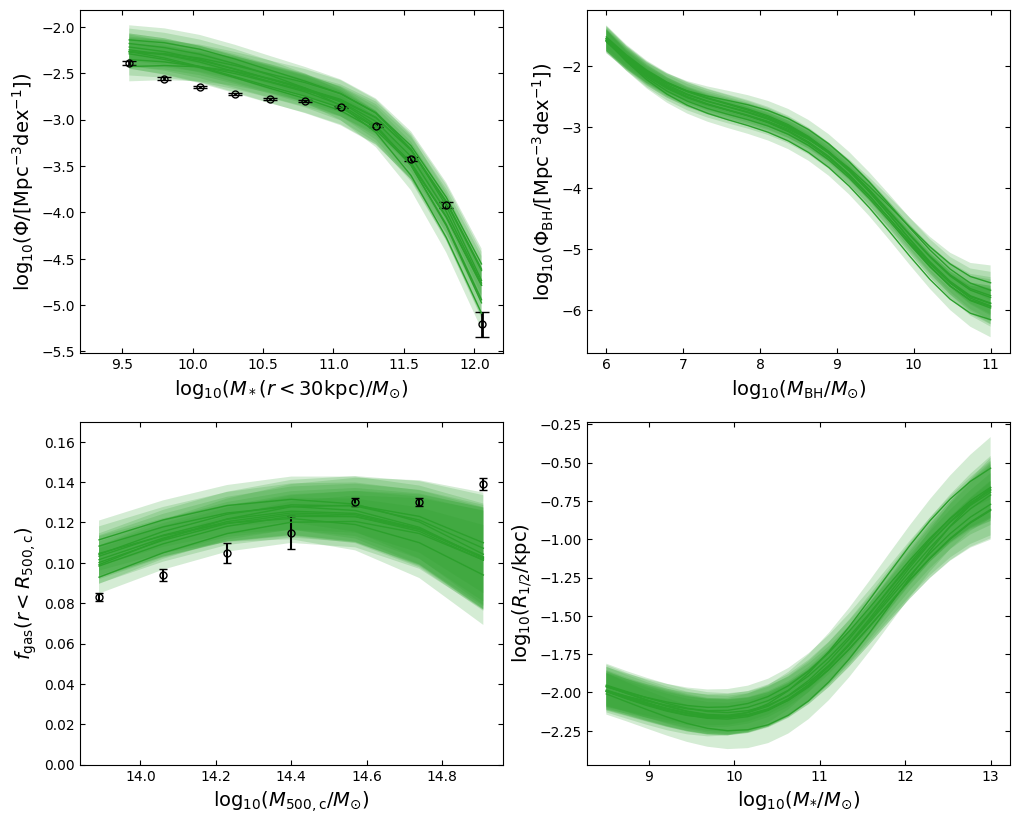

: 

In [ ]:
readers = [reader_joint_kugel]
colors = ['C2']

fig, ax = plt.subplots(2, 2, figsize=(12, 10), dpi=100)

# --- TOP LEFT COLUMN: SMF ---
ax1 = ax[0,0]
ax1.set_xlim(9.2,12.2)
ax1.tick_params(direction='in', top=True, right=True)

ax1.set_xlabel('$\log_{10}(M_*(r<30$kpc$)/M_{\odot})$', fontsize=14)
ax1.set_ylabel('$\log_{10}(\Phi/[$Mpc$^{-3}$dex$^{-1}])$', fontsize=14)

# BOTTOM LEFT COLUMN: Gas Fraction
ax2 = ax[1,0]
# ax2.set_xlim(12, 14.7)
ax2.set_ylim(0.0,0.17)
ax2.tick_params(direction='in', top=True, right=True)

ax2.errorbar(data_dict['mhalo'], data_dict['fgas_obs'], yerr=data_dict['fgas_err'], 
                fmt='ko', markersize=5, fillstyle='none',
                capsize=3, label=data_dict['fgas_label'])

ax2.set_xlabel('$\log_{10}(M_{500,\\mathrm{c}}/M_{\odot})$', fontsize=14)
ax2.set_ylabel('$f_{\\mathrm{gas}}(r<R_{500,\\mathrm{c}})$', fontsize=14)

# TOP RIGHT COLUMN: BHMF
ax3 = ax[0,1]
# ax3.set_xlim(12, 14.7)
# ax3.set_ylim(0.0,0.17)
ax3.tick_params(direction='in', top=True, right=True)

ax3.set_xlabel('$\log_{10}(M_{\\mathrm{BH}}/M_{\odot})$', fontsize=14)
ax3.set_ylabel('$\log_{10}(\\Phi_{\\mathrm{BH}}/[$Mpc$^{-3}$dex$^{-1}])$', fontsize=14)

# BOTTOM RIGHT COLUMN: BHMF
ax4 = ax[1,1]
# ax4.set_xlim(12, 14.7)
# ax4.set_ylim(0.0,0.17)
ax4.tick_params(direction='in', top=True, right=True)

ax4.set_xlabel('$\log_{10}(M_{*}/M_{\odot})$', fontsize=14)
ax4.set_ylabel('$\log_{10}(R_{1/2}/$kpc$)$', fontsize=14)

for i in range(len(readers)):
    some_pars = get_some_samples(readers[i])

    if i==0:
        GAMA_data = model_GAMA(GAMA_corr, some_pars[0][7], some_pars[0][8])

        obs_log_phi = GAMA_data[9:,1]
        obs_uncertainty = GAMA_data[9:,2]
        mstar = GAMA_data[9:,0]
        
        ax1.errorbar(mstar, obs_log_phi, yerr=obs_uncertainty, color='k', marker='o', markersize=5, fillstyle='none',\
            capsize=5, label='Driver et al. (2022)', elinewidth=2, ls='')

    for j in range(10):
        # SMF Predictions
        mu_smf, var_smf = get_gp_prediction(some_pars[j][:7], mstar, models['smf'])
        ax1.fill_between(mstar, mu_smf - np.sqrt(var_smf), mu_smf + np.sqrt(var_smf), color=colors[i], alpha=0.2, edgecolor=None)
        ax1.plot(mstar, mu_smf, colors[i], lw=1)

        # Gas Fraction Predictions
        mu_fgas, var_fgas = get_gp_prediction(some_pars[j][:7], data_dict['mhalo'], models['fgas'])
        ax2.fill_between(data_dict['mhalo'], mu_fgas - np.sqrt(var_fgas), mu_fgas + np.sqrt(var_fgas), 
                                color=colors[i], alpha=0.2, edgecolor=None)
        ax2.plot(data_dict['mhalo'], mu_fgas, colors[i], lw=1)

        # BHMF Predictions
        mbh = np.linspace(6, 11, 20)
        mu_bhmf, var_bhmf = get_gp_prediction(some_pars[j][:7], mbh, models['bhmf'])
        ax3.fill_between(mbh, mu_bhmf - np.sqrt(var_bhmf), mu_bhmf + np.sqrt(var_bhmf), color=colors[i], alpha=0.2, edgecolor=None)
        ax3.plot(mbh, mu_bhmf, colors[i], lw=1)

        # Size-Mass Predictions
        m2half = np.linspace(8.5,13,20)
        mu_rhalf, var_rhalf = get_gp_prediction(some_pars[j][:7], m2half, models['size_mass'])
        ax4.fill_between(m2half, mu_rhalf - np.sqrt(var_rhalf), mu_rhalf + np.sqrt(var_rhalf), color=colors[i], alpha=0.2, edgecolor=None)
        ax4.plot(m2half, mu_rhalf, colors[i], lw=1)

Removed no burn in
Removed no burn in
Removed no burn in


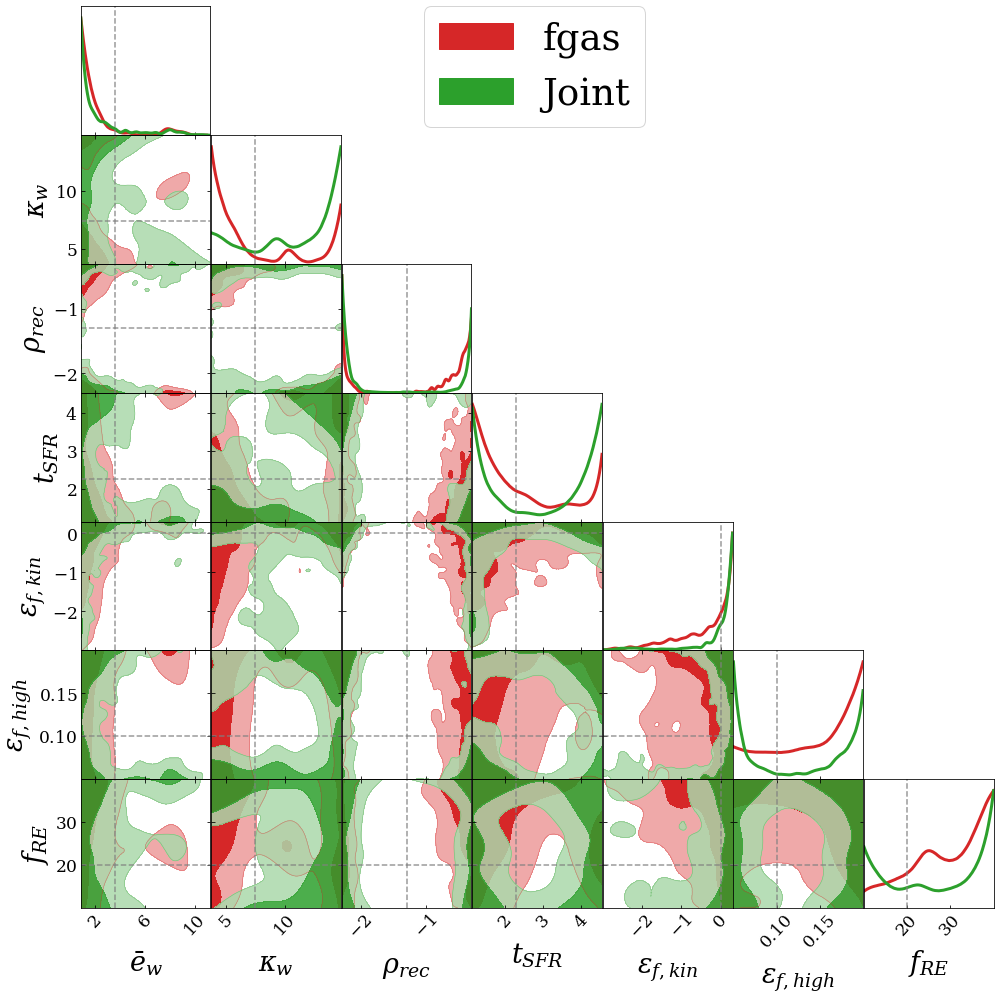

: 

: 

In [ ]:
gd_param_names = ['\\bar{e}_w', '\\kappa_w', '\\rho_{rec}',\
     't_{SFR}', '\\epsilon_{f,kin}', '\\epsilon_{f,high}', 'f_{RE}', 'b_star', 'b_cv']

ranges = {gd_param_names[0]: [0.9, 14.4],
        gd_param_names[1]: [3.7, 14.8],
        gd_param_names[2]: [np.log10(0.005),np.log10(0.5)],
        gd_param_names[3]: [1.135, 4.54],
        gd_param_names[4]: [np.log10(0.001), np.log10(2)],
        gd_param_names[5]: [0.05, 0.2],
        gd_param_names[6]: [10, 40]}

mcsam_smf = MCSamples(
    samples=samples_smf[:,:7],
    loglikes=-log_prob_smf,
    names=gd_param_names[:7],
    labels=gd_param_names[:7],
    ranges=ranges
    )

mcsam_fgas = MCSamples(
    samples=samples_fgas[:,:7],
    loglikes=-log_prob_fgas,
    names=gd_param_names[:7],
    labels=gd_param_names[:7],
    ranges=ranges
    )

mcsam_joint = MCSamples(
    samples=samples_joint[:,:7],
    loglikes=-log_prob_joint,
    names=gd_param_names[:7],
    labels=gd_param_names[:7],
    ranges=ranges
    )

# Triangle plot (sometimes also called a corner plot)
g = plots.get_subplot_plotter()

g.settings.axes_fontsize = 20
g.settings.lab_fontsize = 30
g.settings.x_label_rotation=47
g.settings.legend_fontsize = 40

g.settings.title_limit_fontsize = 22
g.triangle_plot([mcsam_fgas, mcsam_joint],
                legend_labels=['fgas', 'Joint'], contour_colors=['C3', 'C2'], line_args=[\
                {'lw':3, 'color':'C3'},{'lw':3, 'color':'C2'}], filled=True)

# g.triangle_plot([mcsam_smf],
#                 legend_labels=['SMF'], contour_colors=['C0'], line_args=[{'lw':3, 'color':'C0'}], filled=True)


truths = np.asarray([wind_en_or[30], wind_vel_or[30], rho_rec_or[30], 1000*sf_ts_or[30], ef_kin_or[30], ef_high_or[30], f_re_or[30]])

for i in range(7):
    for ax in g.subplots[i:, i]:
        ax.axvline(truths[i], color="gray", ls="--", alpha=0.8)

for i in range(6):
    for ax in g.subplots[i+1, :i+1]:
        ax.axhline(truths[i+1], color="gray", ls="--", alpha=0.8)

### And the original emulators in extended space

In [ ]:
reader_joint_ext = emcee.backends.HDFBackend('/cosmos_storage/home/fgmaion/MTNG-resims/mcmc_chains/joint_extended_chain.h5')
samples_joint_ext, log_prob_joint_ext = get_samples(reader_joint_ext)

: 

In [ ]:
bf_joint_ext = samples_joint_ext[np.argmax(log_prob_joint_ext)]

: 

Removed no burn in


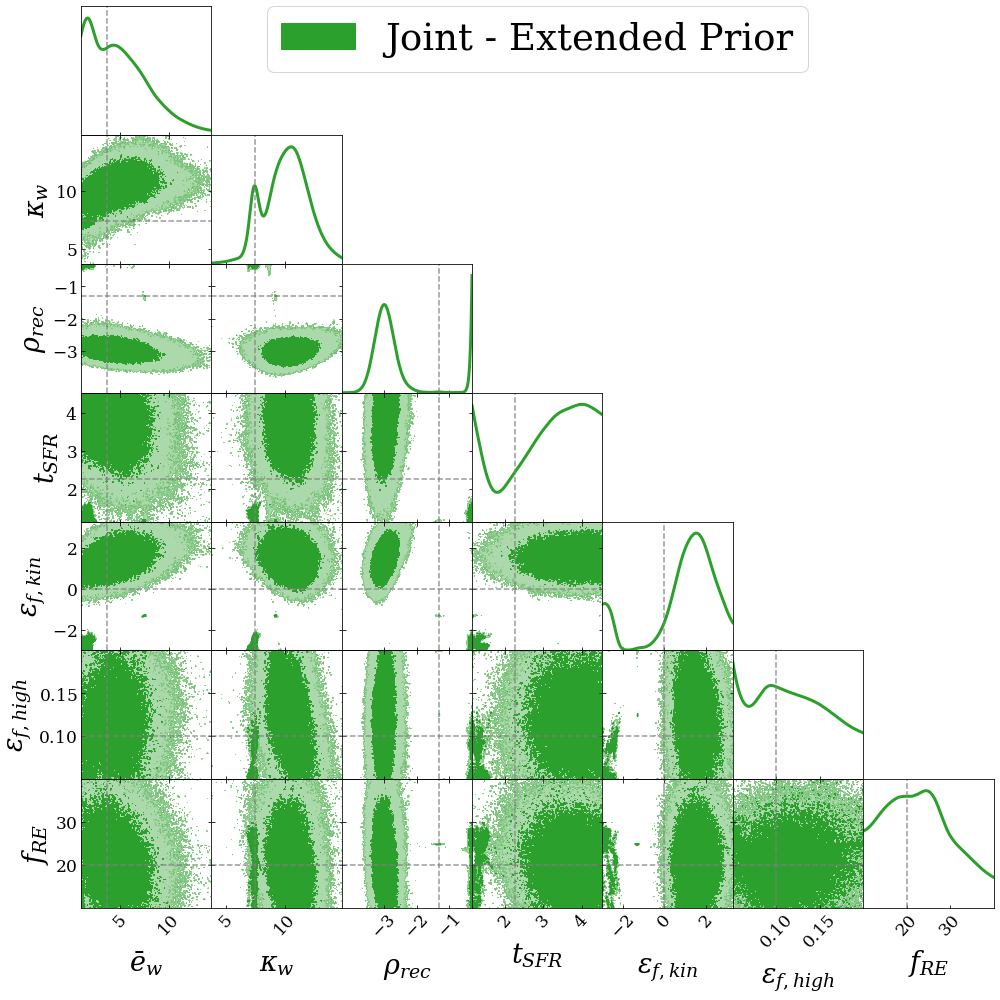

: 

In [ ]:
gd_param_names = ['\\bar{e}_w', '\\kappa_w', '\\rho_{rec}',\
     't_{SFR}', '\\epsilon_{f,kin}', '\\epsilon_{f,high}', 'f_{RE}', 'b_star', 'b_cv']

ranges = {gd_param_names[0]: [0.9, 14.4],
        gd_param_names[1]: [3.7, 14.8],
        gd_param_names[2]: [np.log10(0.005/100),np.log10(0.5)],
        gd_param_names[3]: [1.135, 4.54],
        gd_param_names[4]: [np.log10(0.001), np.log10(2*1000)],
        gd_param_names[5]: [0.05, 0.2],
        gd_param_names[6]: [10, 40]}

mcsam_joint = MCSamples(
    samples=samples_joint_ext[:,:7],
    loglikes=-log_prob_joint_ext,
    names=gd_param_names[:7],
    labels=gd_param_names[:7],
    ranges=ranges
    )

# Triangle plot (sometimes also called a corner plot)
g = plots.get_subplot_plotter()

g.settings.axes_fontsize = 20
g.settings.lab_fontsize = 30
g.settings.x_label_rotation=47
g.settings.legend_fontsize = 40

g.settings.title_limit_fontsize = 22
g.triangle_plot([mcsam_joint],
                legend_labels=['Joint - Extended Prior'], contour_colors=['C2'], line_args={'lw':3, 'color':'C2'}, filled=True)

truths = np.asarray([wind_en_or[30], wind_vel_or[30], rho_rec_or[30], 1000*sf_ts_or[30], ef_kin_or[30], ef_high_or[30], f_re_or[30]])

for i in range(7):
    for ax in g.subplots[i:, i]:
        ax.axvline(truths[i], color="gray", ls="--", alpha=0.8)

for i in range(6):
    for ax in g.subplots[i+1, :i+1]:
        ax.axhline(truths[i+1], color="gray", ls="--", alpha=0.8)

### Now let's look at the emulators adding the best-fit simulation

In [ ]:
model_smf_BF = torch.load("/cosmos_storage/home/fgmaion/MTNG-resims/gp_train_results/full_model_smf_bf.pth")
likelihood_smf_BF = torch.load("/cosmos_storage/home/fgmaion/MTNG-resims/gp_train_results/full_likelihood_smf_bf.pth")

model_smf_BF.eval()
likelihood_smf_BF.eval()

model_fgas_BF = torch.load("/cosmos_storage/home/fgmaion/MTNG-resims/gp_train_results/full_model_fgas_bf.pth")
likelihood_fgas_BF = torch.load("/cosmos_storage/home/fgmaion/MTNG-resims/gp_train_results/full_likelihood_fgas_bf.pth")

model_fgas_BF.eval()
likelihood_fgas_BF.eval()

/tmp/ipykernel_70736/1140827740.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_smf_BF = torch.load("/cosmos_storage/home/fgmaion/MTNG-resims/gp_train_results/full

GaussianLikelihood(
  (noise_covar): HomoskedasticNoise(
    (raw_noise_constraint): GreaterThan(1.000E-06)
  )
)

: 

In [ ]:
reader_joint_BF = emcee.backends.HDFBackend('/cosmos_storage/home/fgmaion/MTNG-resims/mcmc_chains/joint-BF_extended_chain.h5')

: 

In [ ]:
samples_joint_BF, log_prob_joint_BF = get_samples(reader_joint_BF)

: 

In [ ]:
bf_joint_BF = samples_joint_BF[np.argmax(log_prob_joint_BF)]

: 

Removed no burn in


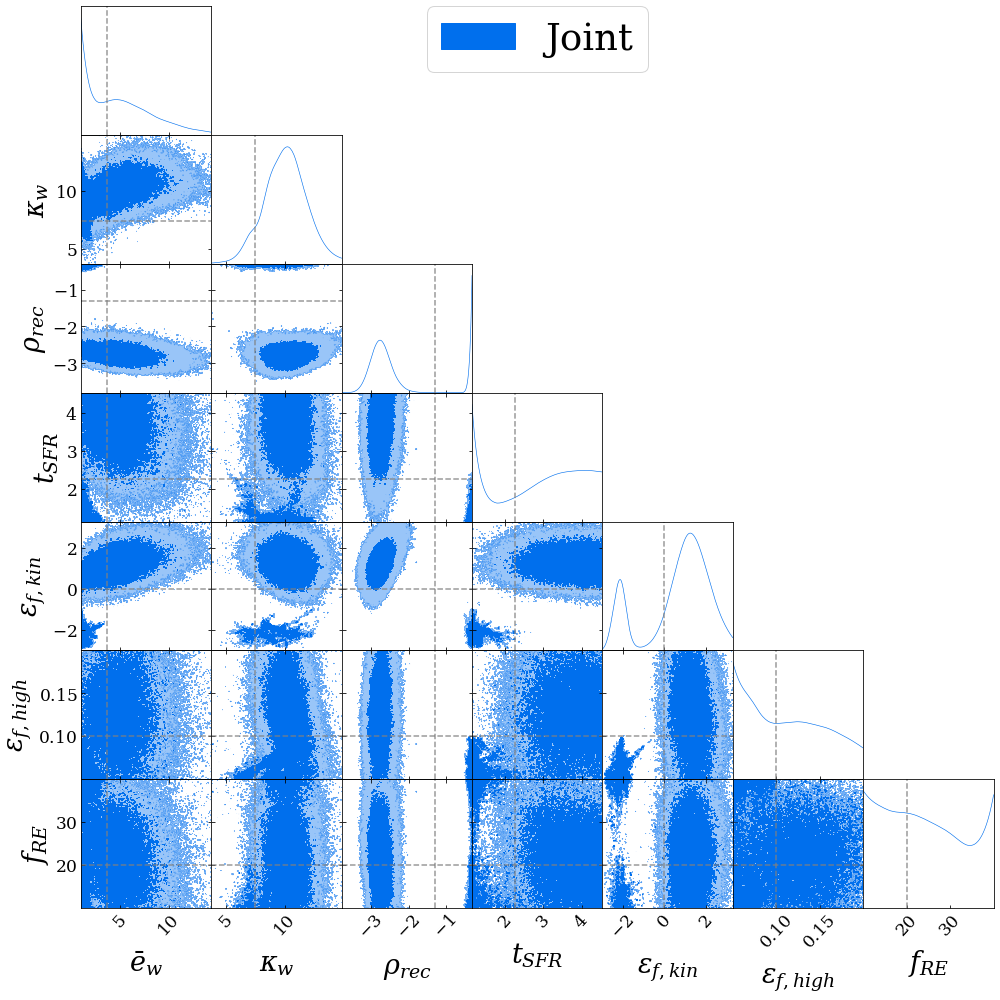

: 

In [ ]:
gd_param_names = ['\\bar{e}_w', '\\kappa_w', '\\rho_{rec}',\
     't_{SFR}', '\\epsilon_{f,kin}', '\\epsilon_{f,high}', 'f_{RE}', 'b_star', 'b_cv']

ranges = {gd_param_names[0]: [0.9, 14.4],
        gd_param_names[1]: [3.7, 14.8],
        gd_param_names[2]: [np.log10(0.005/100),np.log10(0.5)],
        gd_param_names[3]: [1.135, 4.54],
        gd_param_names[4]: [np.log10(0.001), np.log10(2*1000)],
        gd_param_names[5]: [0.05, 0.2],
        gd_param_names[6]: [10, 40]}

mcsam_joint_BF = MCSamples(
    samples=samples_joint_BF[:,:7],
    loglikes=-log_prob_joint_BF,
    names=gd_param_names[:7],
    labels=gd_param_names[:7],
    ranges=ranges
    )

# Triangle plot (sometimes also called a corner plot)
g = plots.get_subplot_plotter()

g.settings.axes_fontsize = 20
g.settings.lab_fontsize = 30
g.settings.x_label_rotation=47
g.settings.legend_fontsize = 40

g.settings.title_limit_fontsize = 22
g.triangle_plot([mcsam_joint_BF],
                legend_labels=['Joint'], filled=True)

truths = np.asarray([wind_en_or[30], wind_vel_or[30], rho_rec_or[30], 1000*sf_ts_or[30], ef_kin_or[30], ef_high_or[30], f_re_or[30]])

for i in range(7):
    for ax in g.subplots[i:, i]:
        ax.axvline(truths[i], color="gray", ls="--", alpha=0.8)

for i in range(6):
    for ax in g.subplots[i+1, :i+1]:
        ax.axhline(truths[i+1], color="gray", ls="--", alpha=0.8)

In [ ]:
import emcee
reader_fgas = emcee.backends.HDFBackend('/cosmos_storage/home/fgmaion/MTNG-resims/mcmc_chains/fgas_regular_kugel_chain.h5')
reader_joint = emcee.backends.HDFBackend('/cosmos_storage/home/fgmaion/MTNG-resims/mcmc_chains/joint_regular_kugel_chain.h5')

samples_fgas, log_prob_fgas = get_samples(reader_fgas)
samples_joint, log_prob_joint = get_samples(reader_joint)

[510.19062118 433.7836025  484.57871723 475.71443056 695.14268305
 416.95103609 395.85070212 344.8476761  372.77722578]
[2262.51153372 4850.22609799 4845.77716977 2870.34105462 4631.50194183
 1440.58490192 2068.31156239 1695.30600435  996.53575276]


: 

Removed no burn in
Removed no burn in


NameError: name 'wind_en_or' is not defined

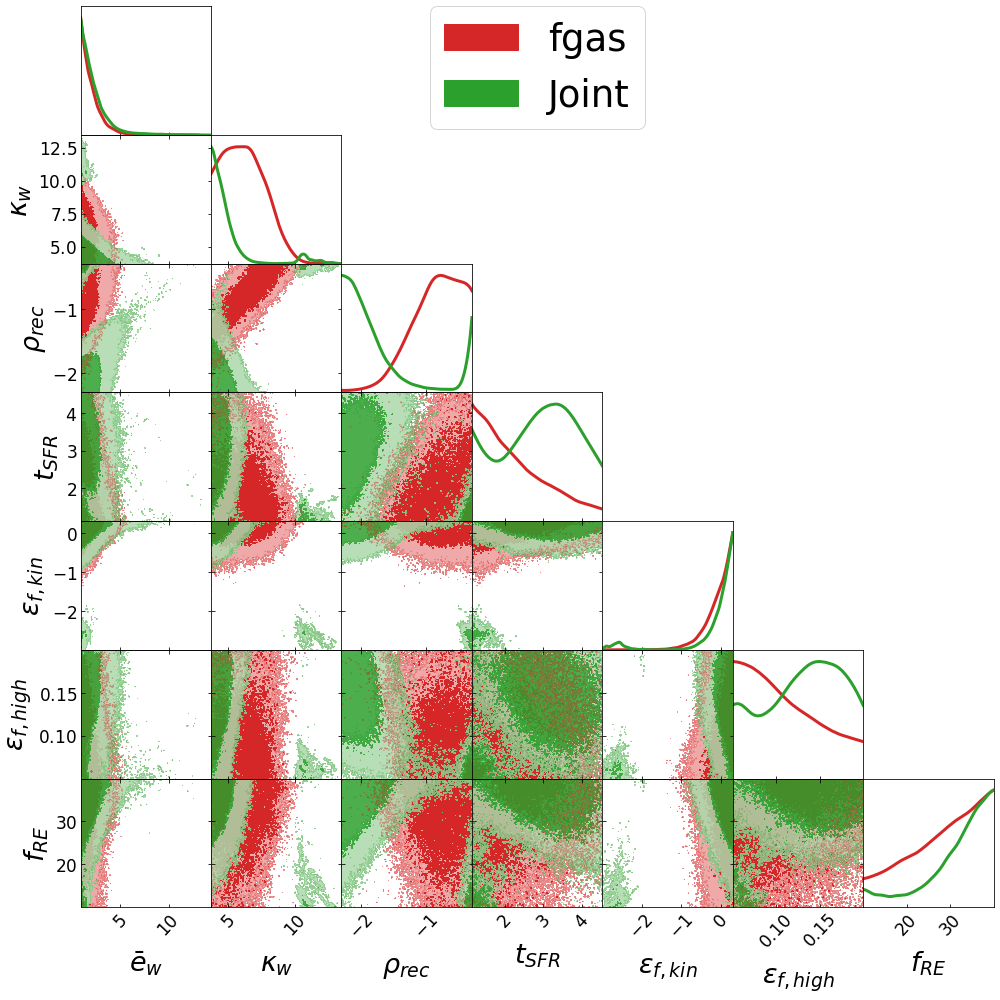

: 

In [ ]:
gd_param_names = ['\\bar{e}_w', '\\kappa_w', '\\rho_{rec}',\
     't_{SFR}', '\\epsilon_{f,kin}', '\\epsilon_{f,high}', 'f_{RE}', 'b_star', 'b_cv']

ranges = {gd_param_names[0]: [0.9, 14.4],
        gd_param_names[1]: [3.7, 14.8],
        gd_param_names[2]: [np.log10(0.005),np.log10(0.5)],
        gd_param_names[3]: [1.135, 4.54],
        gd_param_names[4]: [np.log10(0.001), np.log10(2)],
        gd_param_names[5]: [0.05, 0.2],
        gd_param_names[6]: [10, 40]}

mcsam_fgas = MCSamples(
    samples=samples_fgas[:,:7],
    loglikes=-log_prob_fgas,
    names=gd_param_names[:7],
    labels=gd_param_names[:7],
    ranges=ranges
    )

mcsam_joint = MCSamples(
    samples=samples_joint[:,:7],
    loglikes=-log_prob_joint,
    names=gd_param_names[:7],
    labels=gd_param_names[:7],
    ranges=ranges
    )

# Triangle plot (sometimes also called a corner plot)
g = plots.get_subplot_plotter()

g.settings.axes_fontsize = 20
g.settings.lab_fontsize = 30
g.settings.x_label_rotation=47
g.settings.legend_fontsize = 40

g.settings.title_limit_fontsize = 22
g.triangle_plot([mcsam_fgas, mcsam_joint],
                legend_labels=['fgas', 'Joint'], contour_colors=['C3', 'C2'], line_args=[\
                {'lw':3, 'color':'C3'},{'lw':3, 'color':'C2'}], filled=True)

# g.triangle_plot([mcsam_smf],
#                 legend_labels=['SMF'], contour_colors=['C0'], line_args=[{'lw':3, 'color':'C0'}], filled=True)


truths = np.asarray([wind_en_or[30], wind_vel_or[30], rho_rec_or[30], 1000*sf_ts_or[30], ef_kin_or[30], ef_high_or[30], f_re_or[30]])

for i in range(7):
    for ax in g.subplots[i:, i]:
        ax.axvline(truths[i], color="gray", ls="--", alpha=0.8)

for i in range(6):
    for ax in g.subplots[i+1, :i+1]:
        ax.axhline(truths[i+1], color="gray", ls="--", alpha=0.8)

In [ ]:
# Assuming 'prepare_theta', 'mass_bins', 'means', and 'stds' are defined in the global scope 
# as in the previous, corrected response.

def get_gp_prediction(theta_original, mstar, gp_model):
    """
    Takes a set of 7 parameters (in original physical units) and returns 
    the predicted GP mean and variance for the full SMF curve (across all mstar bins).
    """
    
    # 1. Standardize theta (using the globally defined prepare_theta function)
    theta_standardized = prepare_theta(theta_original)
    
    # 2. Construct 8D input vector (mstar and standardized theta)
    N_mass_bins = len(mstar)
    theta_vector = np.repeat(theta_standardized[np.newaxis, :], N_mass_bins, axis=0)
    
    # Full 8D input: [log10(M*), theta_1_std, ..., theta_7_std]
    gp_input = np.hstack([
        mstar[:, np.newaxis], # (N_mass_bins, 1)
        theta_vector          # (N_mass_bins, 7)
    ]) 

    # 3. Predict with gpytorch
    x_star = torch.from_numpy(gp_input).float() 
    
    with torch.no_grad(), gpytorch.settings.fast_pred_var():
        predictive_dist = gp_model(x_star) 
        
    mu_pred = predictive_dist.mean.numpy()         # Predicted mean SMF curve
    var_emulator = predictive_dist.variance.numpy() # GP intrinsic variance
    
    return mu_pred, var_emulator

: 

In [ ]:
def prepare_theta(theta):

    theta_std = np.copy(theta)

    theta_std[0]  = (theta_std[0] - np.mean(wind_en_or)) / np.std(wind_en_or)
    theta_std[1]  = (theta_std[1] - np.mean(wind_vel_or)) / np.std(wind_vel_or)
    theta_std[2]  = (theta_std[2] - np.mean(rho_rec_or)) / np.std(rho_rec_or)
    theta_std[3]  = (theta_std[3] - np.mean(sf_ts_or)) / np.std(sf_ts_or)
    theta_std[4]  = (theta_std[4] - np.mean(ef_kin_or)) / np.std(ef_kin_or)
    theta_std[5]  = (theta_std[5] - np.mean(ef_high_or)) / np.std(ef_high_or)
    theta_std[6]  = (theta_std[6] - np.mean(f_re_or)) / np.std(f_re_or)

    return theta_std

: 

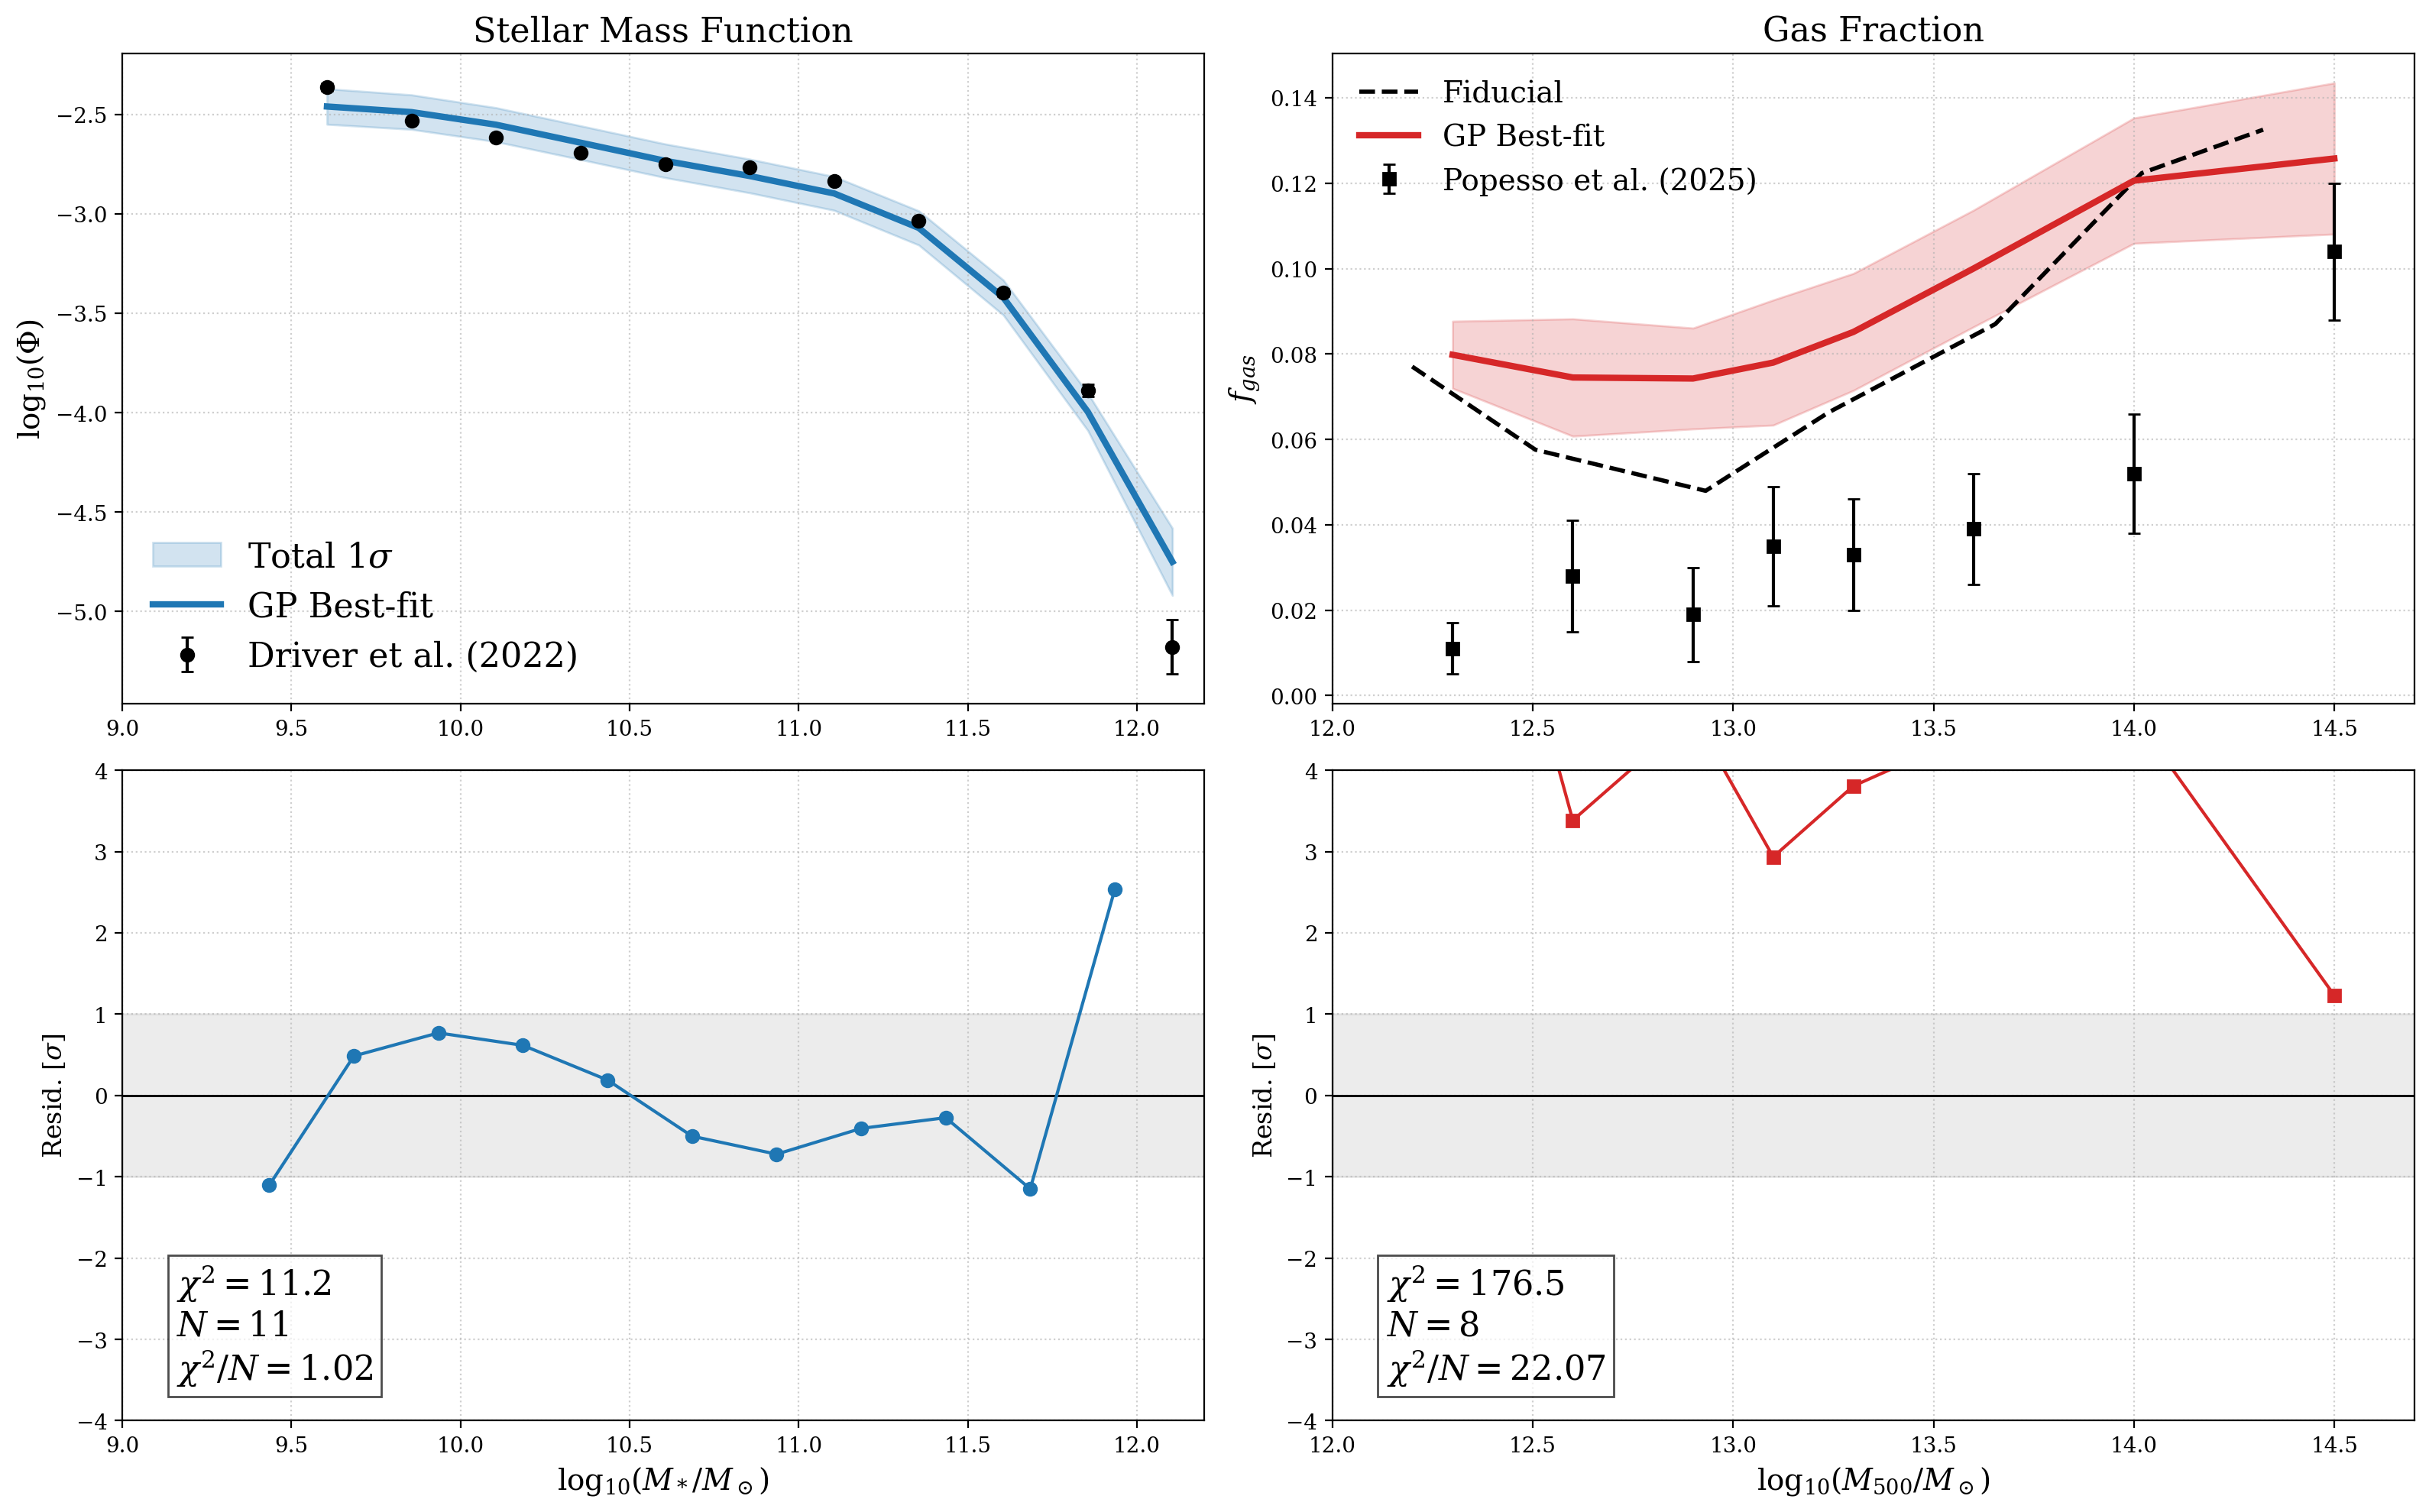

: 

In [ ]:
bf_theta = np.copy(bf_smf)
bf_theta[3] /= 1000  # Convert back to original units for sf_ts

GAMA_data = model_GAMA(GAMA_corr, bf_theta[7], bf_theta[8])

obs_log_phi = GAMA_data[9:,1]
obs_uncertainty = GAMA_data[9:,2]
mstar = GAMA_data[9:,0]

# SMF Predictions & Chi2
mu_smf, var_smf = get_gp_prediction(bf_theta[:7], mstar, model_smf)
std_tot_smf = np.sqrt(var_smf + obs_uncertainty**2)
resid_smf = (mu_smf - obs_log_phi) / std_tot_smf
chi2_smf = np.sum(resid_smf**2)
n_smf = len(resid_smf)

# Gas Fraction Predictions & Chi2
mu_fgas, var_fgas = get_gp_prediction(bf_theta[:7], data_dict['mhalo'], model_fgas)
std_tot_fgas = np.sqrt(var_fgas + data_dict['fgas_err']**2)
resid_fgas = (mu_fgas - data_dict['fgas_obs']) / std_tot_fgas
chi2_fgas = np.sum(resid_fgas**2)
n_fgas = len(resid_fgas)

# 2. Setup Figure
fig, axes = plt.subplots(2, 2, figsize=(16, 10), dpi=200)

# --- LEFT COLUMN: SMF ---
ax_m1 = axes[0, 0]
ax_m1.set_xlim(9,12.2)
# ax_m1.plot(fiducial_dict['smf_mstar'], fiducial_dict['smf_phi'], 
#                 'k--', lw=2, label='Fiducial')
ax_m1.fill_between(mstar, mu_smf - std_tot_smf, mu_smf + std_tot_smf, 
                        color='C0', alpha=0.2, label='Total $1\sigma$')
ax_m1.plot(mstar, mu_smf, 'C0-', lw=3, label='GP Best-fit')
ax_m1.errorbar(mstar, obs_log_phi, yerr=obs_uncertainty, 
                    fmt='ko', capsize=3, label='Driver et al. (2022)')

# Stats Text Box
stats_smf = f"$\chi^2 = {chi2_smf:.1f}$\n$N = {n_smf}$\n$\chi^2/N = {chi2_smf/n_smf:.2f}$"

ax_m1.set_ylabel(r'$\log_{10}(\Phi)$', fontsize=14)
ax_m1.set_title('Stellar Mass Function', fontsize=16)
ax_m1.legend(loc='lower left', frameon=False, fontsize=16)

# Residuals
ax_r1 = axes[1, 0]
ax_r1.set_xlim(9,12.2)
ax_r1.text(0.05, 0.05, stats_smf, fontsize=16, transform=ax_r1.transAxes, bbox=dict(facecolor='white', alpha=0.7), verticalalignment='bottom')
ax_r1.axhline(0, color='black', lw=1)
ax_r1.axhspan(-1, 1, color='gray', alpha=0.15)
ax_r1.plot(data_dict['mstar'], resid_smf, 'o-', color='C0')
ax_r1.set_ylabel(r'Resid. [$\sigma$]', fontsize=12)
ax_r1.set_xlabel(r'$\log_{10}(M_* / M_\odot)$', fontsize=14)
ax_r1.set_ylim(-4, 4)

# --- RIGHT COLUMN: Gas Fraction ---
ax_m2 = axes[0, 1]
ax_m2.set_xlim(12, 14.7)
ax_m2.plot(fiducial_dict['fgas_mhalo'], fiducial_dict['fgas_val'], 
                'k--', lw=2, label='Fiducial')
ax_m2.fill_between(data_dict['mhalo'], mu_fgas - std_tot_fgas, mu_fgas + std_tot_fgas, 
                        color='C3', alpha=0.2)
ax_m2.plot(data_dict['mhalo'], mu_fgas, 'C3-', lw=3, label='GP Best-fit')
ax_m2.errorbar(data_dict['mhalo'], data_dict['fgas_obs'], yerr=data_dict['fgas_err'], 
                    fmt='ks', capsize=3, label='Popesso et al. (2025)')

# Stats Text Box
stats_fgas = f"$\chi^2 = {chi2_fgas:.1f}$\n$N = {n_fgas}$\n$\chi^2/N = {chi2_fgas/n_fgas:.2f}$"

ax_m2.set_ylabel(r'$f_{gas}$', fontsize=14)
ax_m2.set_title('Gas Fraction', fontsize=16)
ax_m2.legend(loc='upper left', frameon=False, fontsize=14)

# Residuals
ax_r2 = axes[1, 1]
ax_r2.set_xlim(12, 14.7)
ax_r2.text(0.05, 0.05, stats_fgas, fontsize=16, transform=ax_r2.transAxes, bbox=dict(facecolor='white', alpha=0.7), verticalalignment='bottom')
ax_r2.axhline(0, color='black', lw=1)
ax_r2.axhspan(-1, 1, color='gray', alpha=0.15)
ax_r2.plot(data_dict['mhalo'], resid_fgas, 's-', color='C3')
ax_r2.set_ylabel(r'Resid. [$\sigma$]', fontsize=12)
ax_r2.set_xlabel(r'$\log_{10}(M_{500} / M_\odot)$', fontsize=14)
ax_r2.set_ylim(-4, 4)

for ax in axes.flatten(): ax.grid(True, ls=':', alpha=0.6)
plt.tight_layout()
plt.show()

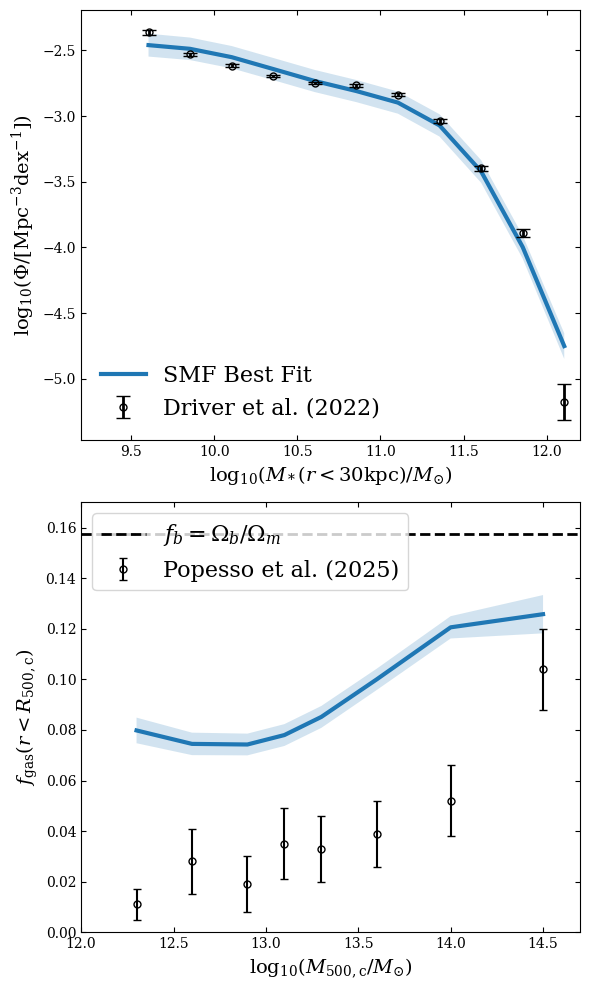

: 

In [ ]:
bf_theta = np.copy(bf_smf)
bf_theta[3] /= 1000  # Convert back to original units for sf_ts

bf_theta_2 = np.copy(bf_fgas)
bf_theta_2[3] /= 1000  # Convert back to original units for sf_ts

bf_theta_3 = np.copy(bf_joint)
bf_theta_3[3] /= 1000  # Convert back to original units for sf_ts

bf_theta_4 = np.copy(bf_joint_BF)
bf_theta_4[3] /= 1000  # Convert back to original units for sf_ts

GAMA_data = model_GAMA(GAMA_corr, bf_theta[7], bf_theta[8])

obs_log_phi = GAMA_data[9:,1]
obs_uncertainty = GAMA_data[9:,2]
mstar = GAMA_data[9:,0]

# SMF Predictions
mu_smf, var_smf = get_gp_prediction(bf_theta[:7], mstar, model_smf)
mu_smf_2, var_smf_2 = get_gp_prediction(bf_theta_2[:7], mstar, model_smf)
mu_smf_3, var_smf_3 = get_gp_prediction(bf_theta_3[:7], mstar, model_smf)
mu_smf_4, var_smf_4 = get_gp_prediction(bf_theta_4[:7], mstar, model_smf_BF)

# Gas Fraction Predictions
mu_fgas, var_fgas = get_gp_prediction(bf_theta[:7], data_dict['mhalo'], model_fgas)
mu_fgas_2, var_fgas_2 = get_gp_prediction(bf_theta_2[:7], data_dict['mhalo'], model_fgas)
mu_fgas_3, var_fgas_3 = get_gp_prediction(bf_theta_3[:7], data_dict['mhalo'], model_fgas)
mu_fgas_4, var_fgas_4 = get_gp_prediction(bf_theta_4[:7], data_dict['mhalo'], model_fgas_BF)

fig, ax = plt.subplots(2, 1, figsize=(6, 10), dpi=100)

# --- LEFT COLUMN: SMF ---
ax1 = ax[0]
ax1.set_xlim(9.2,12.2)
ax1.tick_params(direction='in', top=True, right=True)

ax1.fill_between(mstar, mu_smf - np.sqrt(var_smf), mu_smf + np.sqrt(var_smf), color='C0', alpha=0.2, edgecolor=None)
ax1.plot(mstar, mu_smf, 'C0-', lw=3, label='SMF Best Fit')

# ax1.fill_between(mstar, mu_smf_2 - np.sqrt(var_smf_2), mu_smf_2 + np.sqrt(var_smf_2), color='C3', alpha=0.2, edgecolor=None)
# ax1.plot(mstar, mu_smf_2, 'C3-', lw=3, label='$f_{gas}$ Best Fit')

# ax1.fill_between(mstar, mu_smf_3 - np.sqrt(var_smf_3), mu_smf_3 + np.sqrt(var_smf_3), color='C2', alpha=0.2, edgecolor=None)
# ax1.plot(mstar, mu_smf_3, 'C2-', lw=3, label='Joint Best Fit')

# ax1.fill_between(mstar, mu_smf_4 - np.sqrt(var_smf_4), mu_smf_4 + np.sqrt(var_smf_4), color='C2', alpha=0.2, edgecolor=None)
# ax1.plot(mstar, mu_smf_4, 'C2', ls='--', lw=3, label='Joint + New Simulation')

ax1.errorbar(mstar, obs_log_phi, yerr=obs_uncertainty, color='k', marker='o', markersize=5, fillstyle='none',\
    capsize=5, label='Driver et al. (2022)', elinewidth=2, ls='')

ax1.set_xlabel('$\log_{10}(M_*(r<30$kpc$)/M_{\odot})$', fontsize=14)
ax1.set_ylabel('$\log_{10}(\Phi/[$Mpc$^{-3}$dex$^{-1}])$', fontsize=14)
ax1.legend(loc='lower left', frameon=False, fontsize=16)

# Bottom Column: Gas Fraction
ax2 = ax[1]
ax2.set_xlim(12, 14.7)
ax2.set_ylim(0.0,0.17)
ax2.tick_params(direction='in', top=True, right=True)

ax2.fill_between(data_dict['mhalo'], mu_fgas - np.sqrt(var_fgas), mu_fgas + np.sqrt(var_fgas), 
                        color='C0', alpha=0.2, edgecolor=None)
ax2.plot(data_dict['mhalo'], mu_fgas, 'C0-', lw=3)

# ax2.fill_between(data_dict['mhalo'], mu_fgas_2 - np.sqrt(var_fgas_2), mu_fgas_2 + np.sqrt(var_fgas_2), 
#                         color='C3', alpha=0.2, edgecolor=None)
# ax2.plot(data_dict['mhalo'], mu_fgas_2, 'C3-', lw=3)

# ax2.fill_between(data_dict['mhalo'], mu_fgas_3 - np.sqrt(var_fgas_3), mu_fgas_3 + np.sqrt(var_fgas_3), 
#                         color='C2', alpha=0.2, edgecolor=None)
# ax2.plot(data_dict['mhalo'], mu_fgas_3, 'C2-', lw=3)

# ax2.fill_between(data_dict['mhalo'], mu_fgas_4 - np.sqrt(var_fgas_4), mu_fgas_4 + np.sqrt(var_fgas_4), 
#                         color='C2', alpha=0.2, edgecolor=None)
# ax2.plot(data_dict['mhalo'], mu_fgas_4, 'C2', ls='--', lw=3)

ax2.errorbar(data_dict['mhalo'], data_dict['fgas_obs'], yerr=data_dict['fgas_err'], 
                    fmt='ko', markersize=5, fillstyle='none',
                    capsize=3, label='Popesso et al. (2025)')
ax2.axhline(0.15733247005503398, color='k', ls='--', lw=2, label='$f_b=\Omega_b/\Omega_m$')

ax2.set_xlabel('$\log_{10}(M_{500,\\mathrm{c}}/M_{\odot})$', fontsize=14)
ax2.set_ylabel('$f_{\\mathrm{gas}}(r<R_{500,\\mathrm{c}})$', fontsize=14)
ax2.legend(loc='upper left', frameon=True, fontsize=16)

plt.tight_layout()
# plt.savefig("/cosmos_storage/home/fgmaion/MTNG-resims/results/fits/fit_comparison_original_LH.pdf", dpi=200)

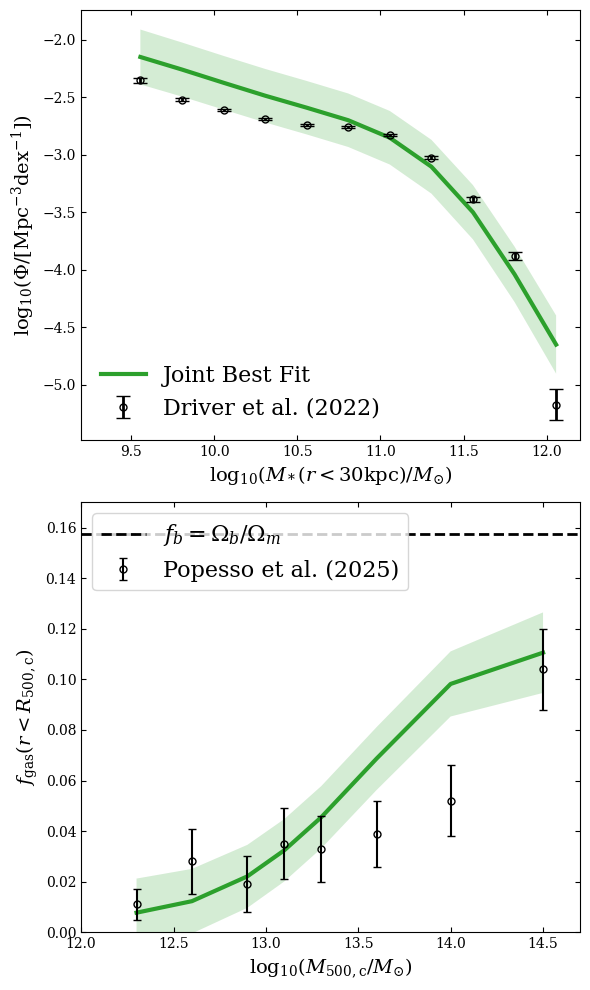

: 

In [ ]:
bf_theta = np.copy(bf_joint_ext)
bf_theta[3] /= 1000  # Convert back to original units for sf_ts

GAMA_data = model_GAMA(GAMA_corr, bf_theta[7], bf_theta[8])

obs_log_phi = GAMA_data[9:,1]
obs_uncertainty = GAMA_data[9:,2]
mstar = GAMA_data[9:,0]

# SMF Predictions
mu_smf, var_smf = get_gp_prediction(bf_theta[:7], mstar, model_smf)

# Gas Fraction Predictions
mu_fgas, var_fgas = get_gp_prediction(bf_theta[:7], data_dict['mhalo'], model_fgas)

fig, ax = plt.subplots(2, 1, figsize=(6, 10), dpi=100)

# --- LEFT COLUMN: SMF ---
ax1 = ax[0]
ax1.set_xlim(9.2,12.2)
ax1.tick_params(direction='in', top=True, right=True)

ax1.fill_between(mstar, mu_smf - np.sqrt(var_smf), mu_smf + np.sqrt(var_smf), color='C2', alpha=0.2, edgecolor=None)
ax1.plot(mstar, mu_smf, 'C2-', lw=3, label='Joint Best Fit')

ax1.errorbar(mstar, obs_log_phi, yerr=obs_uncertainty, color='k', marker='o', markersize=5, fillstyle='none',\
    capsize=5, label='Driver et al. (2022)', elinewidth=2, ls='')

ax1.set_xlabel('$\log_{10}(M_*(r<30$kpc$)/M_{\odot})$', fontsize=14)
ax1.set_ylabel('$\log_{10}(\Phi/[$Mpc$^{-3}$dex$^{-1}])$', fontsize=14)
ax1.legend(loc='lower left', frameon=False, fontsize=16)

# Bottom Column: Gas Fraction
ax2 = ax[1]
ax2.set_xlim(12, 14.7)
ax2.set_ylim(0.0,0.17)
ax2.tick_params(direction='in', top=True, right=True)

ax2.fill_between(data_dict['mhalo'], mu_fgas - np.sqrt(var_fgas), mu_fgas + np.sqrt(var_fgas), 
                        color='C2', alpha=0.2, edgecolor=None)
ax2.plot(data_dict['mhalo'], mu_fgas, 'C2-', lw=3)

ax2.errorbar(data_dict['mhalo'], data_dict['fgas_obs'], yerr=data_dict['fgas_err'], 
                    fmt='ko', markersize=5, fillstyle='none',
                    capsize=3, label='Popesso et al. (2025)')
ax2.axhline(0.15733247005503398, color='k', ls='--', lw=2, label='$f_b=\Omega_b/\Omega_m$')

ax2.set_xlabel('$\log_{10}(M_{500,\\mathrm{c}}/M_{\odot})$', fontsize=14)
ax2.set_ylabel('$f_{\\mathrm{gas}}(r<R_{500,\\mathrm{c}})$', fontsize=14)
ax2.legend(loc='upper left', frameon=True, fontsize=16)

plt.tight_layout()
# plt.savefig("/cosmos_storage/home/fgmaion/MTNG-resims/results/fits/fit_comparison_original_LH.pdf", dpi=200)

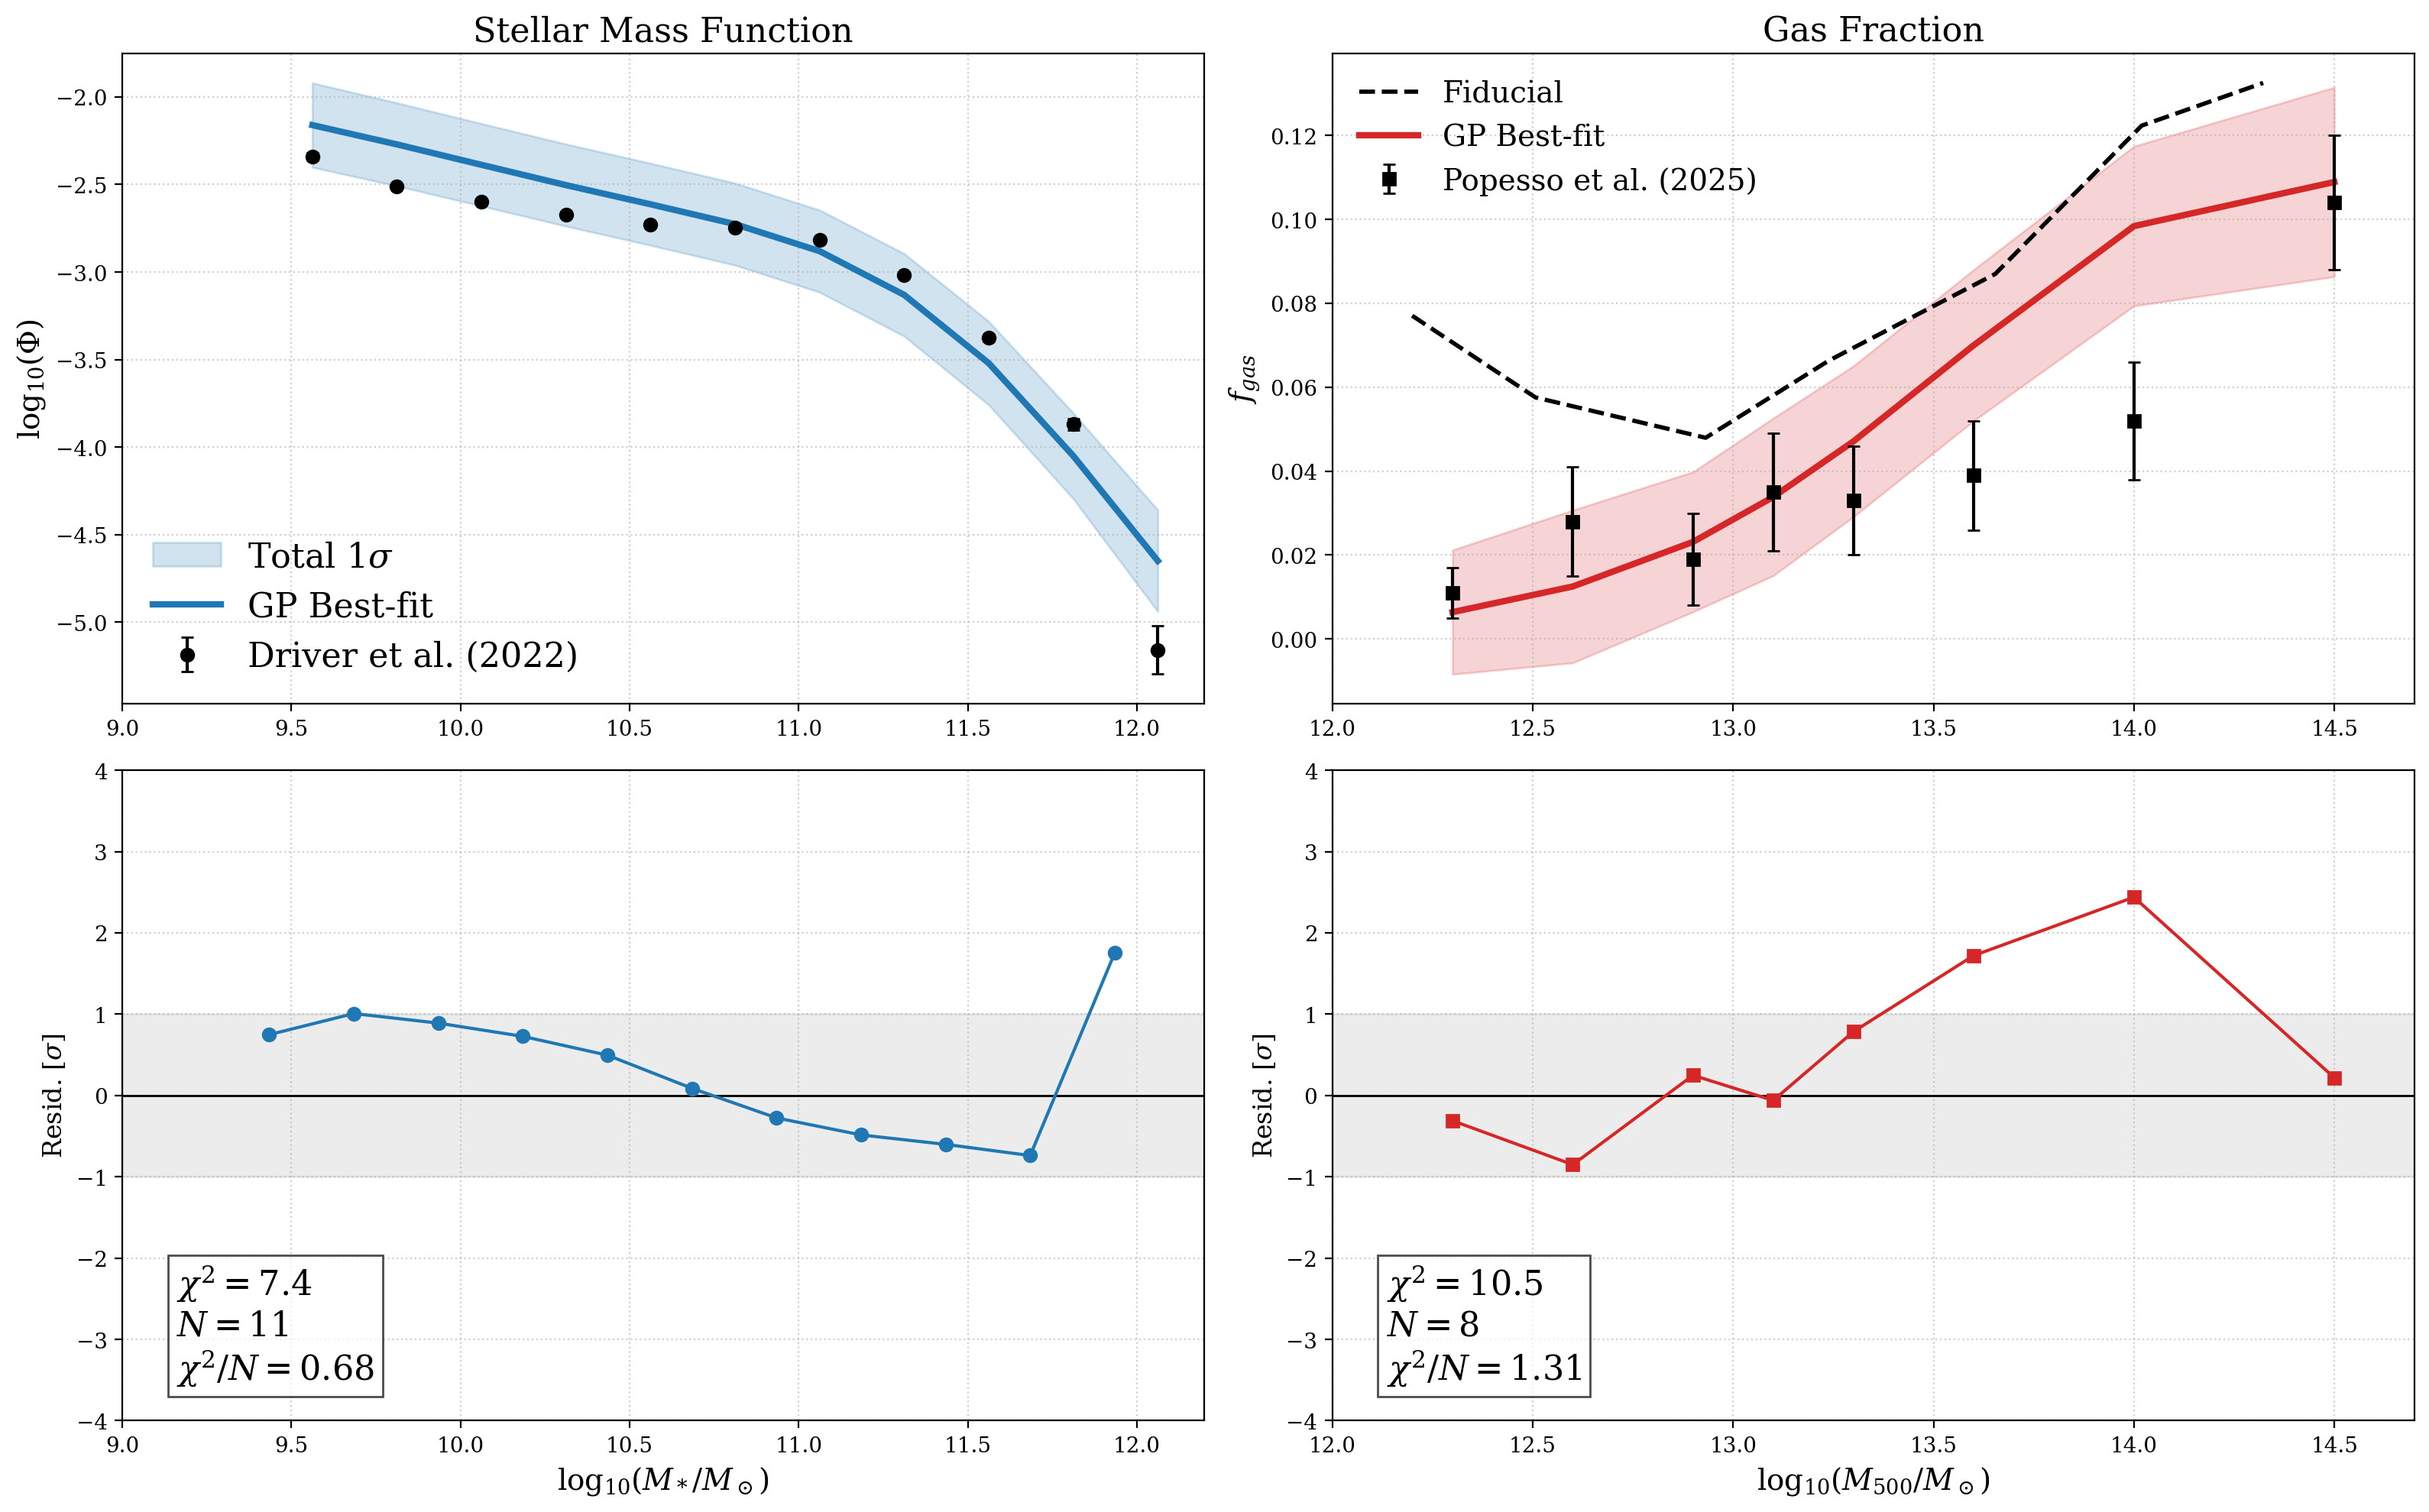

: 

In [ ]:
# 1. Best-Fit Calculations
# bf_theta = np.median(flat_samples[:,:7], axis=0)
bf_theta = samples_ext[np.argmax(log_l_ext)]

GAMA_data = model_GAMA(GAMA_corr, bf_theta[7], bf_theta[8])

obs_log_phi = GAMA_data[9:,1]
obs_uncertainty = GAMA_data[9:,2]
mstar = GAMA_data[9:,0]

# SMF Predictions & Chi2
mu_smf, var_smf = get_gp_prediction(bf_theta[:7], mstar, model_smf)
std_tot_smf = np.sqrt(var_smf + obs_uncertainty**2)
resid_smf = (mu_smf - obs_log_phi) / std_tot_smf
chi2_smf = np.sum(resid_smf**2)
n_smf = len(resid_smf)

# Gas Fraction Predictions & Chi2
mu_fgas, var_fgas = get_gp_prediction(bf_theta[:7], data_dict['mhalo'], model_fgas)
std_tot_fgas = np.sqrt(var_fgas + data_dict['fgas_err']**2)
resid_fgas = (mu_fgas - data_dict['fgas_obs']) / std_tot_fgas
chi2_fgas = np.sum(resid_fgas**2)
n_fgas = len(resid_fgas)

# 2. Setup Figure
fig, axes = plt.subplots(2, 2, figsize=(16, 10), dpi=200)

# --- LEFT COLUMN: SMF ---
ax_m1 = axes[0, 0]
ax_m1.set_xlim(9,12.2)
ax_m1.fill_between(mstar, mu_smf - std_tot_smf, mu_smf + std_tot_smf, 
                        color='C0', alpha=0.2, label='Total $1\sigma$')
ax_m1.plot(mstar, mu_smf, 'C0-', lw=3, label='GP Best-fit')
ax_m1.errorbar(mstar, obs_log_phi, yerr=obs_uncertainty, 
                    fmt='ko', capsize=3, label='Driver et al. (2022)')

# Stats Text Box
stats_smf = f"$\chi^2 = {chi2_smf:.1f}$\n$N = {n_smf}$\n$\chi^2/N = {chi2_smf/n_smf:.2f}$"

ax_m1.set_ylabel(r'$\log_{10}(\Phi)$', fontsize=14)
ax_m1.set_title('Stellar Mass Function', fontsize=16)
ax_m1.legend(loc='lower left', frameon=False, fontsize=16)

# Residuals
ax_r1 = axes[1, 0]
ax_r1.set_xlim(9,12.2)
ax_r1.text(0.05, 0.05, stats_smf, fontsize=16, transform=ax_r1.transAxes, bbox=dict(facecolor='white', alpha=0.7), verticalalignment='bottom')
ax_r1.axhline(0, color='black', lw=1)
ax_r1.axhspan(-1, 1, color='gray', alpha=0.15)
ax_r1.plot(data_dict['mstar'], resid_smf, 'o-', color='C0')
ax_r1.set_ylabel(r'Resid. [$\sigma$]', fontsize=12)
ax_r1.set_xlabel(r'$\log_{10}(M_* / M_\odot)$', fontsize=14)
ax_r1.set_ylim(-4, 4)

# --- RIGHT COLUMN: Gas Fraction ---
ax_m2 = axes[0, 1]
ax_m2.set_xlim(12, 14.7)
ax_m2.plot(fiducial_dict['fgas_mhalo'], fiducial_dict['fgas_val'], 
                'k--', lw=2, label='Fiducial')
ax_m2.fill_between(data_dict['mhalo'], mu_fgas - std_tot_fgas, mu_fgas + std_tot_fgas, 
                        color='C3', alpha=0.2)
ax_m2.plot(data_dict['mhalo'], mu_fgas, 'C3-', lw=3, label='GP Best-fit')
ax_m2.errorbar(data_dict['mhalo'], data_dict['fgas_obs'], yerr=data_dict['fgas_err'], 
                    fmt='ks', capsize=3, label='Popesso et al. (2025)')

# Stats Text Box
stats_fgas = f"$\chi^2 = {chi2_fgas:.1f}$\n$N = {n_fgas}$\n$\chi^2/N = {chi2_fgas/n_fgas:.2f}$"

ax_m2.set_ylabel(r'$f_{gas}$', fontsize=14)
ax_m2.set_title('Gas Fraction', fontsize=16)
ax_m2.legend(loc='upper left', frameon=False, fontsize=14)

# Residuals
ax_r2 = axes[1, 1]
ax_r2.set_xlim(12, 14.7)
ax_r2.text(0.05, 0.05, stats_fgas, fontsize=16, transform=ax_r2.transAxes, bbox=dict(facecolor='white', alpha=0.7), verticalalignment='bottom')
ax_r2.axhline(0, color='black', lw=1)
ax_r2.axhspan(-1, 1, color='gray', alpha=0.15)
ax_r2.plot(data_dict['mhalo'], resid_fgas, 's-', color='C3')
ax_r2.set_ylabel(r'Resid. [$\sigma$]', fontsize=12)
ax_r2.set_xlabel(r'$\log_{10}(M_{500} / M_\odot)$', fontsize=14)
ax_r2.set_ylim(-4, 4)

for ax in axes.flatten(): ax.grid(True, ls=':', alpha=0.6)
plt.tight_layout()
plt.show()

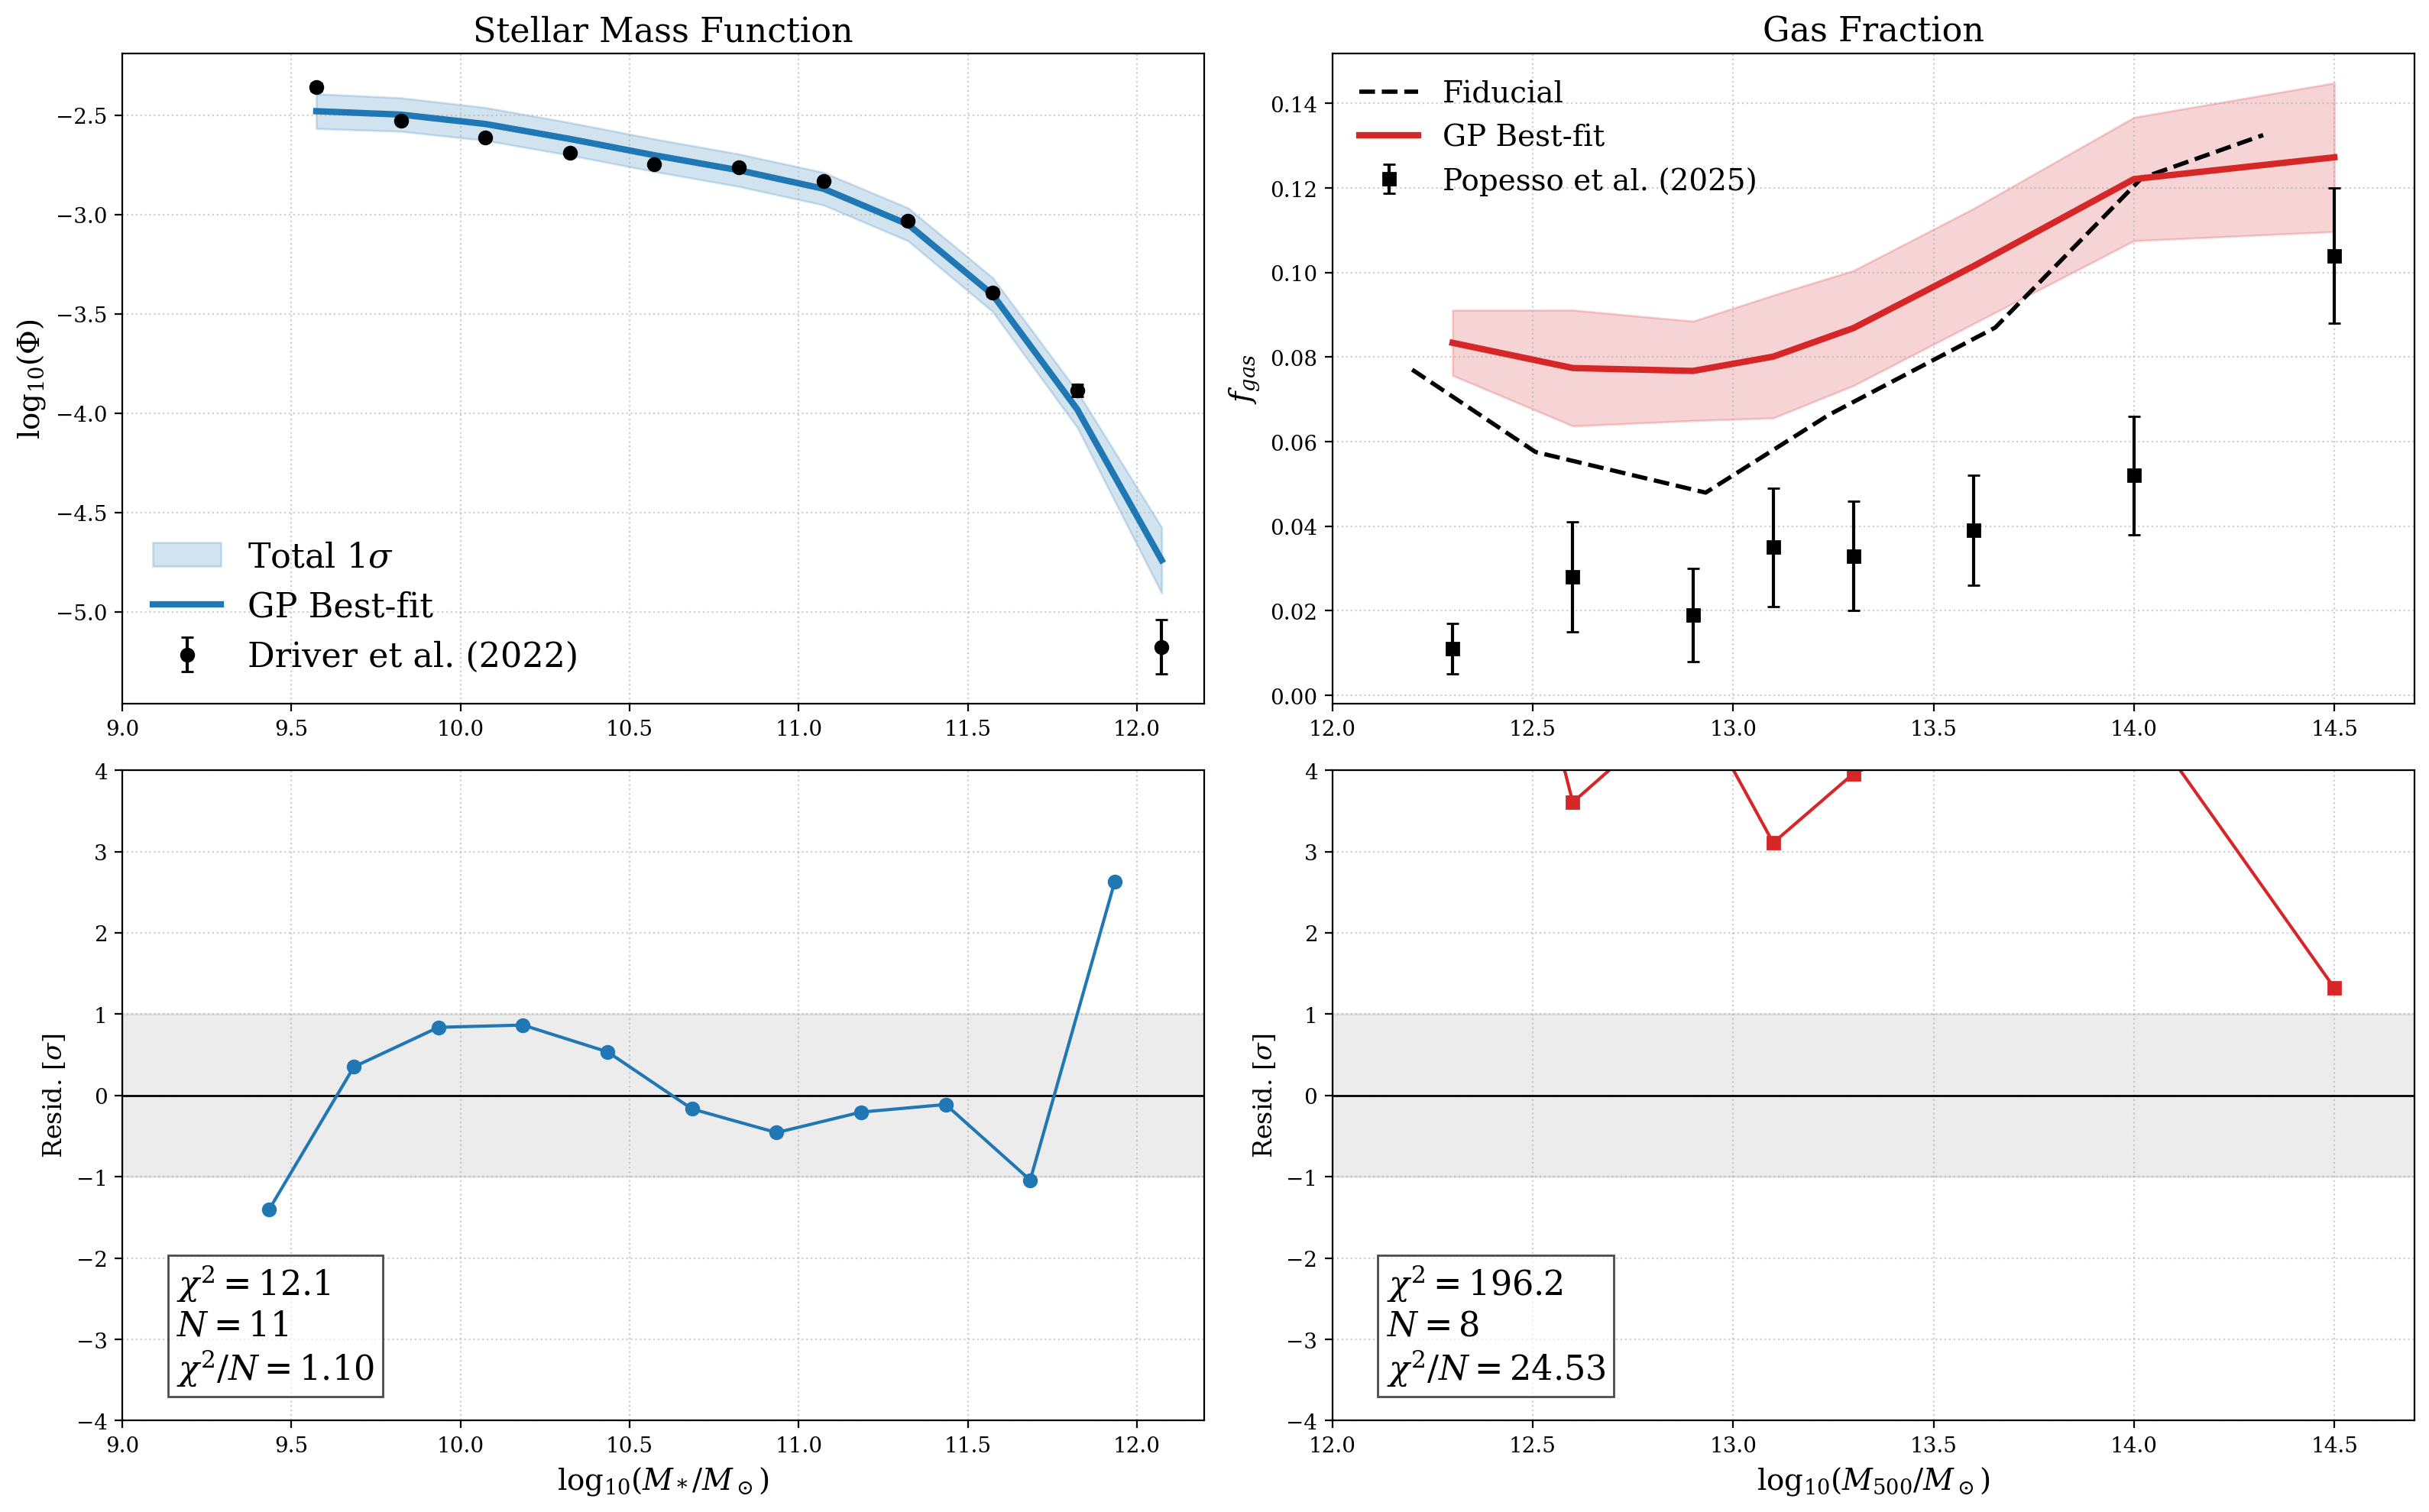

: 

In [ ]:
# 1. Best-Fit Calculations
# bf_theta = np.median(flat_samples[:,:7], axis=0)
bf_theta = smf_samples[np.argmax(log_smf)]

GAMA_data = model_GAMA(GAMA_corr, bf_theta[7], bf_theta[8])

obs_log_phi = GAMA_data[9:,1]
obs_uncertainty = GAMA_data[9:,2]
mstar = GAMA_data[9:,0]

# SMF Predictions & Chi2
mu_smf, var_smf = get_gp_prediction(bf_theta[:7], mstar, model_smf)
std_tot_smf = np.sqrt(var_smf + obs_uncertainty**2)
resid_smf = (mu_smf - obs_log_phi) / std_tot_smf
chi2_smf = np.sum(resid_smf**2)
n_smf = len(resid_smf)

# Gas Fraction Predictions & Chi2
mu_fgas, var_fgas = get_gp_prediction(bf_theta[:7], data_dict['mhalo'], model_fgas)
std_tot_fgas = np.sqrt(var_fgas + data_dict['fgas_err']**2)
resid_fgas = (mu_fgas - data_dict['fgas_obs']) / std_tot_fgas
chi2_fgas = np.sum(resid_fgas**2)
n_fgas = len(resid_fgas)

# 2. Setup Figure
fig, axes = plt.subplots(2, 2, figsize=(16, 10), dpi=200)

# --- LEFT COLUMN: SMF ---
ax_m1 = axes[0, 0]
ax_m1.set_xlim(9,12.2)
# ax_m1.plot(fiducial_dict['smf_mstar'], fiducial_dict['smf_phi'], 
#                 'k--', lw=2, label='Fiducial')
ax_m1.fill_between(mstar, mu_smf - std_tot_smf, mu_smf + std_tot_smf, 
                        color='C0', alpha=0.2, label='Total $1\sigma$')
ax_m1.plot(mstar, mu_smf, 'C0-', lw=3, label='GP Best-fit')
ax_m1.errorbar(mstar, obs_log_phi, yerr=obs_uncertainty, 
                    fmt='ko', capsize=3, label='Driver et al. (2022)')

# Stats Text Box
stats_smf = f"$\chi^2 = {chi2_smf:.1f}$\n$N = {n_smf}$\n$\chi^2/N = {chi2_smf/n_smf:.2f}$"

ax_m1.set_ylabel(r'$\log_{10}(\Phi)$', fontsize=14)
ax_m1.set_title('Stellar Mass Function', fontsize=16)
ax_m1.legend(loc='lower left', frameon=False, fontsize=16)

# Residuals
ax_r1 = axes[1, 0]
ax_r1.set_xlim(9,12.2)
ax_r1.text(0.05, 0.05, stats_smf, fontsize=16, transform=ax_r1.transAxes, bbox=dict(facecolor='white', alpha=0.7), verticalalignment='bottom')
ax_r1.axhline(0, color='black', lw=1)
ax_r1.axhspan(-1, 1, color='gray', alpha=0.15)
ax_r1.plot(data_dict['mstar'], resid_smf, 'o-', color='C0')
ax_r1.set_ylabel(r'Resid. [$\sigma$]', fontsize=12)
ax_r1.set_xlabel(r'$\log_{10}(M_* / M_\odot)$', fontsize=14)
ax_r1.set_ylim(-4, 4)

# --- RIGHT COLUMN: Gas Fraction ---
ax_m2 = axes[0, 1]
ax_m2.set_xlim(12, 14.7)
ax_m2.plot(fiducial_dict['fgas_mhalo'], fiducial_dict['fgas_val'], 
                'k--', lw=2, label='Fiducial')
ax_m2.fill_between(data_dict['mhalo'], mu_fgas - std_tot_fgas, mu_fgas + std_tot_fgas, 
                        color='C3', alpha=0.2)
ax_m2.plot(data_dict['mhalo'], mu_fgas, 'C3-', lw=3, label='GP Best-fit')
ax_m2.errorbar(data_dict['mhalo'], data_dict['fgas_obs'], yerr=data_dict['fgas_err'], 
                    fmt='ks', capsize=3, label='Popesso et al. (2025)')

# Stats Text Box
stats_fgas = f"$\chi^2 = {chi2_fgas:.1f}$\n$N = {n_fgas}$\n$\chi^2/N = {chi2_fgas/n_fgas:.2f}$"

ax_m2.set_ylabel(r'$f_{gas}$', fontsize=14)
ax_m2.set_title('Gas Fraction', fontsize=16)
ax_m2.legend(loc='upper left', frameon=False, fontsize=14)

# Residuals
ax_r2 = axes[1, 1]
ax_r2.set_xlim(12, 14.7)
ax_r2.text(0.05, 0.05, stats_fgas, fontsize=16, transform=ax_r2.transAxes, bbox=dict(facecolor='white', alpha=0.7), verticalalignment='bottom')
ax_r2.axhline(0, color='black', lw=1)
ax_r2.axhspan(-1, 1, color='gray', alpha=0.15)
ax_r2.plot(data_dict['mhalo'], resid_fgas, 's-', color='C3')
ax_r2.set_ylabel(r'Resid. [$\sigma$]', fontsize=12)
ax_r2.set_xlabel(r'$\log_{10}(M_{500} / M_\odot)$', fontsize=14)
ax_r2.set_ylim(-4, 4)

for ax in axes.flatten(): ax.grid(True, ls=':', alpha=0.6)
plt.tight_layout()
plt.show()

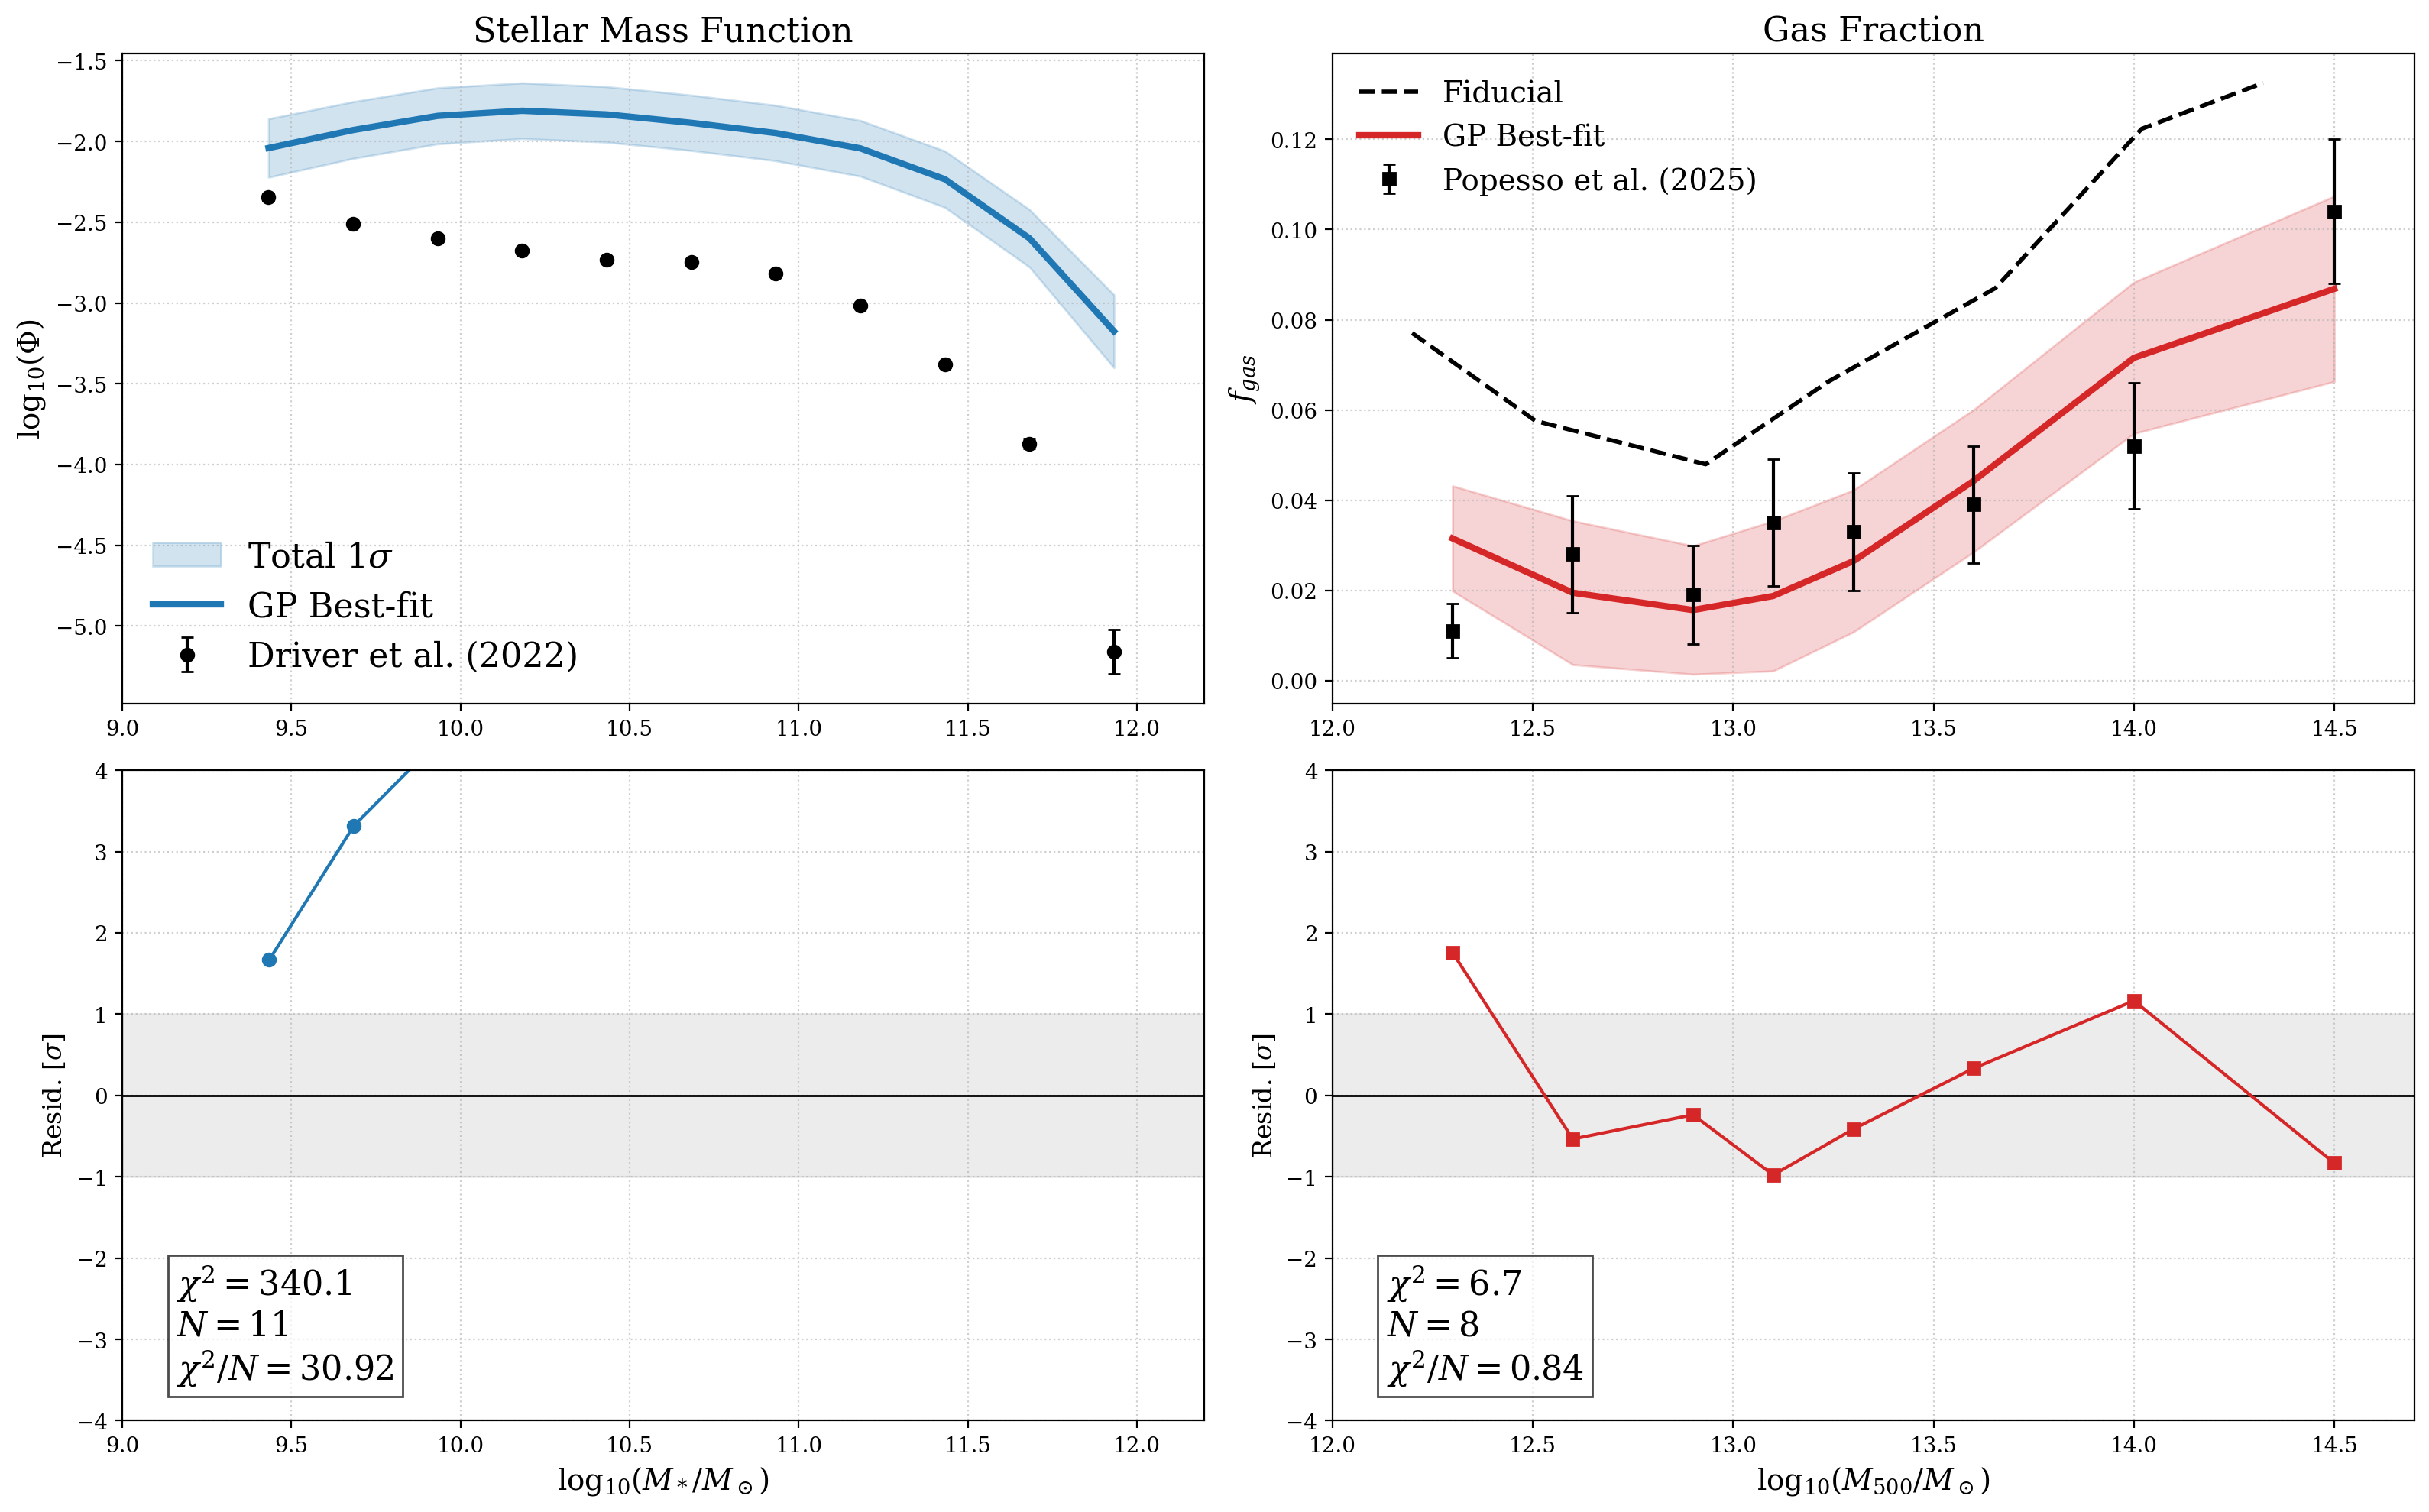

: 

In [ ]:
# 1. Best-Fit Calculations
# bf_theta = np.median(flat_samples[:,:7], axis=0)
bf_theta = fgas_samples[np.argmax(log_fgas)]

GAMA_data = model_GAMA(GAMA_corr, bf_theta[7], bf_theta[8])

obs_log_phi = GAMA_data[9:,1]
obs_uncertainty = GAMA_data[9:,2]
mstar = GAMA_data[9:,0]

# SMF Predictions & Chi2
mu_smf, var_smf = get_gp_prediction(bf_theta[:7], mstar, model_smf)
std_tot_smf = np.sqrt(var_smf + obs_uncertainty**2)
resid_smf = (mu_smf - obs_log_phi) / std_tot_smf
chi2_smf = np.sum(resid_smf**2)
n_smf = len(resid_smf)

# Gas Fraction Predictions & Chi2
mu_fgas, var_fgas = get_gp_prediction(bf_theta[:7], data_dict['mhalo'], model_fgas)
std_tot_fgas = np.sqrt(var_fgas + data_dict['fgas_err']**2)
resid_fgas = (mu_fgas - data_dict['fgas_obs']) / std_tot_fgas
chi2_fgas = np.sum(resid_fgas**2)
n_fgas = len(resid_fgas)

# 2. Setup Figure
fig, axes = plt.subplots(2, 2, figsize=(16, 10), dpi=200)

# --- LEFT COLUMN: SMF ---
ax_m1 = axes[0, 0]
ax_m1.set_xlim(9,12.2)
# ax_m1.plot(fiducial_dict['smf_mstar'], fiducial_dict['smf_phi'], 
#                 'k--', lw=2, label='Fiducial')
ax_m1.fill_between(mstar, mu_smf - std_tot_smf, mu_smf + std_tot_smf, 
                        color='C0', alpha=0.2, label='Total $1\sigma$')
ax_m1.plot(mstar, mu_smf, 'C0-', lw=3, label='GP Best-fit')
ax_m1.errorbar(mstar, obs_log_phi, yerr=obs_uncertainty, 
                    fmt='ko', capsize=3, label='Driver et al. (2022)')

# Stats Text Box
stats_smf = f"$\chi^2 = {chi2_smf:.1f}$\n$N = {n_smf}$\n$\chi^2/N = {chi2_smf/n_smf:.2f}$"

ax_m1.set_ylabel(r'$\log_{10}(\Phi)$', fontsize=14)
ax_m1.set_title('Stellar Mass Function', fontsize=16)
ax_m1.legend(loc='lower left', frameon=False, fontsize=16)

# Residuals
ax_r1 = axes[1, 0]
ax_r1.set_xlim(9,12.2)
ax_r1.text(0.05, 0.05, stats_smf, fontsize=16, transform=ax_r1.transAxes, bbox=dict(facecolor='white', alpha=0.7), verticalalignment='bottom')
ax_r1.axhline(0, color='black', lw=1)
ax_r1.axhspan(-1, 1, color='gray', alpha=0.15)
ax_r1.plot(data_dict['mstar'], resid_smf, 'o-', color='C0')
ax_r1.set_ylabel(r'Resid. [$\sigma$]', fontsize=12)
ax_r1.set_xlabel(r'$\log_{10}(M_* / M_\odot)$', fontsize=14)
ax_r1.set_ylim(-4, 4)

# --- RIGHT COLUMN: Gas Fraction ---
ax_m2 = axes[0, 1]
ax_m2.set_xlim(12, 14.7)
ax_m2.plot(fiducial_dict['fgas_mhalo'], fiducial_dict['fgas_val'], 
                'k--', lw=2, label='Fiducial')
ax_m2.fill_between(data_dict['mhalo'], mu_fgas - std_tot_fgas, mu_fgas + std_tot_fgas, 
                        color='C3', alpha=0.2)
ax_m2.plot(data_dict['mhalo'], mu_fgas, 'C3-', lw=3, label='GP Best-fit')
ax_m2.errorbar(data_dict['mhalo'], data_dict['fgas_obs'], yerr=data_dict['fgas_err'], 
                    fmt='ks', capsize=3, label='Popesso et al. (2025)')

# Stats Text Box
stats_fgas = f"$\chi^2 = {chi2_fgas:.1f}$\n$N = {n_fgas}$\n$\chi^2/N = {chi2_fgas/n_fgas:.2f}$"

ax_m2.set_ylabel(r'$f_{gas}$', fontsize=14)
ax_m2.set_title('Gas Fraction', fontsize=16)
ax_m2.legend(loc='upper left', frameon=False, fontsize=14)

# Residuals
ax_r2 = axes[1, 1]
ax_r2.set_xlim(12, 14.7)
ax_r2.text(0.05, 0.05, stats_fgas, fontsize=16, transform=ax_r2.transAxes, bbox=dict(facecolor='white', alpha=0.7), verticalalignment='bottom')
ax_r2.axhline(0, color='black', lw=1)
ax_r2.axhspan(-1, 1, color='gray', alpha=0.15)
ax_r2.plot(data_dict['mhalo'], resid_fgas, 's-', color='C3')
ax_r2.set_ylabel(r'Resid. [$\sigma$]', fontsize=12)
ax_r2.set_xlabel(r'$\log_{10}(M_{500} / M_\odot)$', fontsize=14)
ax_r2.set_ylim(-4, 4)

for ax in axes.flatten(): ax.grid(True, ls=':', alpha=0.6)
plt.tight_layout()
plt.show()

In [ ]:
bf_sigma = np.std(flat_samples[:,:7], axis=0)

dist_bf = np.zeros(31)
for i in range(31):
    diff_sigma = (bf_theta[:7] - np.asarray([wind_en_or[i], wind_vel_or[i], rho_rec_or[i], sf_ts_or[i], ef_kin_or[i], ef_high_or[i], f_re_or[i]])) / bf_sigma
    dist_bf[i] = np.sqrt( np.sum(diff_sigma**2) )

sim_name = 'LH_{:d}'.format(np.argmin(dist_bf))

fid_theta = np.asarray([wind_en_or[30], wind_vel_or[30], rho_rec_or[30], sf_ts_or[30], ef_kin_or[30], ef_high_or[30], f_re_or[30]])


: 

Text(0.5, 0, '$\\log_{10}(M_{500,c} [M_\\odot])$')

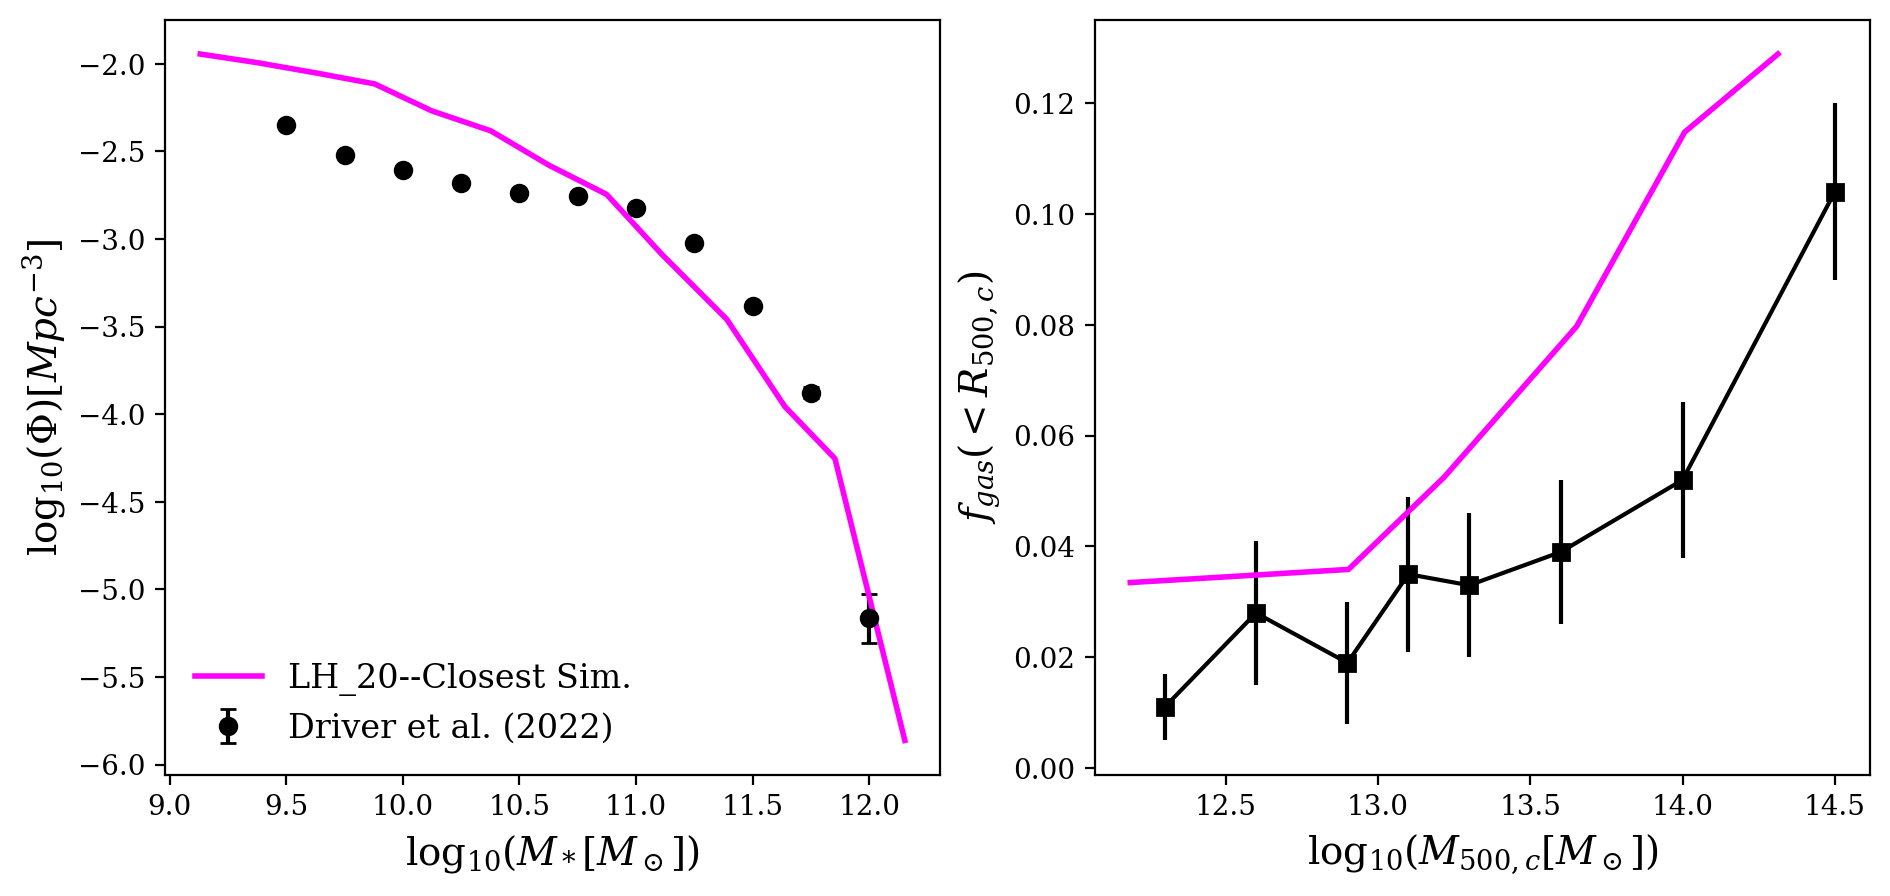

: 

In [ ]:
fig, ax = plt.subplots(1, 2, dpi=200, figsize=(11,5))

#SMF
ax[0].errorbar(mstar, obs_log_phi, yerr=obs_uncertainty, 
                    fmt='ko', capsize=3, label='Driver et al. (2022)')
ax[0].plot(np.log10(zoom_smf[sim_name]['mstar'][0]), np.log10(zoom_smf[sim_name]['smf'][0]),\
    label=sim_name+"--Closest Sim.", color='magenta', linewidth=2)
ax[0].set_ylabel(r'$\log_{10}(\Phi)[Mpc^{-3}]$', fontsize=14)
ax[0].set_xlabel(r'$\log_{10}(M_* [M_\odot])$', fontsize=14)
ax[0].legend(loc='lower left', frameon=False, fontsize=12)

#f_gas
ax[1].errorbar(m500_pp, fgas_pp, yerr=err_pp, marker='s', label='Popesso et al. (2025)', markersize=6, color='k')
ax[1].plot(np.log10(zoom_fgas[sim_name]['m500c'][0]), zoom_fgas[sim_name]['f_gas'][0], label=sim_name+"--Closest Sim.", color='magenta', linewidth=2)

ax[1].set_ylabel(r'$f_{gas}(<R_{500,c})$', fontsize=14)
ax[1].set_xlabel(r'$\log_{10}(M_{500,c} [M_\odot])$', fontsize=14)

Text(0.5, 0.98, 'Cumulative changes to Best-Fit Model')

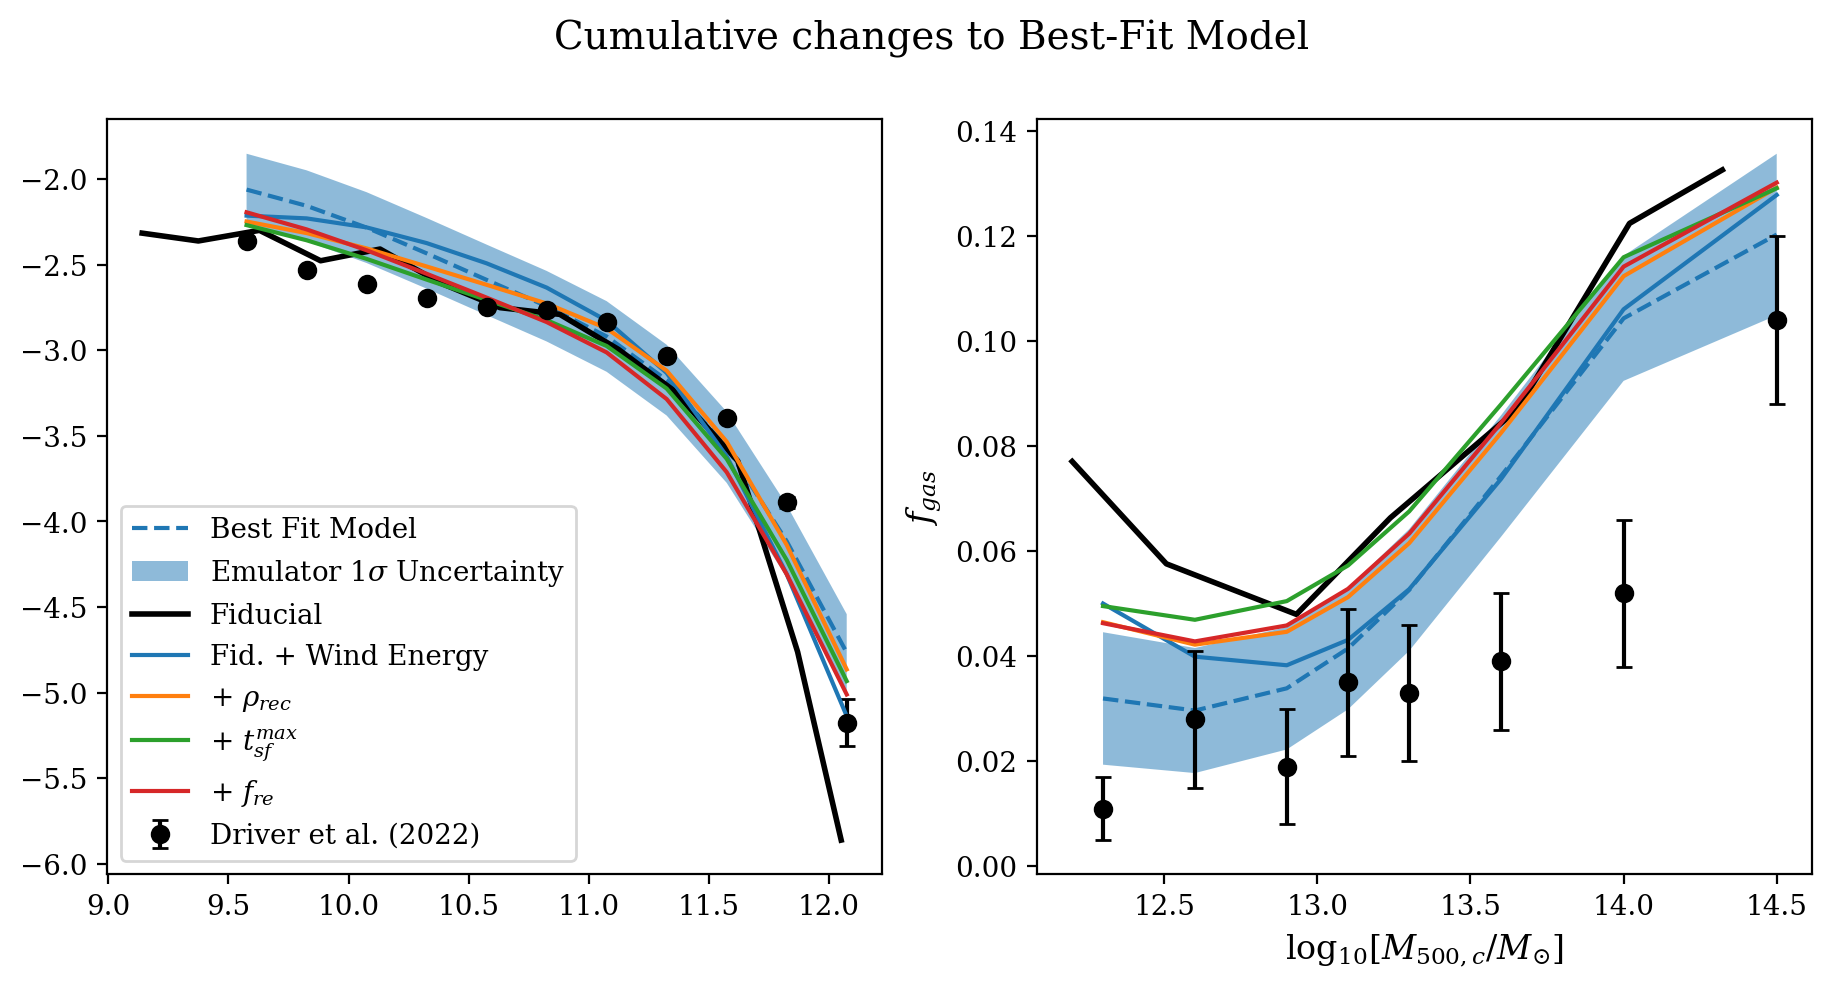

: 

In [ ]:
fig, ax = plt.subplots(1, 2, dpi=200, figsize=(11,5))

# Stellar-Mass Function
ax[0].errorbar(mstar, obs_log_phi, yerr=obs_uncertainty, 
                    fmt='ko', capsize=3, label='Driver et al. (2022)')

# Plot Best-Fit Mean Curve
mu_pred, var_emulator = get_gp_prediction(bf_theta[:7], mstar, model_smf)
ax[0].plot(mstar, mu_pred, ls='--', label='Best Fit Model', color='C0')
ax[0].fill_between(mstar, mu_pred - np.sqrt(var_emulator), mu_pred + np.sqrt(var_emulator), 
    color='C0', alpha=0.5, zorder=2, label='Emulator $1\sigma$ Uncertainty', ec=None)

ax[0].plot(fiducial_dict['smf_mstar'], fiducial_dict['smf_phi'], 
                'k', lw=2, label='Fiducial')

ch_theta = np.copy(fid_theta)
# Wind Energy
ch_theta[0] = bf_theta[0]
ch_mu_pred, ch_var_emulator = get_gp_prediction(ch_theta, mstar, model_smf)
ax[0].plot(mstar, ch_mu_pred, color='C0', label='Fid. + Wind Energy')

# Reincorporation Density
ch_theta[2] = bf_theta[2]
ch_mu_pred, ch_var_emulator = get_gp_prediction(ch_theta, mstar, model_smf)
ax[0].plot(mstar, ch_mu_pred, color='C1', label='+ $\\rho_{rec}$')

# Timescale of Star-Formation
ch_theta[3] = bf_theta[3]
ch_mu_pred, ch_var_emulator = get_gp_prediction(ch_theta, mstar, model_smf)
ax[0].plot(mstar, ch_mu_pred, color='C2', label='+ $t_{sf}^{max}$')

# Reorientation Factor
ch_theta[6] = bf_theta[6]
ch_mu_pred, ch_var_emulator = get_gp_prediction(ch_theta, mstar, model_smf)
ax[0].plot(mstar, ch_mu_pred, color='C3', label='+ $f_{re}$')

ax[0].legend(loc='lower left', fontsize=10)

# Gas-Fractions is Clusters
ax[1].errorbar(
    m500_pp, 
    fgas_pp, 
    yerr=err_pp, # Error bars show the observation uncertainty
    fmt='o', 
    color='k', 
    capsize=3, 
    zorder=3, # Bring to front
    label='Popesso et al (2025)'
)

# Plot Best-Fit Mean Curve
mu_pred, var_emulator = get_gp_prediction(bf_theta[:7], m500_pp, model_fgas)
ax[1].plot(m500_pp, mu_pred, ls='--', label='Best Fit Model', color='C0')
ax[1].fill_between(m500_pp, mu_pred - np.sqrt(var_emulator), mu_pred + np.sqrt(var_emulator), 
    color='C0', alpha=0.5, zorder=2, label='Emulator $1\sigma$ Uncertainty', ec=None)

ax[1].plot(fiducial_dict['fgas_mhalo'], fiducial_dict['fgas_val'], 
                'k', lw=2, label='Fiducial')

ch_theta = np.copy(fid_theta)
# Wind Energy
ch_theta[0] = bf_theta[0]
ch_mu_pred, ch_var_emulator = get_gp_prediction(ch_theta, m500_pp, model_fgas)
ax[1].plot(m500_pp, ch_mu_pred, color='C0', label='Fid. + Wind Energy')

# Reincorporation Density
ch_theta[2] = bf_theta[2]
ch_mu_pred, ch_var_emulator = get_gp_prediction(ch_theta, m500_pp, model_fgas)
ax[1].plot(m500_pp, ch_mu_pred, color='C1', label='+ $\\rho_{rec}$')

# Timescale of Star-Formation
ch_theta[3] = bf_theta[3]
ch_mu_pred, ch_var_emulator = get_gp_prediction(ch_theta, m500_pp, model_fgas)
ax[1].plot(m500_pp, ch_mu_pred, color='C2', label='+ $t_{sf}^{max}$')

# Reorientation Factor
ch_theta[6] = bf_theta[6]
ch_mu_pred, ch_var_emulator = get_gp_prediction(ch_theta, m500_pp, model_fgas)
ax[1].plot(m500_pp, ch_mu_pred, color='C3', label='+ $f_{re}$')

ax[1].set_xlabel('$\\log_{10}[M_{500,c}/M_{\odot}]$', fontsize=12)
ax[1].set_ylabel('$f_{gas}$', fontsize=12)

plt.suptitle("Cumulative changes to Best-Fit Model", fontsize=14)


RuntimeError: Sizes of tensors must match except in dimension 0. Expected size 8 but got size 10 for tensor number 1 in the list.

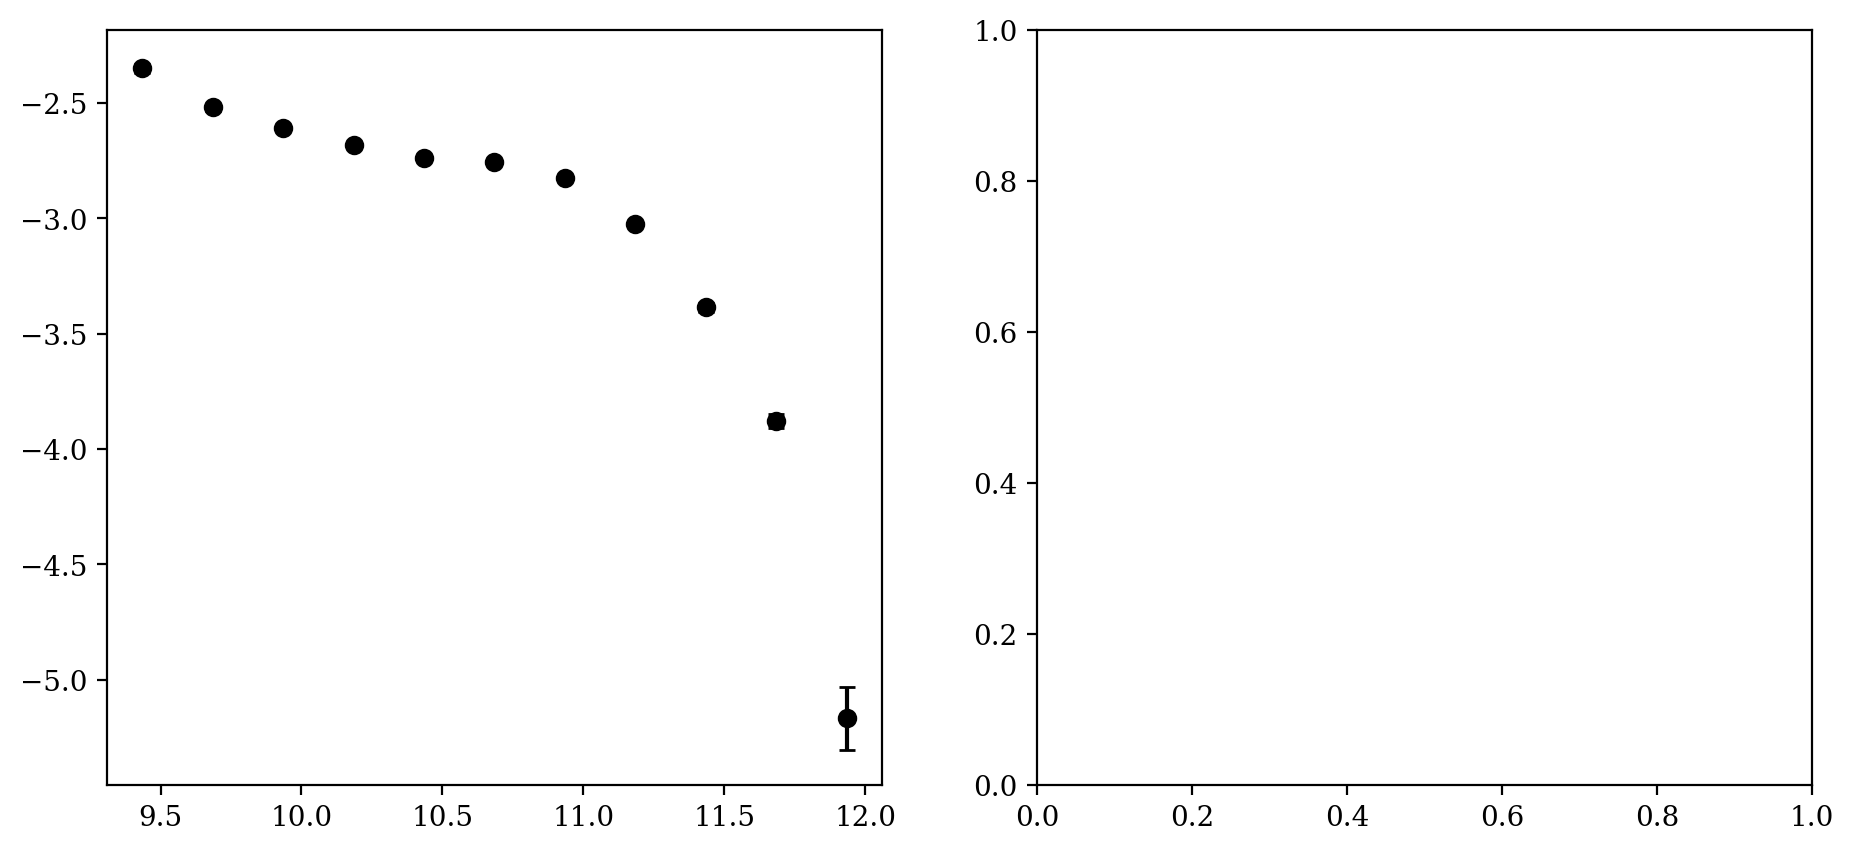

: 

In [ ]:
fig, ax = plt.subplots(1, 2, dpi=200, figsize=(11,5))

# Stellar-Mass Function
ax[0].errorbar(data_dict['mstar'], data_dict['smf_obs'], yerr=data_dict['smf_err'], 
                    fmt='ko', capsize=3, label='Driver et al. (2022)')

# Plot Best-Fit Mean Curve
mu_pred, var_emulator = get_gp_prediction(bf_theta, mstar, model_smf)
ax[0].plot(mstar, mu_pred, ls='--', label='Best Fit Model', color='C0')
ax[0].fill_between(mstar, mu_pred - np.sqrt(var_emulator), mu_pred + np.sqrt(var_emulator), 
    color='C0', alpha=0.5, zorder=2, label='Emulator $1\sigma$ Uncertainty', ec=None)

ax[0].plot(fiducial_dict['smf_mstar'], fiducial_dict['smf_phi'], 
                'k', lw=2, label='Fiducial')
ch_theta = np.copy(fid_theta)
# Wind Energy
ch_theta[0] = bf_theta[0]
ch_mu_pred, ch_var_emulator = get_gp_prediction(ch_theta, mstar, model_smf)
ax[0].plot(mstar, ch_mu_pred, color='C0', label='Fid. + Wind Energy')

ch_theta = np.copy(fid_theta)
# Reincorporation Density
ch_theta[2] = bf_theta[2]
ch_mu_pred, ch_var_emulator = get_gp_prediction(ch_theta, mstar, model_smf)
ax[0].plot(mstar, ch_mu_pred, color='C1', label='Fid + $\\rho_{rec}$')

ch_theta = np.copy(fid_theta)
# Timescale of Star-Formation
ch_theta[3] = bf_theta[3]
ch_mu_pred, ch_var_emulator = get_gp_prediction(ch_theta, mstar, model_smf)
ax[0].plot(mstar, ch_mu_pred, color='C2', label='Fid + $t_{sf}^{max}$')

ch_theta = np.copy(fid_theta)
# Reorientation Factor
ch_theta[6] = bf_theta[6]
ch_mu_pred, ch_var_emulator = get_gp_prediction(ch_theta, mstar, model_smf)
ax[0].plot(mstar, ch_mu_pred, color='C3', label='Fid + $f_{re}$')

ax[0].legend(loc='lower left', fontsize=10)

# Gas-Fractions is Clusters
ax[1].errorbar(
    m500_pp, 
    fgas_pp, 
    yerr=err_pp, # Error bars show the observation uncertainty
    fmt='o', 
    color='k', 
    capsize=3, 
    zorder=3, # Bring to front
    label='Popesso et al (2025)'
)

# Plot Best-Fit Mean Curve
mu_pred, var_emulator = get_gp_prediction(bf_theta, m500_pp, model_fgas)
ax[1].plot(m500_pp, mu_pred, ls='--', label='Best Fit Model', color='C0')
ax[1].fill_between(m500_pp, mu_pred - np.sqrt(var_emulator), mu_pred + np.sqrt(var_emulator), 
    color='C0', alpha=0.5, zorder=2, label='Emulator $1\sigma$ Uncertainty', ec=None)

ax[1].plot(fiducial_dict['fgas_mhalo'], fiducial_dict['fgas_val'], 
                'k', lw=2, label='Fiducial')

ch_theta = np.copy(fid_theta)
# Wind Energy
ch_theta[0] = bf_theta[0]
ch_mu_pred, ch_var_emulator = get_gp_prediction(ch_theta, m500_pp, model_fgas)
ax[1].plot(m500_pp, ch_mu_pred, color='C0', label='Fid. + Wind Energy')

ch_theta = np.copy(fid_theta)
# Reincorporation Density
ch_theta[2] = bf_theta[2]
ch_mu_pred, ch_var_emulator = get_gp_prediction(ch_theta, m500_pp, model_fgas)
ax[1].plot(m500_pp, ch_mu_pred, color='C1', label='Fid + $\\rho_{rec}$')

ch_theta = np.copy(fid_theta)
# Timescale of Star-Formation
ch_theta[3] = bf_theta[3]
ch_mu_pred, ch_var_emulator = get_gp_prediction(ch_theta, m500_pp, model_fgas)
ax[1].plot(m500_pp, ch_mu_pred, color='C2', label='Fid + $t_{sf}^{max}$')

ch_theta = np.copy(fid_theta)
# Reorientation Factor
ch_theta[6] = bf_theta[6]
ch_mu_pred, ch_var_emulator = get_gp_prediction(ch_theta, m500_pp, model_fgas)
ax[1].plot(m500_pp, ch_mu_pred, color='C3', label='+ $f_{re}$')

ax[1].set_xlabel('$\\log_{10}[M_{500,c}/M_{\odot}]$', fontsize=12)
ax[1].set_ylabel('$f_{gas}$', fontsize=12)

plt.suptitle("One parameter shifts to Best-Fit Model", fontsize=14)


: 

: 

: 

: 

: 

: 

: 

In [ ]:

import numpy as np
import sys
import torch
import gpytorch
import emcee
import corner
from GP_models import SMF_Model, fgas_Model

# Gas Fractions from Popesso et al (2024)

m500_pp = np.asarray([12.3,12.6,12.9,13.1,13.3,13.6,14.0,14.5])
fgas_pp = np.asarray([0.011,0.028,0.019,0.035,0.033,0.039,0.052,0.104])
err_pp = np.asarray([0.006,0.013,0.011,0.014,0.013,0.013,0.014,0.016])

# Stellar Mass Function from  GAMA (corrected to h=0.7)
# https://arxiv.org/pdf/2203.08539
# For SDSS correction, add 0.0807 dex to number density

GAMA = np.array([
    [6.875, -0.691, 0.176],
    [7.125, -1.084, 0.125],
    [7.375, -1.011, 0.071],
    [7.625, -1.349, 0.092],
    [7.875, -1.287, 0.079],
    [8.125, -1.544, 0.071],
    [8.375, -1.669, 0.045],
    [8.625, -1.688, 0.032],
    [8.875, -1.795, 0.024],
    [9.125, -1.886, 0.020],
    [9.375, -2.055, 0.014],
    [9.625, -2.142, 0.010],
    [9.875, -2.219, 0.009],
    [10.125, -2.274, 0.009],
    [10.375, -2.292, 0.009],
    [10.625, -2.361, 0.010],
    [10.875, -2.561, 0.013],
    [11.125, -2.922, 0.019],
    [11.375, -3.414, 0.032],
    [11.625, -4.704, 0.138]
])

GAMA_corr = np.zeros((GAMA.shape[0], 4))
GAMA_corr[:,0] = GAMA[:,0] - 2*np.log10(0.7)
GAMA_corr[:,1] = GAMA[:,1] + 3*np.log10(0.7)
GAMA_corr[:,2] = GAMA[:,2]

def model_GAMA(GAMA_corr, b_star, b_cv):

    GAMA_corr = np.copy(GAMA_corr)
    GAMA_corr[:,1] = GAMA_corr[:,1] + np.log10(b_cv)
    GAMA_corr[:,0] = GAMA_corr[:,0] + b_star

    return GAMA_corr

##########################################################
################## Load Parameters #######################
##########################################################

wind_en_or      = []
wind_vel_or     = []
rho_rec_or      = []
sf_ts_or        = []
ef_kin_or       = []
ef_high_or      = []
f_re_or         = []

for i in range(31):
    if i<30:
        filename = "/cosmos_storage/simulations/TNG_Family/MN5_resims/param_LH/param_MTNG-hydro_{:d}.txt".format(i)
    else:
        filename = "/cosmos_storage/simulations/TNG_Family/MN5_resims/param_LH/param_MTNG-hydro.txt"

    with open(filename, 'r') as f:
        for line in f.readlines():
            if len(line.split())!=0:
                if line.split()[0] == 'WindEnergyIn1e51erg':
                    wind_en_or.append(float(line.split()[1]))
                if line.split()[0] == 'VariableWindVelFactor':
                    wind_vel_or.append(float(line.split()[1]))
                if line.split()[0] == 'WindFreeTravelDensFac':
                    rho_rec_or.append(float(line.split()[1]))
                if line.split()[0] == 'MaxSfrTimescale':
                    sf_ts_or.append(float(line.split()[1]))
                if line.split()[0] == 'RadioFeedbackFactor':
                    ef_kin_or.append(float(line.split()[1]))
                if line.split()[0] == 'BlackHoleFeedbackFactor':
                    ef_high_or.append(float(line.split()[1]))
                if line.split()[0] == 'RadioFeedbackReiorientationFactor':
                    f_re_or.append(float(line.split()[1]))
        
rho_rec_or = np.log10(rho_rec_or)
ef_kin_or  = np.log10(ef_kin_or)

wind_en   = (np.asarray(wind_en_or) - np.mean(wind_en_or)) / np.std(wind_en_or)
wind_vel  = (np.asarray(wind_vel_or) - np.mean(wind_vel_or)) / np.std(wind_vel_or)
rho_rec   = (np.asarray(rho_rec_or) - np.mean(rho_rec_or)) / np.std(rho_rec_or)
sf_ts     = (np.asarray(sf_ts_or) - np.mean(sf_ts_or)) / np.std(sf_ts_or)
ef_kin    = (np.asarray(ef_kin_or) - np.mean(ef_kin_or)) / np.std(ef_kin_or)
ef_high   = (np.asarray(ef_high_or) - np.mean(ef_high_or)) / np.std(ef_high_or)
f_re      = (np.asarray(f_re_or) - np.mean(f_re_or)) / np.std(f_re_or)

###########################################################################
######################## Load SMF & fgas GP Model ################################

model_smf = torch.load("/cosmos_storage/home/fgmaion/MTNG-resims/gp_train_results/full_model_smf.pth")
likelihood_smf = torch.load("/cosmos_storage/home/fgmaion/MTNG-resims/gp_train_results/full_likelihood_smf.pth")

model_fgas = torch.load("/cosmos_storage/home/fgmaion/MTNG-resims/gp_train_results/full_model_fgas.pth")
likelihood_fgas = torch.load("/cosmos_storage/home/fgmaion/MTNG-resims/gp_train_results/full_likelihood_fgas.pth")

param_means = np.array([np.mean(wind_en_or), np.mean(wind_vel_or), np.mean(rho_rec_or), 
                        np.mean(sf_ts_or), np.mean(ef_kin_or), np.mean(ef_high_or), np.mean(f_re_or)])
param_stds  = np.array([np.std(wind_en_or), np.std(wind_vel_or), np.std(rho_rec_or), 
                        np.std(sf_ts_or), np.std(ef_kin_or), np.std(ef_high_or), np.std(f_re_or)])

# Lower bounds defined by the simulation campaign itself
lower_bound = np.asarray([0.9,  3.7,  np.log10(0.005), 0.001135, np.log10(0.001), 0.05, 10, -np.inf, -np.inf])
upper_bound = np.asarray([14.4, 14.8, np.log10(0.5),   0.00454,  np.log10(2),     0.2,  40, np.inf, np.inf])

def prepare_theta(theta):

    theta_std = np.copy(theta)
    
    theta_std[0]  = (theta_std[0] - np.mean(wind_en_or)) / np.std(wind_en_or)
    theta_std[1]  = (theta_std[1] - np.mean(wind_vel_or)) / np.std(wind_vel_or)
    theta_std[2]  = (theta_std[2] - np.mean(rho_rec_or)) / np.std(rho_rec_or)
    theta_std[3]  = (theta_std[3] - np.mean(sf_ts_or)) / np.std(sf_ts_or)
    theta_std[4]  = (theta_std[4] - np.mean(ef_kin_or)) / np.std(ef_kin_or)
    theta_std[5]  = (theta_std[5] - np.mean(ef_high_or)) / np.std(ef_high_or)
    theta_std[6]  = (theta_std[6] - np.mean(f_re_or)) / np.std(f_re_or)

    return theta_std

# --- THE JOINT LIKELIHOOD ---

def log_p(theta):
    # 1. Check for non-physical parameters (Prior check)
    # Define bounds for the 7 physical parameters (theta_1 to theta_7)
    lower_bounds = lower_bound
    upper_bounds = upper_bound
    if not (np.all(theta > lower_bounds) and np.all(theta < upper_bounds)):
        return -np.inf # Implements a flat prior
    else:
        # Prior on b_star
        prior_bstar = -0.5 * ( (theta[7]/0.14)**2 + np.log(2 * np.pi * 0.14**2) )

        # Prior on b_cv
        prior_bcv = -0.5 * ( ( (theta[8]-1)/0.06)**2 + np.log(2 * np.pi * 0.06**2) )

        return prior_bstar + prior_bcv

def log_likelihood_joint(theta, data_dict, models_dict, w_smf, w_fgas):
    """
    Joint likelihood for SMF and Gas Fractions.
    data_dict: contains 'mstar', 'smf_obs', 'smf_err', 'mhalo', 'fgas_obs', 'fgas_err', 'mhalo_err'
    models_dict: contains 'gp_smf', 'gp_fgas'
    """

    theta_std = prepare_theta(theta)
    
    # --- Part A: SMF Likelihood ---
    # Get the observational model
    GAMA_data = model_GAMA(GAMA_corr, theta[7], theta[8])

    obs_log_phi = GAMA_data[9:,1]
    obs_uncertainty = GAMA_data[9:,2]
    mstar = GAMA_data[9:,0]
    
    smf_input = np.hstack([mstar[:, None], np.repeat(theta_std[None, :7], len(mstar), axis=0)])
    
    with torch.no_grad(), gpytorch.settings.fast_pred_var():
        pred_smf = models_dict['gp_smf'](torch.from_numpy(smf_input).float())
        mu_smf = pred_smf.mean.numpy()
        var_smf = pred_smf.variance.numpy() + data_dict['smf_err']**2
    
    lnL_smf = -0.5 * np.sum(((data_dict['smf_obs'] - mu_smf)**2 / var_smf) + np.log(2 * np.pi * var_smf))

    # --- Part B: Gas Fraction Likelihood ---
    mhalo = data_dict['mhalo']
    # Halo mass might also need normalization if your GP was trained on standardized M_h
    fgas_input = np.hstack([mhalo[:, None], np.repeat(theta_std[None, :7], len(mhalo), axis=0)])
    
    # To handle M_h uncertainty properly, we enable gradients for the slope calculation
    # If the GP is smooth, you can approximate this; here we use the predictive mean.
    x_gas_torch = torch.from_numpy(fgas_input).float().requires_grad_(True)
    
    with torch.no_grad(), gpytorch.settings.fast_pred_var():
        pred_fgas = models_dict['gp_fgas'](x_gas_torch)
        mu_fgas = pred_fgas.mean
        var_fgas_emu = pred_fgas.variance.detach().numpy()
        
        # # Calculate slope df/dmhalo to propagate M_halo uncertainty
        # # This is the 'errors-in-variables' correction
        # mu_fgas.sum().backward()
        # slope = x_gas_torch.grad[:, 0].numpy() # Derivative w.r.t the first column (M_h)
        
    mu_fgas = mu_fgas.detach().numpy()
    
    # Total variance = GP_var + Obs_fgas_var + (slope * Obs_Mhalo_var)^2
    var_fgas_total = var_fgas_emu + data_dict['fgas_err']**2 #+ (slope * data_dict['mhalo_err'])**2
    
    lnL_fgas = -0.5 * np.sum(((data_dict['fgas_obs'] - mu_fgas)**2 / var_fgas_total) + np.log(2 * np.pi * var_fgas_total))

    # --- Part C: Combined ---
    total_lnL = w_smf * lnL_smf + w_fgas * lnL_fgas + log_p(theta)
    
    return total_lnL if np.isfinite(total_lnL) else -np.inf


##########################################################
# --- 1. SET UP DATA AND MODELS ---

# Observations for SMF
data_dict = {
    'mstar':     np.array(GAMA_corr[9:,0]), # Mass bins
    'smf_obs':   np.array(GAMA_corr[9:,1]), # log10(Phi)
    'smf_err':   np.array(GAMA[9:,2]), # Uncertainty in log10(Phi)
    
    # Observations for Gas Fractions
    'mhalo':     m500_pp, # Halo mass bins (input)
    'fgas_obs':  fgas_pp, # Measured gas fraction
    'fgas_err':  err_pp, # Uncertainty in gas fraction (y-axis)
    'mhalo_err': np.array(np.zeros_like(m500_pp))  # Uncertainty in halo mass (x-axis)
}

# Wrap models
models_dict = {
    'gp_smf':  model_smf, # Your first trained GP
    'gp_fgas': model_fgas # Your second trained GP
}

# Ensure models are in evaluation mode
for m in models_dict.values():
    m.eval()

############################################################

def run_MCMC(w_smf, w_fgas):

    ndim = 9
    nwalkers = 2 * ndim

    # Initialize walkers within the physical bounds (lower_bound, upper_bound)
    # We start them in a small ball around a reasonable central guess
    p0_start = np.asarray([np.mean(wind_en_or), np.mean(wind_vel_or), np.mean(rho_rec_or), np.mean(sf_ts_or),\
                        np.mean(ef_kin_or), np.mean(ef_high_or), np.mean(f_re_or), 0, 1])
    p0 = p0_start + 1e-4 * np.random.randn(nwalkers, ndim)

    # Ensure initial positions are actually within bounds
    p0 = np.clip(p0, lower_bound + 1e-5, upper_bound - 1e-5)

    # Define where to save the results of this chain
    # Set up the backend
    # Don't forget to clear it in case the file already exists
    filename = "/cosmos_storage/home/fgmaion/MTNG-resims/mcmc_chains/fgas_chain.h5"
    #backend = emcee.backends.HDFBackend(filename)
    #backend.reset(nwalkers, ndim) # If you want to restart from your current progress, comment this line

    # Initialize the sampler
    sampler = emcee.EnsembleSampler(
        nwalkers, 
        ndim, 
        log_likelihood_joint, # Our joint function
        args=(data_dict, models_dict, w_smf, w_fgas),
#	backend=backend
    )

    # --- RUNNING MCMC WITH CONVERGENCE CHECK ---
    print("Starting MCMC run with convergence monitoring...")

    # Initialize variables
    max_n = 50000        # Maximum number of steps to allow
    autocorr_tol = 0.01  # Tolerance for fractional change in tau (e.g., 1%)
    min_steps = 1000     # Minimum number of steps before checking tau
    index = 0
    old_tau = np.inf

    sampler.run_mcmc(p0, max_n, progress=True, thin_by=1)

#    # The main loop that runs the sampler until convergence criteria are met
#    for sample in sampler.sample(p0, iterations=max_n, progress=False):
#        
#        # Only check for convergence every 'check_interval' steps
#        check_interval = 100
#        if sampler.iteration % check_interval:
#            continue
#
#        index += 1
#        
#        # 1. Estimate the autocorrelation time (tau)
#        # The default 'c' argument is 50, meaning it requires at least 50 independent samples
#        # to estimate tau robustly.
#        try:
#            # Use discard=0 since we are checking the full chain so far
#            tau = sampler.get_autocorr_time(tol=0, discard=0) 
#        except emcee.autocorr.AutocorrError:
#            # Not enough samples yet to estimate tau. Keep sampling.
#            print(f"Step {sampler.iteration}: Not enough samples to estimate tau. Continuing...")
#            continue
#
#        # Take the maximum tau across all dimensions
#        current_tau = np.max(tau)
#        
#        # 2. Check for burn-in and chain length convergence
#        # We require the chain length to be at least 50 times the estimated tau
#        converged = sampler.iteration > (50 * current_tau)
#
#        # 3. Check for stabilization of tau
#        # We require the estimated tau to have stabilized (change by less than the tolerance)
#        stabilized = np.all(np.abs(old_tau - current_tau) / current_tau < autocorr_tol)
#        
#        print(f"Step {sampler.iteration}: Max tau = {current_tau:.2f}. Old tau = {old_tau:.2f}. Stabilized: {stabilized}.")
#
#        # Update tau for the next check
#        old_tau = current_tau
#        
#        # Break if both conditions are met AND we are past the minimum steps
#        if converged and stabilized and sampler.iteration >= min_steps:
#            print("MCMC converged!")
#            break
#
    return sampler

## --- Just SMF
#sampler_smf = run_MCMC(1, 0)
#burnin = int(2 * np.max(sampler_smf.get_autocorr_time(tol=0)))
#smf_samples = sampler_smf.get_chain(discard=burnin, flat=True)
#log_smf = sampler_smf.get_log_prob(discard=burnin, flat=True)

# --- Just fgas
sampler_fgas = run_MCMC(0, 1)
burnin = int(2 * np.max(sampler_fgas.get_autocorr_time(tol=0)))
fgas_samples = sampler_fgas.get_chain(discard=burnin, flat=True)
load_fgas = sampler_fgas.get_log_prob(discard=burnin, flat=True)

# # --- SMF & fgas
#sampler_joint = run_MCMC(1, 1)
#burnin = int(2 * np.max(sampler_joint.get_autocorr_time(tol=0)))
#joint_samples = sampler_joint.get_chain(discard=burnin, flat=True)
#load_joint = sampler_joint.get_log_prob(discard=burnin, flat=True)


/tmp/ipykernel_241136/3420305691.py:105: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_smf = torch.load("/cosmos_storage/home/fgmaion/MTNG-resims/gp_train_results/full

Starting MCMC run with convergence monitoring...


  0%|                                                                                                                                                               | 11/50000 [00:16<20:46:54,  1.50s/it]Traceback (most recent call last):
  File "/lscratch/fgmaion/miniconda3/envs/condaenv/lib/python3.9/site-packages/emcee/ensemble.py", line 624, in __call__
    return self.f(x, *self.args, **self.kwargs)
  File "/tmp/ipykernel_241136/3420305691.py", line 172, in log_likelihood_joint
    pred_smf = models_dict['gp_smf'](torch.from_numpy(smf_input).float())
  File "/lscratch/fgmaion/miniconda3/envs/condaenv/lib/python3.9/site-packages/gpytorch/models/exact_gp.py", line 333, in __call__
    ) = self.prediction_strategy.exact_prediction(full_mean, full_covar)
  File "/lscratch/fgmaion/miniconda3/envs/condaenv/lib/python3.9/site-packages/gpytorch/models/exact_prediction_strategies.py", line 322, in exact_prediction
    self.exact_predictive_covar(test_test_covar, test_train_covar),
  File "/l

emcee: Exception while calling your likelihood function:
  params: [ 7.51558176e+00  9.20894976e+00 -1.29796008e+00  1.99889264e-03
 -1.30629560e+00  1.24371307e-01  2.48391704e+01  1.16430611e-03
  9.98001332e-01]
  args: ({'mstar': array([ 9.43480392,  9.68480392,  9.93480392, 10.18480392, 10.43480392,
       10.68480392, 10.93480392, 11.18480392, 11.43480392, 11.68480392,
       11.93480392]), 'smf_obs': array([-2.35070588, -2.51970588, -2.60670588, -2.68370588, -2.73870588,
       -2.75670588, -2.82570588, -3.02570588, -3.38670588, -3.87870588,
       -5.16870588]), 'smf_err': array([0.02 , 0.014, 0.01 , 0.009, 0.009, 0.009, 0.01 , 0.013, 0.019,
       0.032, 0.138]), 'mhalo': array([12.3, 12.6, 12.9, 13.1, 13.3, 13.6, 14. , 14.5]), 'fgas_obs': array([0.011, 0.028, 0.019, 0.035, 0.033, 0.039, 0.052, 0.104]), 'fgas_err': array([0.006, 0.013, 0.011, 0.014, 0.013, 0.013, 0.014, 0.016]), 'mhalo_err': array([0., 0., 0., 0., 0., 0., 0., 0.])}, {'gp_smf': SMF_Model(
  (likelihood): Gaussi

KeyboardInterrupt: 

: 

: 

: 